# Novel Methods for Tracing the Functional Impact of Alternative Splicing during Cardiac Differentiation - Notebook

In this notebook you will find the analysis of the *Spice* method and the run of the adjusted method. Specific analysis of genes can be found in the notebook: cardiac_data_analysis.ipynb

# Setup

In [186]:
import spice_func as spice # main spice functions
import analysis_func as af # functions for analysis peformed in my thesis and plotting functions

In [187]:
import os
import json
from typing import Dict
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from collections import Counter


In [188]:
# import matplotlib as mpl
# mpl.rcParams['font.size'] = 15
# mpl.rcParams['axes.titlesize'] = 15
# mpl.rcParams['xtick.labelsize'] = 10
# mpl.rcParams['ytick.labelsize'] = 10
# mpl.rcParams['figure.dpi'] = 300
# mpl.rcParams['savefig.dpi'] = 300

# Genes with low transcript counts exhibit more extreme RMSD values

In [189]:
rmsdmax_trimmedewfd_result_path = "/home/katharina/msc/spice/old_spice/spice_result_homo_sapiens_113_3ee/comparison/meso_day2@psc_day0@d41d8c.tsv"
psc_vs_meso = pd.read_csv(rmsdmax_trimmedewfd_result_path, sep="\t")
psc_vs_meso.head(50)

,gene_id,rmsd,rmsd_rel,mpd,jsd,AT-bin
0,ENSG00000162779,1.00000,1.00000,1.00000,1.00000,2
1,ENSG00000116039,1.00000,1.00000,1.00000,1.00000,2
2,ENSG00000134115,1.00000,1.00000,1.00000,1.00000,2
3,ENSG00000120251,1.00000,1.00000,1.00000,1.00000,2
4,ENSG00000112818,1.00000,1.00000,1.00000,1.00000,2
5,ENSG00000105989,1.00000,1.00000,1.00000,1.00000,2
6,ENSG00000184911,1.00000,1.00000,1.00000,1.00000,2
7,ENSG00000268235,1.00000,1.00000,1.00000,1.00000,2
8,ENSG00000250305,1.00000,0.98769,0.66667,1.00000,3
9,ENSG00000184925,1.00000,1.00000,1.00000,1.00000,2


In [190]:
psc_vs_meso_old_top35 = psc_vs_meso.head(35)
psc_vs_meso_old_top35

,gene_id,rmsd,rmsd_rel,mpd,jsd,AT-bin
0,ENSG00000162779,1.00000,1.00000,1.00000,1.00000,2
1,ENSG00000116039,1.00000,1.00000,1.00000,1.00000,2
2,ENSG00000134115,1.00000,1.00000,1.00000,1.00000,2
3,ENSG00000120251,1.00000,1.00000,1.00000,1.00000,2
4,ENSG00000112818,1.00000,1.00000,1.00000,1.00000,2
5,ENSG00000105989,1.00000,1.00000,1.00000,1.00000,2
6,ENSG00000184911,1.00000,1.00000,1.00000,1.00000,2
7,ENSG00000268235,1.00000,1.00000,1.00000,1.00000,2
8,ENSG00000250305,1.00000,0.98769,0.66667,1.00000,3
9,ENSG00000184925,1.00000,1.00000,1.00000,1.00000,2


In [191]:
psc_vs_meso_old_top35["num_tx"] = psc_vs_meso_old_top35["AT-bin"]
psc_vs_meso_old_top35.drop(["rmsd_rel", "mpd", "jsd", "AT-bin"], axis=1, inplace=True)

/tmp/ipykernel_1646585/1486239603.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psc_vs_meso_old_top35["num_tx"] = psc_vs_meso_old_top35["AT-bin"]
/tmp/ipykernel_1646585/1486239603.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psc_vs_meso_old_top35.drop(["rmsd_rel", "mpd", "jsd", "AT-bin"], axis=1, inplace=True)


In [192]:
psc_vs_meso_old_top35

,gene_id,rmsd,num_tx
0,ENSG00000162779,1.00000,2
1,ENSG00000116039,1.00000,2
2,ENSG00000134115,1.00000,2
3,ENSG00000120251,1.00000,2
4,ENSG00000112818,1.00000,2
5,ENSG00000105989,1.00000,2
6,ENSG00000184911,1.00000,2
7,ENSG00000268235,1.00000,2
8,ENSG00000250305,1.00000,3
9,ENSG00000184925,1.00000,2


In [193]:
# psc_vs_meso_old_top35.to_latex(
#     "/home/katharina/msc/figures/old_spice_top35.tex",
#     index=False
# )

In [194]:
len(psc_vs_meso)

12589

In [195]:
df = pd.DataFrame.from_dict(dict(Counter(psc_vs_meso["AT-bin"])), orient="index").reset_index()
df["bin"] = df["index"]
df["num_g"] = df[0]
df_sorted = df.drop(["index",0], axis=1).sort_values("bin")

In [196]:
df_sorted

,bin,num_g
0,2,2364
1,3,2209
2,4,1860
3,5,1442
4,6,1080
5,7,842
6,8,598
7,9,431
8,10,367
15,11,267


In [197]:
(2364+2209+1860)/len(psc_vs_meso)

0.5110016681229645

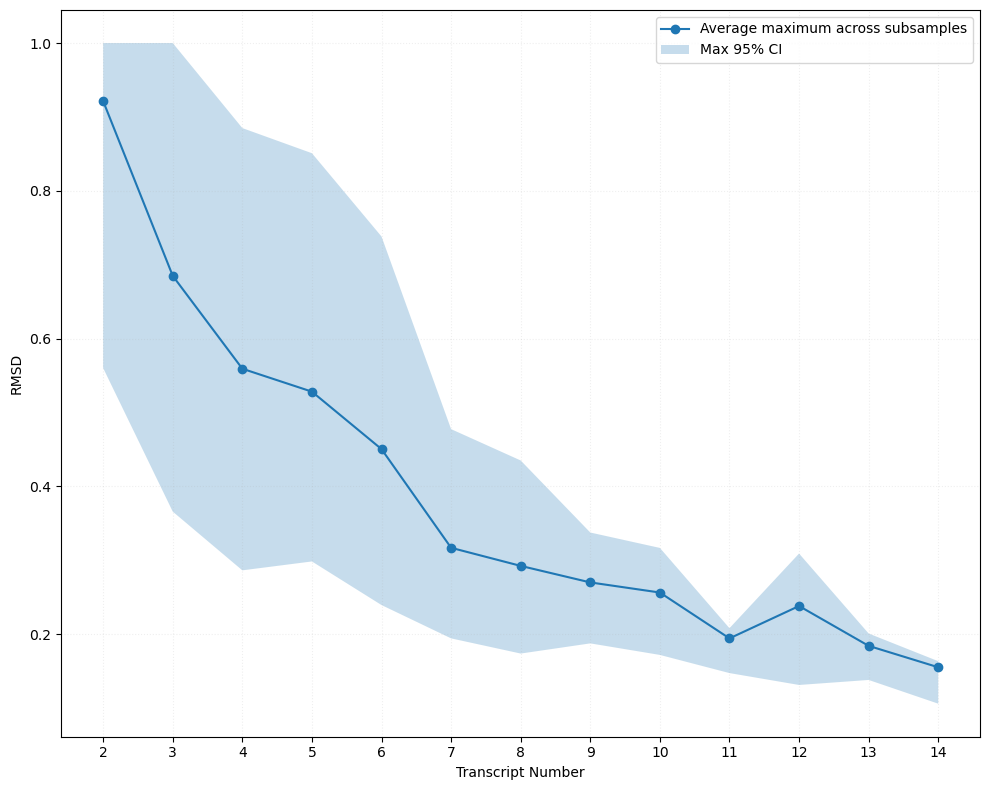

' plt.tight_layout()\nplt.show()\n '

In [198]:
group_col = "AT-bin"
value_col = "rmsd"
n_boot = 1000
ci = (2.5, 97.5)
rng = np.random.default_rng(42)
psc_vs_meso_filt = psc_vs_meso[psc_vs_meso[group_col] < 15]
counts = psc_vs_meso_filt[group_col].value_counts().sort_index()
bins = counts.index.to_list()
size_per_bin = counts.min()  # same N from each bin in every bootstrap draw

# run subsampling analysis
rmsd_stats = af.subsample_by_bin(psc_vs_meso_filt, group_col, value_col, bins, size_per_bin, n_boot, rng, ci)

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=False)

# categorical positions + labels
labels = [str(b) for b in bins]
xpos   = np.arange(len(bins), dtype=float)

rmsd_stats["xpos"] = xpos
rmsd_stats["labels"] = labels

af.plot_boot(ax, rmsd_stats, "")
""" plt.tight_layout()
plt.show()
 """

# Run (adjusted) core *Spice* method

In [199]:
# If not run before
# scaled_counts, sf, tx_ids, sample_ids = spice.swish_scale_from_metadata(metadata_tsv="/home/katharina/msc/quant/metadata.txt",
#                                                                   outdir="/home/katharina/msc/quant/tx_medianRatio_scaledCounts",
#                                                                   )

In [200]:
# Define Paths
lib_path = "/share/project/katharina/Spice/spice_lib_homo_sapiens_113_3ee/"
fas_scores_fullpath = "/share/project/katharina/Spice/spice_lib_homo_sapiens_113_3ee/fas_data/fas_scores"
transcript_info_path = "/share/project/katharina/Spice/spice_lib_homo_sapiens_113_3ee/transcript_data/transcript_info.json"
scaled_counts_path = "/home/katharina/msc/quant/tx_medianRatio_scaledCounts"

In [201]:
# Load transcript_info.json file
transcript_info = spice.extract_data_from_json(transcript_info_path) # needs to be loaded for filter_ID_Map
# Load fas index dict
fas_index = spice.load_fas_index(libpath=lib_path)

## Library info

In [202]:
tc_bins = defaultdict(list)
for gene, data in transcript_info.items():
    tc = len(data["transcripts"].keys())
    if tc != 1:
        tc_bins[tc].append(gene)

tc_bins = dict(tc_bins)

In [203]:
num_g_lib = 0
for gene, data in transcript_info.items():
    num_g_lib += 1

print(num_g_lib)

19745


In [204]:
tr = list()
# num_t_lib = 0
for gene, data in transcript_info.items():
    txs = list(data["transcripts"].keys())
    tr += txs
set_tr = set(tr)
print(len(set_tr))

110928


## Create mapping dataframe

Makes sure that we only consider genes and their transcripts which are also in the library.

In [205]:
# Creates mapping from reference GTF
# mapping_from_gtf =  spice.mapping_from_gtf("/share/project/katharina/reference/ENSEMBLv113/annotation/Homo_sapiens.GRCh38.113.gtf", version_suffix="113")

In [206]:
# Filter the mapping dataframe for genes and transcript present in library
# Extends mapping also with FAS ids, transcript and gene symbol and transcript biotype
# mapping_new = spice.filter_ID_Map(mapping_df=mapping_from_gtf,
#                                  transcript_info=transcript_info,
#                                  versioned=True)

In [207]:
#mapping_new.to_csv("/home/katharina/msc/spice/mapping.tsv", sep="\t", index=False)

In [208]:
mapping_new = pd.read_csv("/home/katharina/msc/spice/mapping.tsv", sep="\t")

In [209]:
mapping_new.head()

,ensembl_id,ensembl_transcript_id,transcript_id_v113,fas_id,transcript_symbol,transcript_biotype,gene_symbol
0,ENSG00000142611,ENST00000511072,ENST00000511072.5,ENSP00000426975,PRDM16-206,protein_coding,PRDM16
1,ENSG00000142611,ENST00000378391,ENST00000378391.6,ENSP00000367643,PRDM16-203,protein_coding,PRDM16
2,ENSG00000142611,ENST00000514189,ENST00000514189.5,ENSP00000421400,PRDM16-208,protein_coding,PRDM16
3,ENSG00000142611,ENST00000270722,ENST00000270722.10,ENSP00000270722,PRDM16-201,protein_coding,PRDM16
4,ENSG00000142611,ENST00000463591,ENST00000463591.1,ENSP00000476002,PRDM16-204,protein_coding,PRDM16


In [210]:
# Needed later, precalculate now
allowed_genes, allowed_tx_ver, allowed_tx_unv, ver_map, unver_map, ver_unver_map = spice.make_tx_whitelist_and_maps(mapping_new)

## Infer active transcript (AT) set for each gene

In [211]:
metadata = pd.read_csv("/home/katharina/msc/quant/metadata.txt", sep="\t")
metadata

,Sample,Celltype,Condition,Replicate,File,Salmon_version,Reference,Reference_version
0,118882_S9,PSC,WT,rep1,/home/katharina/msc/quant/psc2_rbpms/118882_S9...,v1.10.3,ENSEMBL,v113
1,118884_S10,PSC,WT,rep2,/home/katharina/msc/quant/psc2_rbpms/118884_S1...,v1.10.3,ENSEMBL,v113
2,118886_S11,PSC,WT,rep3,/home/katharina/msc/quant/psc2_rbpms/118886_S1...,v1.10.3,ENSEMBL,v113
3,118888_S12,mesoderm,WT,rep1,/home/katharina/msc/quant/meso/118888_S12/quan...,v1.10.3,ENSEMBL,v113
4,118890_S13,mesoderm,WT,rep2,/home/katharina/msc/quant/meso/118890_S13/quan...,v1.10.3,ENSEMBL,v113
5,118892_S14,mesoderm,WT,rep3,/home/katharina/msc/quant/meso/118892_S14/quan...,v1.10.3,ENSEMBL,v113
6,118750_S3,cardiac mesoderm,WT,rep1,/home/katharina/msc/quant/cardmeso/118750_S3/q...,v1.10.3,ENSEMBL,v113
7,118752_S4,cardiac mesoderm,WT,rep2,/home/katharina/msc/quant/cardmeso/118752_S4/q...,v1.10.3,ENSEMBL,v113
8,118754_S5,cardiac mesoderm,WT,rep3,/home/katharina/msc/quant/cardmeso/118754_S5/q...,v1.10.3,ENSEMBL,v113
9,125499_S11,CM,WT,rep1,/home/katharina/msc/quant/CM/125499_S11/quant.sf,v1.10.3,ENSEMBL,v113


In [212]:
# Define sample groups
sample_groups = dict(zip(metadata["Sample"], metadata["Celltype"]))
sample_groups

{'118882_S9': 'PSC',
 '118884_S10': 'PSC',
 '118886_S11': 'PSC',
 '118888_S12': 'mesoderm',
 '118890_S13': 'mesoderm',
 '118892_S14': 'mesoderm',
 '118750_S3': 'cardiac mesoderm',
 '118752_S4': 'cardiac mesoderm',
 '118754_S5': 'cardiac mesoderm',
 '125499_S11': 'CM',
 '125501_S12': 'CM',
 '125503_S13': 'CM'}

In [213]:
# Separate for pairs of comparisons
sample_groups_psc_meso = {sample:celltype for sample, celltype in sample_groups.items() if celltype in ["PSC", "mesoderm"]}
sample_groups_meso_cardmeso = {sample:celltype for sample, celltype in sample_groups.items() if celltype in ["mesoderm", "cardiac mesoderm"]}
sample_groups_cardmeso_cm = {sample:celltype for sample, celltype in sample_groups.items() if celltype in ["cardiac mesoderm", "CM"]}

**Comparison: PSC vs Meso**

In [214]:
active_sets_psc_meso, removed_transcripts_psc_meso, removed_genes_psc_meso = spice.build_fixed_AT(
    countspath=scaled_counts_path,
    sample_groups=sample_groups_psc_meso,
    filtered_mapping=mapping_new,
    tau_abs=10,
    r=2
)

**Comparison: Meso vs Cardmeso**

In [215]:
active_sets_meso_cardmeso, removed_transcripts_meso_cardmeso, removed_genes_meso_cardmeso = spice.build_fixed_AT(
    countspath=scaled_counts_path,
    sample_groups=sample_groups_meso_cardmeso,
    filtered_mapping=mapping_new,
    tau_abs=10,
    r=2
)

**Comparison: Cardmeso vs CM**

In [216]:
active_sets_cardmeso_cm, removed_transcripts_cardmeso_cm, removed_genes_cardmeso_cm = spice.build_fixed_AT(
    countspath=scaled_counts_path,
    sample_groups=sample_groups_cardmeso_cm,
    filtered_mapping=mapping_new,
    tau_abs=10,
    r=2
)

### Removed genes and transcripts

**Comparison: PSC vs. mesoderm**

In [217]:
len(set(removed_transcripts_psc_meso["transcript_id"]))

58024

In [218]:
len(set(removed_genes_psc_meso["gene_id"]))

9054

In [219]:
from collections import Counter
Counter(removed_transcripts_psc_meso["reason"])

Counter({'tau_abs': 48641, 'prevalence_rule': 9383})

In [220]:
Counter(removed_genes_psc_meso["reason"])

Counter({'numAT': 5190, 'numTx': 3864})

**Comparison: Mesoderm vs. cardmeso**

In [221]:
len(set(removed_genes_meso_cardmeso["gene_id"]))

9108

In [222]:
len(set(removed_transcripts_meso_cardmeso["transcript_id"]))

59350

In [223]:
Counter(removed_transcripts_meso_cardmeso["reason"])

Counter({'tau_abs': 49991, 'prevalence_rule': 9359})

In [224]:
Counter(removed_genes_meso_cardmeso["reason"])

Counter({'numAT': 5244, 'numTx': 3864})

**Comparison: Cardmeso vs. CM**

In [225]:
len(set(removed_genes_cardmeso_cm["gene_id"]))

8995

In [226]:
len(set(removed_transcripts_cardmeso_cm["transcript_id"]))

58197

In [227]:
Counter(removed_transcripts_cardmeso_cm["reason"])

Counter({'tau_abs': 50519, 'prevalence_rule': 7678})

In [228]:
Counter(removed_genes_cardmeso_cm["reason"])

Counter({'numAT': 5131, 'numTx': 3864})

**Overlaps between comparisons**

In [229]:
tm_tx_overlap = removed_transcripts_psc_meso.merge(removed_transcripts_meso_cardmeso, on="transcript_id", how="inner")
tm_tx_overlap

,transcript_id,reason_x,reason_y
0,ENST00000302008,prevalence_rule,prevalence_rule
1,ENST00000425665,tau_abs,tau_abs
2,ENST00000441094,tau_abs,tau_abs
3,ENST00000429146,tau_abs,tau_abs
4,ENST00000393774,tau_abs,tau_abs
...,...,...,...
54797,ENST00000603276,tau_abs,tau_abs
54798,ENST00000604935,tau_abs,tau_abs
54799,ENST00000604733,tau_abs,tau_abs
54800,ENST00000605099,tau_abs,tau_abs


In [230]:
tm_tx_overlap2 = tm_tx_overlap.merge(removed_transcripts_cardmeso_cm, on="transcript_id", how="inner")
tm_tx_overlap2

,transcript_id,reason_x,reason_y,reason
0,ENST00000302008,prevalence_rule,prevalence_rule,prevalence_rule
1,ENST00000425665,tau_abs,tau_abs,tau_abs
2,ENST00000441094,tau_abs,tau_abs,tau_abs
3,ENST00000429146,tau_abs,tau_abs,tau_abs
4,ENST00000393774,tau_abs,tau_abs,tau_abs
...,...,...,...,...
51449,ENST00000603276,tau_abs,tau_abs,tau_abs
51450,ENST00000604935,tau_abs,tau_abs,tau_abs
51451,ENST00000604733,tau_abs,tau_abs,tau_abs
51452,ENST00000605099,tau_abs,tau_abs,tau_abs


In [231]:
rmv_g_psc_meso_filt = removed_genes_psc_meso[removed_genes_psc_meso["reason"] == "numAT"]
rmv_g_meso_cardmeso_filt = removed_genes_meso_cardmeso[removed_genes_meso_cardmeso["reason"] == "numAT"]
rmv_g_cardmeso_cm_filt = removed_genes_cardmeso_cm[removed_genes_cardmeso_cm["reason"] == "numAT"]

In [232]:
tm_g_overlap = rmv_g_psc_meso_filt.merge(rmv_g_meso_cardmeso_filt, on="gene_id", how="inner")
tm_g_overlap2 = tm_g_overlap.merge(rmv_g_cardmeso_cm_filt, on="gene_id", how="inner")
tm_g_overlap2

,gene_id,reason_x,reason_y,reason
0,ENSG00000100565,numAT,numAT,numAT
1,ENSG00000169184,numAT,numAT,numAT
2,ENSG00000154438,numAT,numAT,numAT
3,ENSG00000132681,numAT,numAT,numAT
4,ENSG00000067048,numAT,numAT,numAT
...,...,...,...,...
4436,ENSG00000115523,numAT,numAT,numAT
4437,ENSG00000143107,numAT,numAT,numAT
4438,ENSG00000167346,numAT,numAT,numAT
4439,ENSG00000267179,numAT,numAT,numAT


## Precompute *ewfd* vectors

**Comparison: PSC vs Meso**

In [233]:
gene_cache_psc_meso = spice.precompute_ewfd_fixedAT(
    countspath=scaled_counts_path,
    libpath=lib_path,
    active_sets=active_sets_psc_meso,
    filtered_mapping=mapping_new,
    sample_groups=sample_groups_psc_meso
)

**Comparison: Meso vs Cardmeso**

In [234]:
gene_cache_meso_cardmeso = spice.precompute_ewfd_fixedAT(
    countspath=scaled_counts_path,
    libpath=lib_path,
    active_sets=active_sets_meso_cardmeso,
    filtered_mapping=mapping_new,
    sample_groups=sample_groups_meso_cardmeso
)

**Comparison: Cardmeso vs. CM**

In [235]:
gene_cache_cardmeso_cm = spice.precompute_ewfd_fixedAT(
    countspath=scaled_counts_path,
    libpath=lib_path,
    active_sets=active_sets_cardmeso_cm,
    filtered_mapping=mapping_new,
    sample_groups=sample_groups_cardmeso_cm
)

## Calculate RMSD and JSD and create initial results table

In [236]:
grps_psc_meso = set([gr for sample, gr in sample_groups_psc_meso.items()])
grps_meso_cardmeso = set([gr for sample, gr in sample_groups_meso_cardmeso.items()])
grps_cardmeso_cm = set([gr for sample, gr in sample_groups_cardmeso_cm.items()])

**Comparison: PSC vs Meso**

In [237]:
obs_rmsd_psc_meso, jsd_psc_meso, grouped_by_AT_psc_meso = spice.calc_obs_metrics(gene_cache=gene_cache_psc_meso,
                                                                            groups=grps_psc_meso)

In [238]:
result_table_psc_meso = spice.build_results_table(gene_cache=gene_cache_psc_meso,
                                      obs_rmsd=obs_rmsd_psc_meso,
                                      jsd=jsd_psc_meso)
result_table_psc_meso.head()

,GeneID,AT,MPD,JSD,RMSD
0,ENSG00000114026,9,0.175271,0.099435,0.008850
1,ENSG00000161981,2,1.000000,0.002884,0.011167
2,ENSG00000175595,2,0.006050,0.037215,0.000536
3,ENSG00000118046,8,0.918802,0.036568,0.015081
4,ENSG00000187164,4,0.098933,0.303686,0.052697


In [239]:
result_table_psc_meso[result_table_psc_meso["GeneID"]=="ENSG00000165819"]

,GeneID,AT,MPD,JSD,RMSD
4616,ENSG00000165819,5,1.0,0.215876,0.260218


**Comparison: Meso vs Cardmeso**

In [240]:
obs_rmsd_meso_cardmeso, jsd_meso_cardmeso, grouped_by_AT_meso_cardmeso = spice.calc_obs_metrics(gene_cache=gene_cache_meso_cardmeso,
                                                                                                        groups=grps_meso_cardmeso)

In [241]:
result_table_meso_cardmeso = spice.build_results_table(gene_cache=gene_cache_meso_cardmeso,
                                      obs_rmsd=obs_rmsd_meso_cardmeso,
                                      jsd=jsd_meso_cardmeso)
result_table_meso_cardmeso.head()

,GeneID,AT,MPD,JSD,RMSD
0,ENSG00000114026,9,0.166949,0.059928,0.009396
1,ENSG00000161981,2,1.000000,0.001143,0.005109
2,ENSG00000206561,2,0.074150,0.099165,0.018955
3,ENSG00000175595,2,0.006050,0.024744,0.000432
4,ENSG00000118046,8,0.918802,0.059694,0.015134


**Comparison: Cardmeso vs. CM**

In [242]:
obs_rmsd_cardmeso_cm, jsd_cardmeso_cm, grouped_by_AT_cardmeso_cm = spice.calc_obs_metrics(gene_cache=gene_cache_cardmeso_cm,
                                                                                     groups=grps_cardmeso_cm)

In [243]:
result_table_cardmeso_cm = spice.build_results_table(gene_cache=gene_cache_cardmeso_cm,
                                                  obs_rmsd=obs_rmsd_cardmeso_cm,
                                                  jsd=jsd_cardmeso_cm)
result_table_cardmeso_cm.head()

,GeneID,AT,MPD,JSD,RMSD
0,ENSG00000114026,9,0.109086,0.048720,0.007738
1,ENSG00000206561,5,0.715410,0.064161,0.086192
2,ENSG00000175595,2,0.006050,0.018757,0.000409
3,ENSG00000118046,8,0.918802,0.070270,0.018865
4,ENSG00000187164,4,0.098933,0.232109,0.041756


# Analysis of RMSD, JSD and MPD distributions

## RMSD Histograms

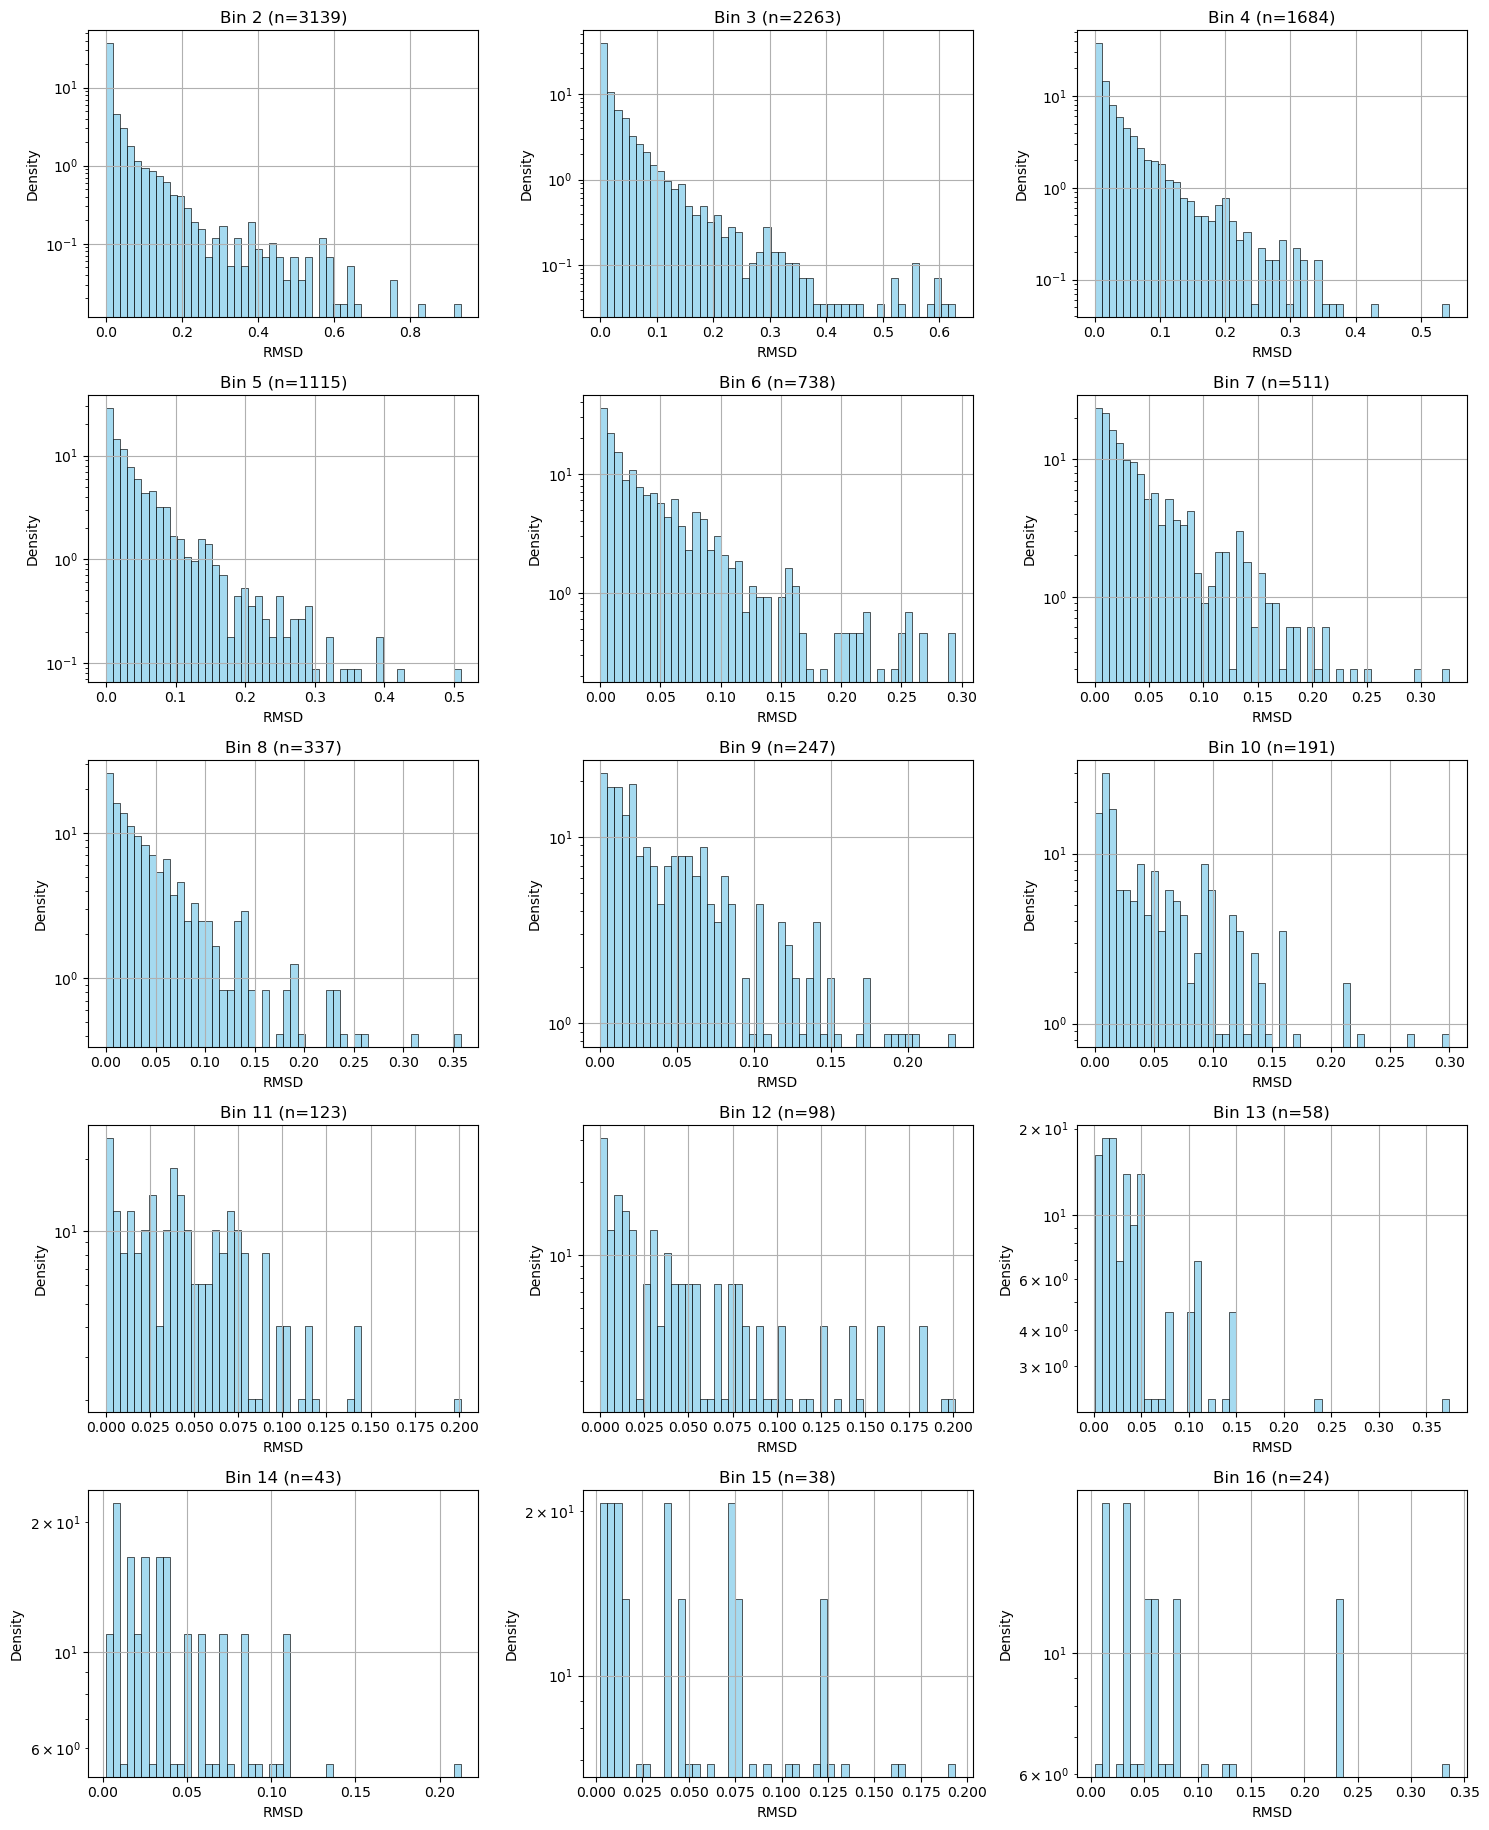

In [244]:
af.plot_distributions_from_result(result_table=result_table_psc_meso, metric="RMSD", max_bins_to_plot=15, logscale=True)

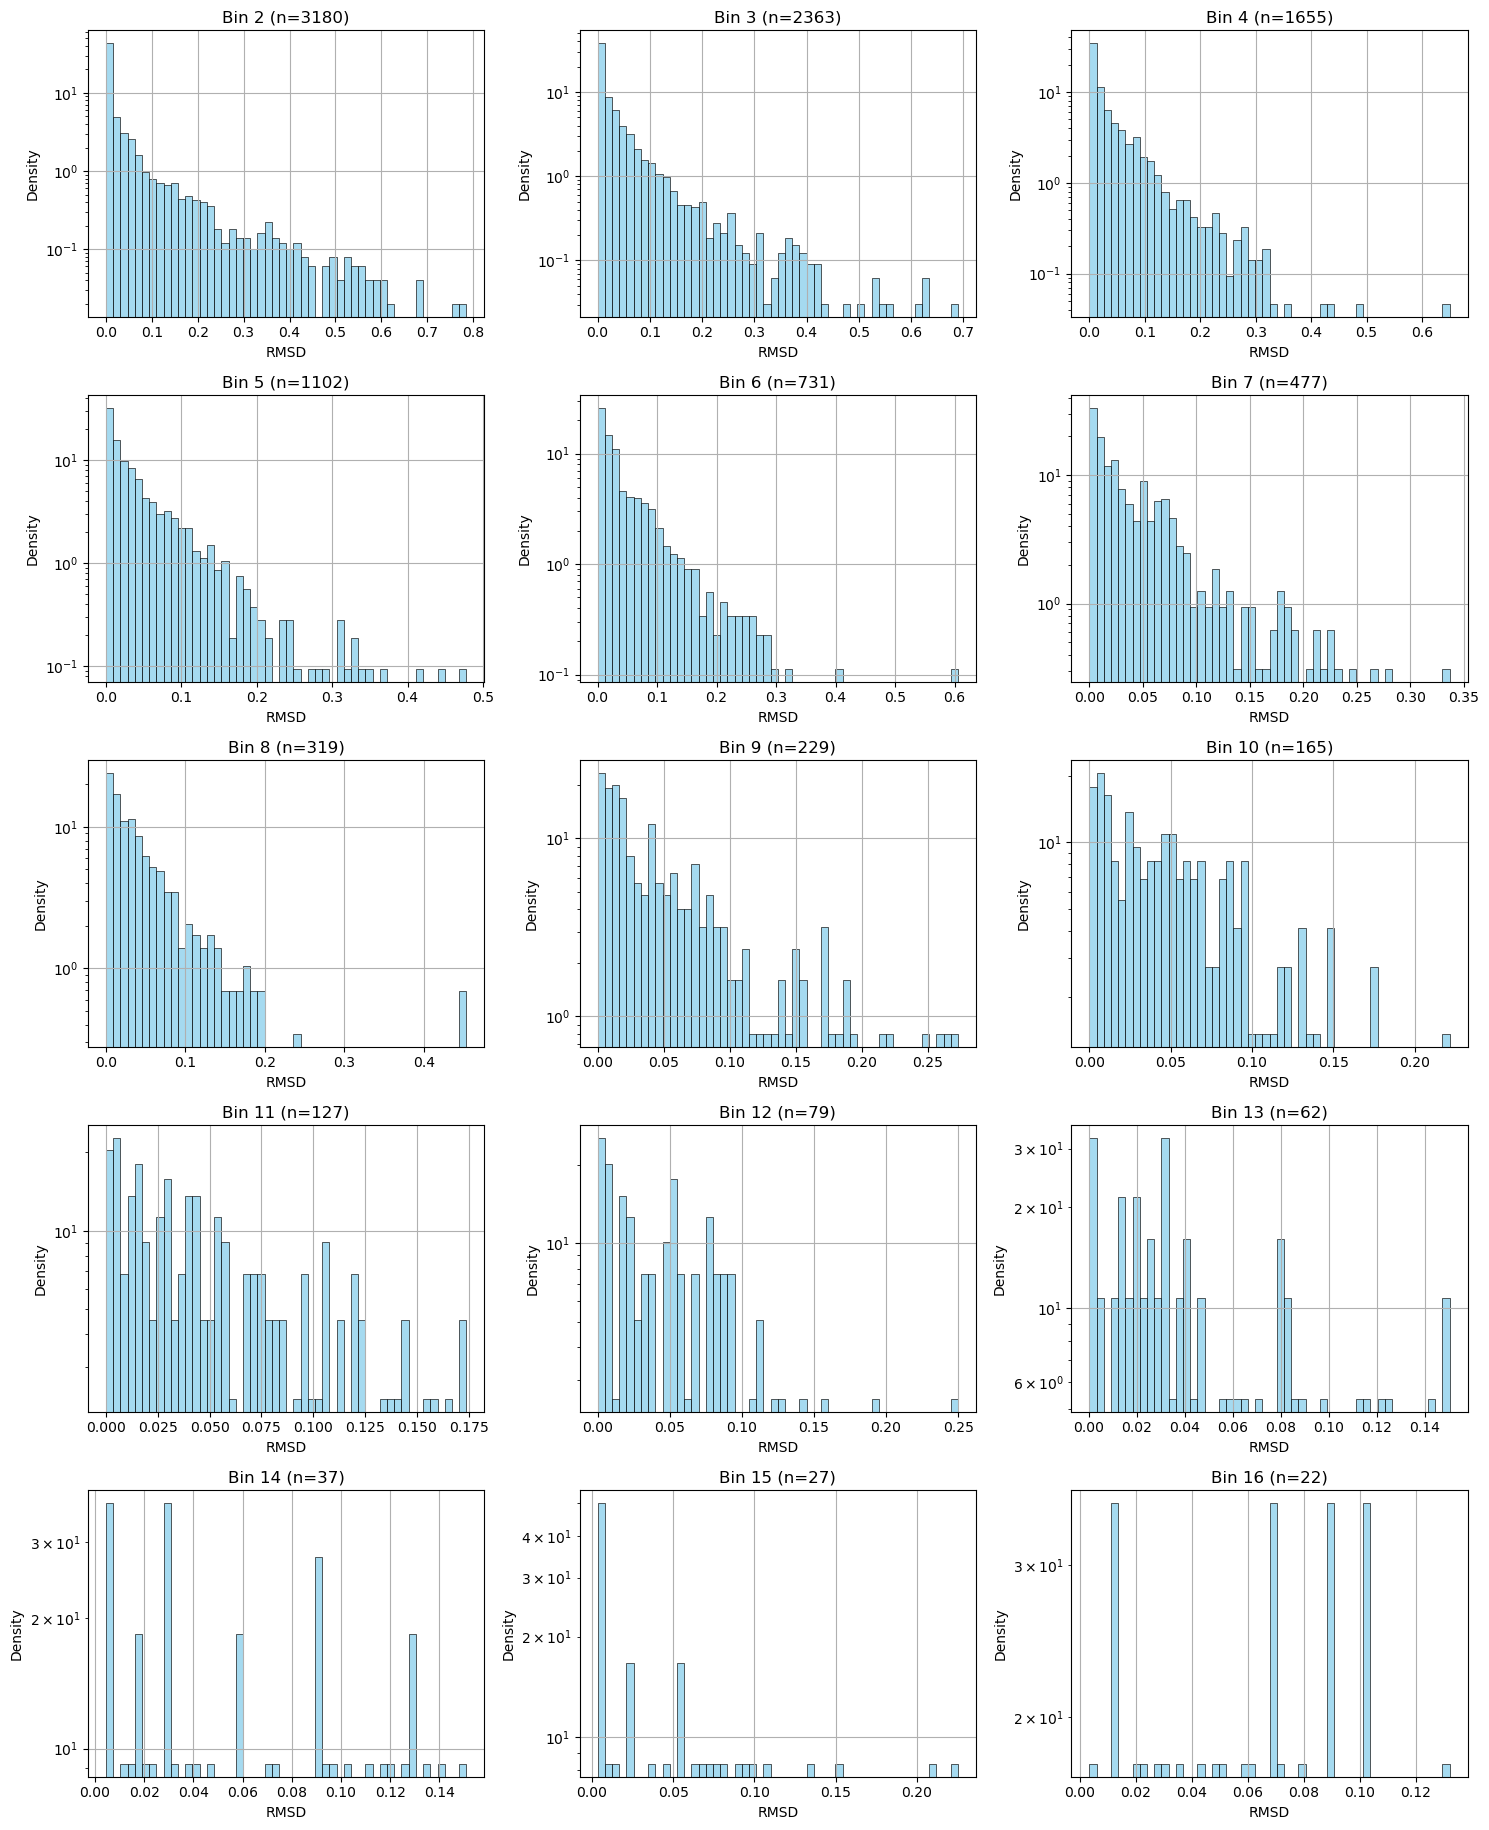

In [245]:
af.plot_distributions_from_result(result_table=result_table_meso_cardmeso, metric="RMSD", max_bins_to_plot=15, logscale=True)

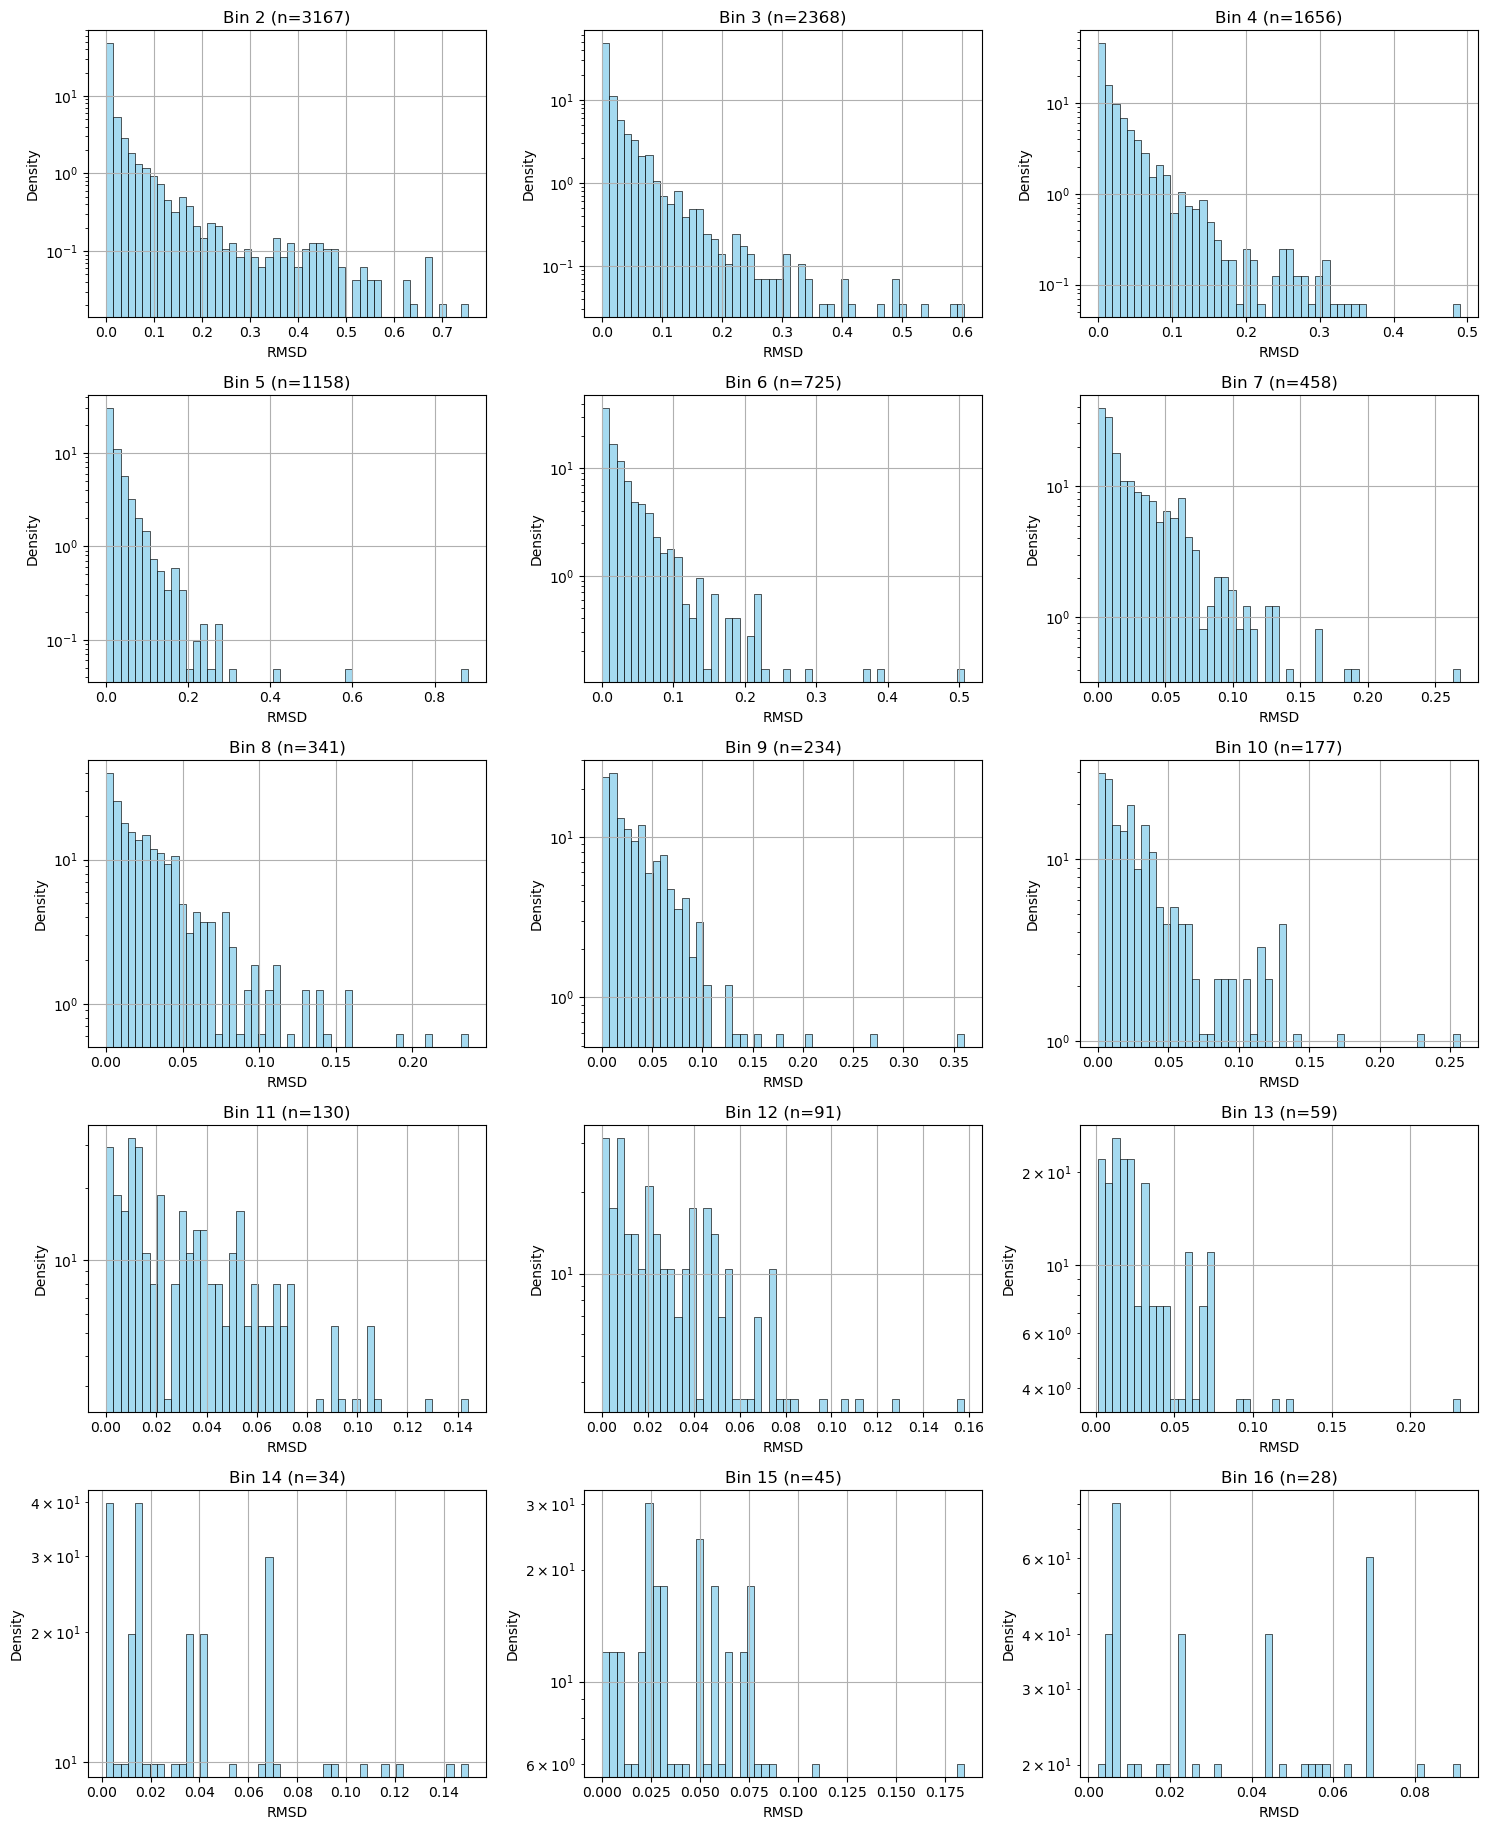

In [246]:
af.plot_distributions_from_result(result_table=result_table_cardmeso_cm, metric="RMSD", max_bins_to_plot=15, logscale=True)

### Calculate distances

In [247]:
pooled_by_AT_psc_meso_obs = {key: data["rmsd"] for key, data in grouped_by_AT_psc_meso.items()}
pooled_by_AT_meso_cardmeso_obs =  {key: data["rmsd"] for key, data in grouped_by_AT_meso_cardmeso.items()}
pooled_by_AT_cardmeso_cm_obs =  {key: data["rmsd"] for key, data in grouped_by_AT_cardmeso_cm.items()}

In [248]:
AT_gene_num_psc_meso = {key: len(set(data["genes"])) for key, data in grouped_by_AT_psc_meso.items()}
AT_gene_num_meso_cardmeso =  {key: len(set(data["genes"])) for key, data in grouped_by_AT_meso_cardmeso.items()}
AT_gene_cardmeso_cm =  {key: len(set(data["genes"])) for key, data in grouped_by_AT_cardmeso_cm.items()}

In [249]:
pooled_by_AT_psc_meso_filt = af.bin_filter(RMSD_pooled_by_AT=pooled_by_AT_psc_meso_obs,
                                        AT_gene_num=AT_gene_num_psc_meso,
                                        num_g=150)


In [250]:
pooled_by_AT_meso_cardmeso_filt = af.bin_filter(RMSD_pooled_by_AT=pooled_by_AT_meso_cardmeso_obs,
                                        AT_gene_num=AT_gene_num_meso_cardmeso,
                                        num_g=150)


In [251]:
pooled_by_AT_cardmeso_cm_filt = af.bin_filter(RMSD_pooled_by_AT=pooled_by_AT_cardmeso_cm_obs,
                                        AT_gene_num=AT_gene_cardmeso_cm,
                                        num_g=150)


In [252]:
emd_df_psc_meso, extras_psc_meso = af.compute_bin_pairwise_emd_resampled(pooled_by_bin=pooled_by_AT_psc_meso_filt, R=500, random_state=42)

In [253]:
emd_df_psc_meso

,2,3,4,5,6,7,8,9,10
2,0.000000,0.013084,0.016963,0.022517,0.023384,0.025754,0.026859,0.030222,0.031701
3,0.013084,0.000000,0.008869,0.014113,0.014382,0.016445,0.018010,0.020682,0.022970
4,0.016963,0.008869,0.000000,0.010025,0.009892,0.011889,0.013026,0.015800,0.017894
5,0.022517,0.014113,0.010025,0.000000,0.007498,0.008222,0.008268,0.010910,0.012061
6,0.023384,0.014382,0.009892,0.007498,0.000000,0.006528,0.007988,0.008851,0.011870
7,0.025754,0.016445,0.011889,0.008222,0.006528,0.000000,0.006884,0.006990,0.009747
8,0.026859,0.018010,0.013026,0.008268,0.007988,0.006884,0.000000,0.007238,0.008615
9,0.030222,0.020682,0.015800,0.010910,0.008851,0.006990,0.007238,0.000000,0.007968
10,0.031701,0.022970,0.017894,0.012061,0.011870,0.009747,0.008615,0.007968,0.000000


In [254]:
extras_psc_meso["min_n"]

191

In [255]:
emd_df_meso_cardmeso, extras_meso_cardmeso = af.compute_bin_pairwise_emd_resampled(pooled_by_bin=pooled_by_AT_meso_cardmeso_filt, R=500, random_state=42)

In [256]:
emd_df_meso_cardmeso

,2,3,4,5,6,7,8,9,10
2,0.000000,0.013735,0.018589,0.022483,0.023715,0.024455,0.026069,0.029184,0.035551
3,0.013735,0.000000,0.010418,0.013413,0.015366,0.015530,0.017445,0.020106,0.026067
4,0.018589,0.010418,0.000000,0.008728,0.009454,0.009946,0.012170,0.014383,0.019574
5,0.022483,0.013413,0.008728,0.000000,0.007887,0.007750,0.008862,0.010197,0.015339
6,0.023715,0.015366,0.009454,0.007887,0.000000,0.007926,0.008834,0.009333,0.014852
7,0.024455,0.015530,0.009946,0.007750,0.007926,0.000000,0.007615,0.009256,0.012862
8,0.026069,0.017445,0.012170,0.008862,0.008834,0.007615,0.000000,0.009513,0.011504
9,0.029184,0.020106,0.014383,0.010197,0.009333,0.009256,0.009513,0.000000,0.010965
10,0.035551,0.026067,0.019574,0.015339,0.014852,0.012862,0.011504,0.010965,0.000000


In [257]:
extras_meso_cardmeso["min_n"]

165

In [258]:
emd_df_cardmeso_cm, extras_cardmeso_cm = af.compute_bin_pairwise_emd_resampled(pooled_by_bin=pooled_by_AT_cardmeso_cm_filt, R=500, random_state=42)

In [259]:
emd_df_cardmeso_cm

,2,3,4,5,6,7,8,9,10
2,0.000000,0.011973,0.015738,0.018071,0.019042,0.022407,0.022541,0.025988,0.023870
3,0.011973,0.000000,0.007556,0.009394,0.010616,0.012386,0.012717,0.016721,0.014650
4,0.015738,0.007556,0.000000,0.006746,0.007204,0.008783,0.009126,0.013022,0.010335
5,0.018071,0.009394,0.006746,0.000000,0.006663,0.007170,0.007493,0.011904,0.009633
6,0.019042,0.010616,0.007204,0.006663,0.000000,0.006932,0.006911,0.009841,0.007749
7,0.022407,0.012386,0.008783,0.007170,0.006932,0.000000,0.004867,0.008848,0.007321
8,0.022541,0.012717,0.009126,0.007493,0.006911,0.004867,0.000000,0.008232,0.006304
9,0.025988,0.016721,0.013022,0.011904,0.009841,0.008848,0.008232,0.000000,0.007143
10,0.023870,0.014650,0.010335,0.009633,0.007749,0.007321,0.006304,0.007143,0.000000


In [260]:
extras_cardmeso_cm["min_n"]

177

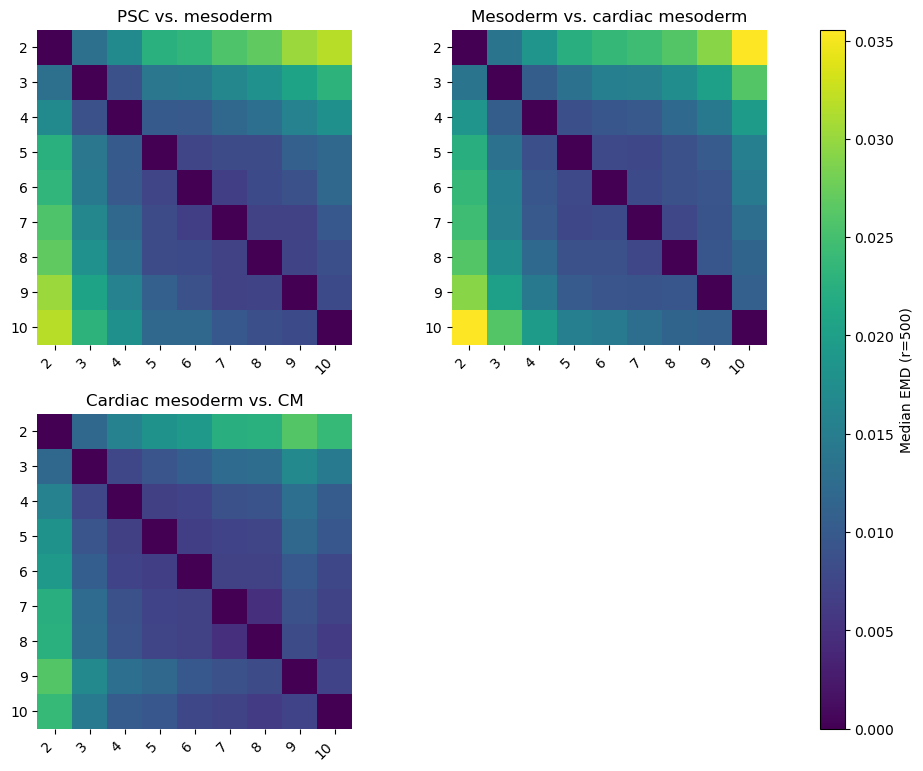

In [261]:
af.heatmap_EMD_dists([emd_df_psc_meso, emd_df_meso_cardmeso, emd_df_cardmeso_cm], titles=["PSC vs. mesoderm", "Mesoderm vs. cardiac mesoderm", "Cardiac mesoderm vs. CM"], cbar_label="Median EMD (r=500)")

In [262]:
per_gap_df_psc_meso = af.half_gap_compare(extras_psc_meso,
                                          lower_bins=[2,3,4,5],
                                          upper_bins=[7,8,9,10],
                                          gaps=(1,2,3))

In [263]:
per_gap_df_psc_meso

,gap,n_pairs_lower,n_pairs_upper,lower_median,lower_ci_low,lower_ci_high,upper_median,upper_ci_low,upper_ci_high,n_repeats
0,1,3,3,0.010727,0.006567,0.016250,0.007288,0.004672,0.012101,500
1,2,2,2,0.015687,0.010571,0.021604,0.007974,0.005061,0.013129,500
2,3,1,1,0.022517,0.015098,0.031958,0.009747,0.004877,0.018186,500


In [264]:
per_gap_df_meso_cardmeso = af.half_gap_compare(extras_meso_cardmeso,
                                          lower_bins=[2,3,4,5],
                                          upper_bins=[7,8,9,10],
                                          gaps=(1,2,3))

In [265]:
per_gap_df_cardmeso_cm = af.half_gap_compare(extras_cardmeso_cm,
                                          lower_bins=[2,3,4,5],
                                          upper_bins=[7,8,9,10],
                                          gaps=(1,2,3))

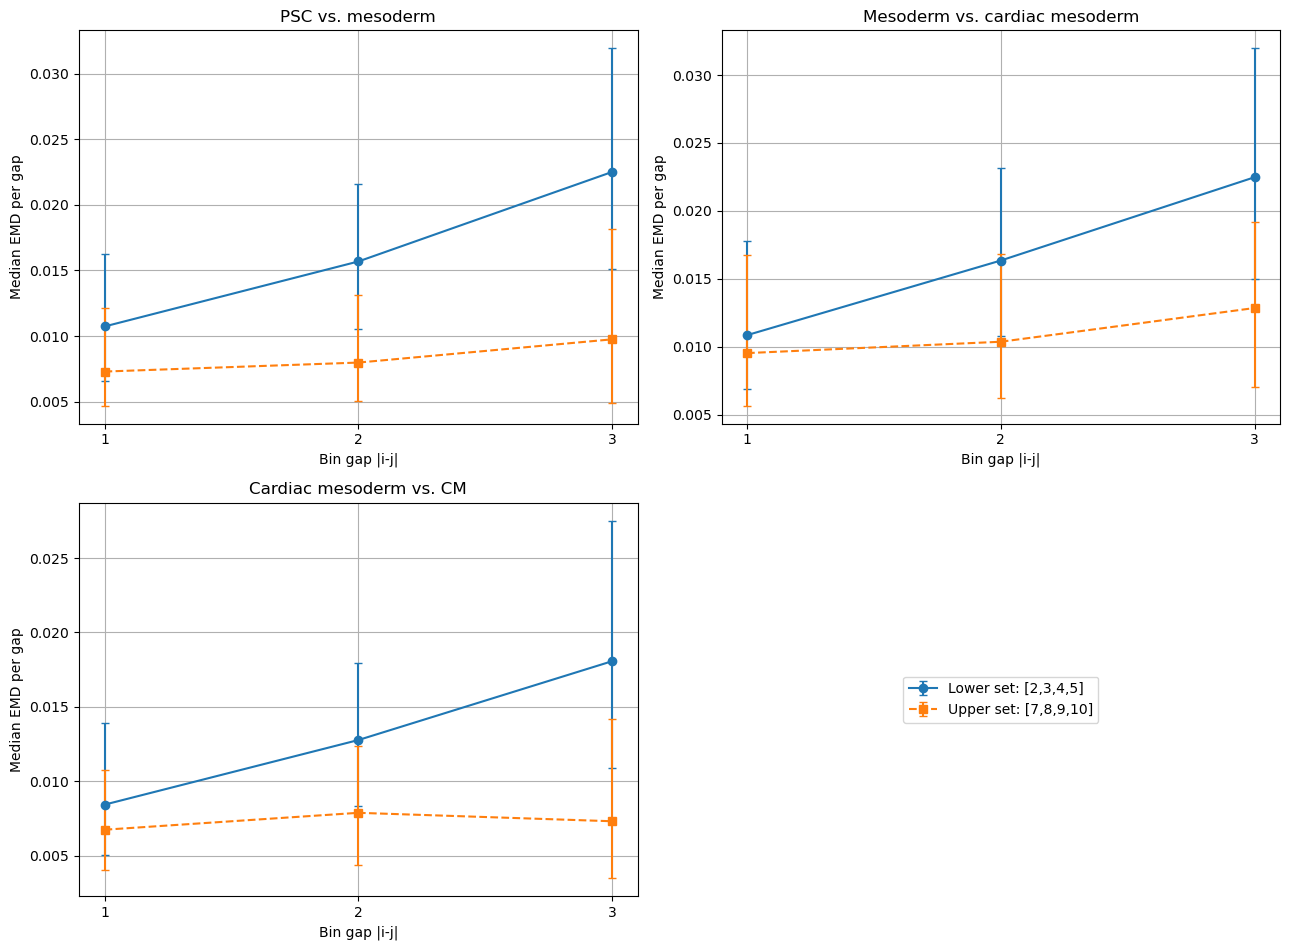

In [266]:
af.plot_half_gap_compare_multi([per_gap_df_psc_meso, per_gap_df_meso_cardmeso, per_gap_df_cardmeso_cm],titles=["PSC vs. mesoderm", "Mesoderm vs. cardiac mesoderm", "Cardiac mesoderm vs. CM"], suptitle="")

## MPD and JSD Histograms

**Comparison: PSC vs. mesoderm**

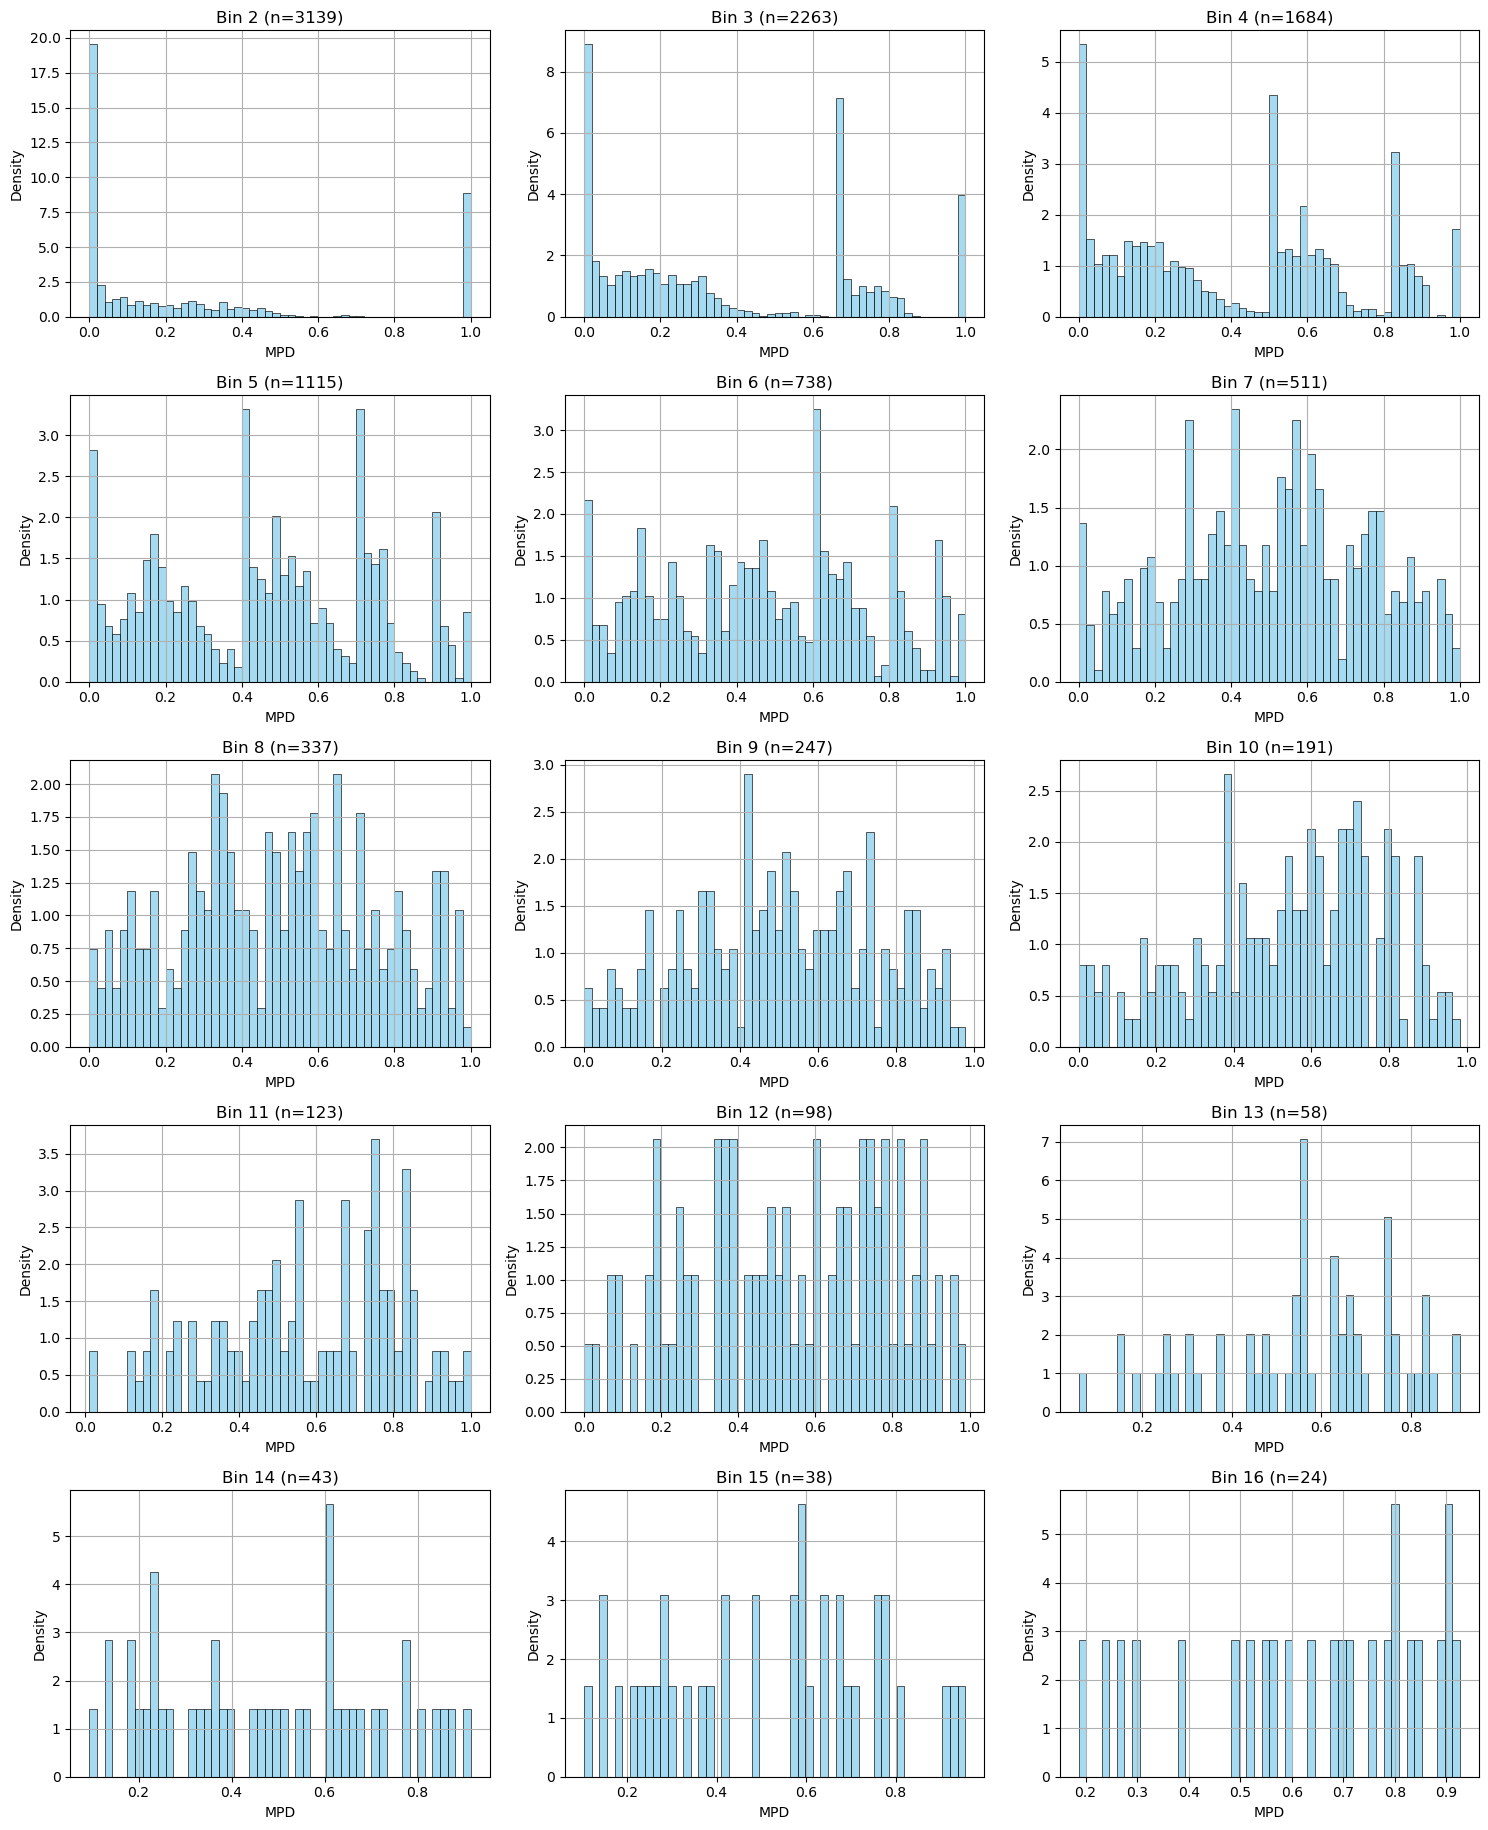

In [267]:
af.plot_distributions_from_result(result_table=result_table_psc_meso, metric="MPD", max_bins_to_plot=15, logscale=False)

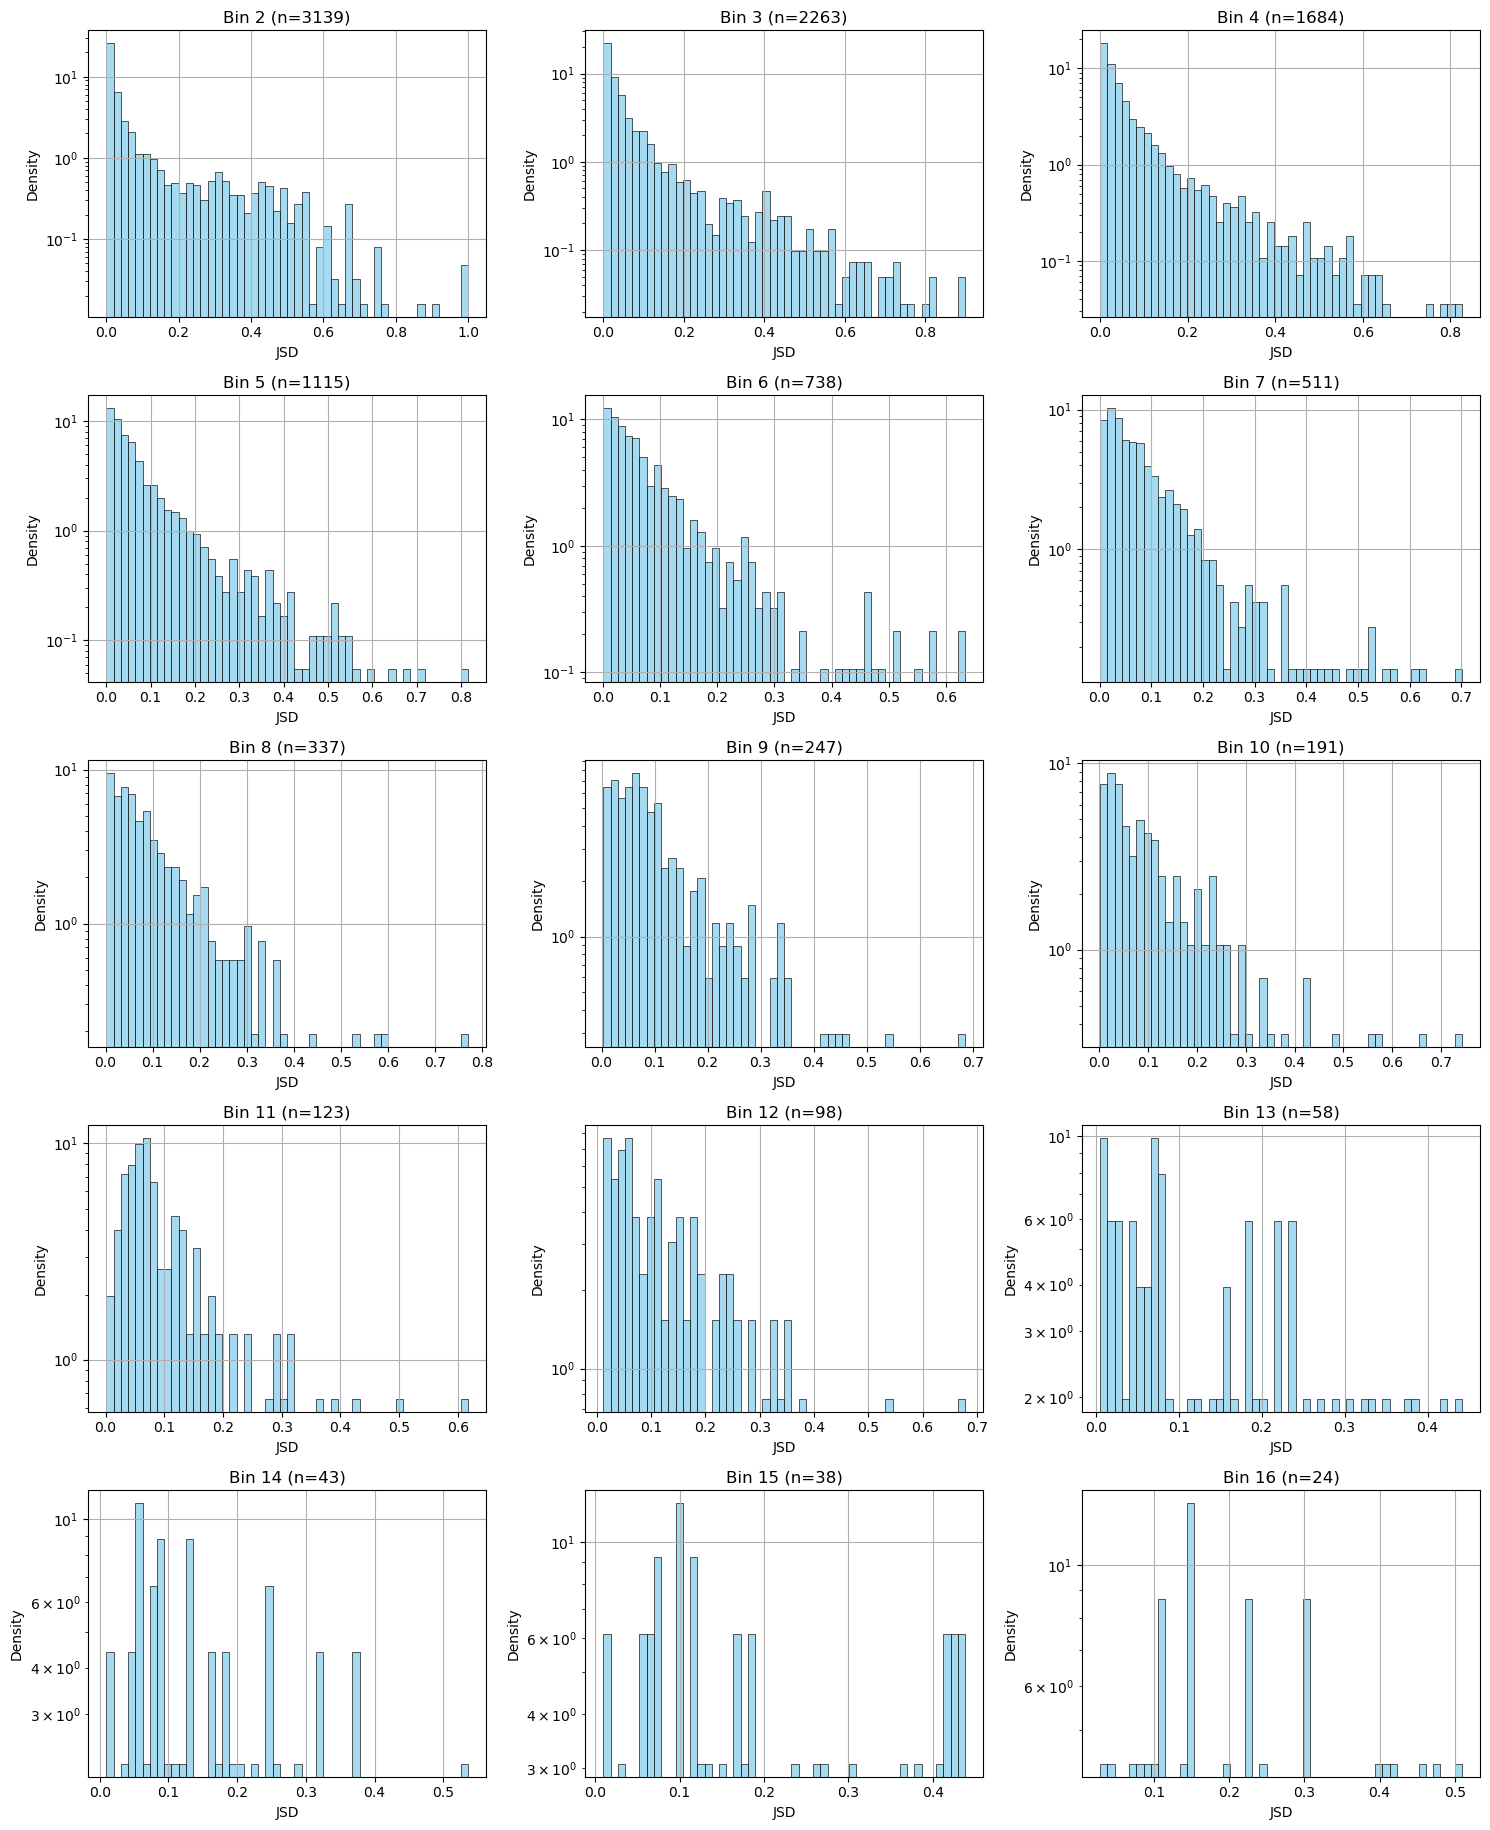

In [268]:
af.plot_distributions_from_result(result_table=result_table_psc_meso, metric="JSD", max_bins_to_plot=15, logscale=True)

**Comparison: Mesoderm vs. cardmeso**

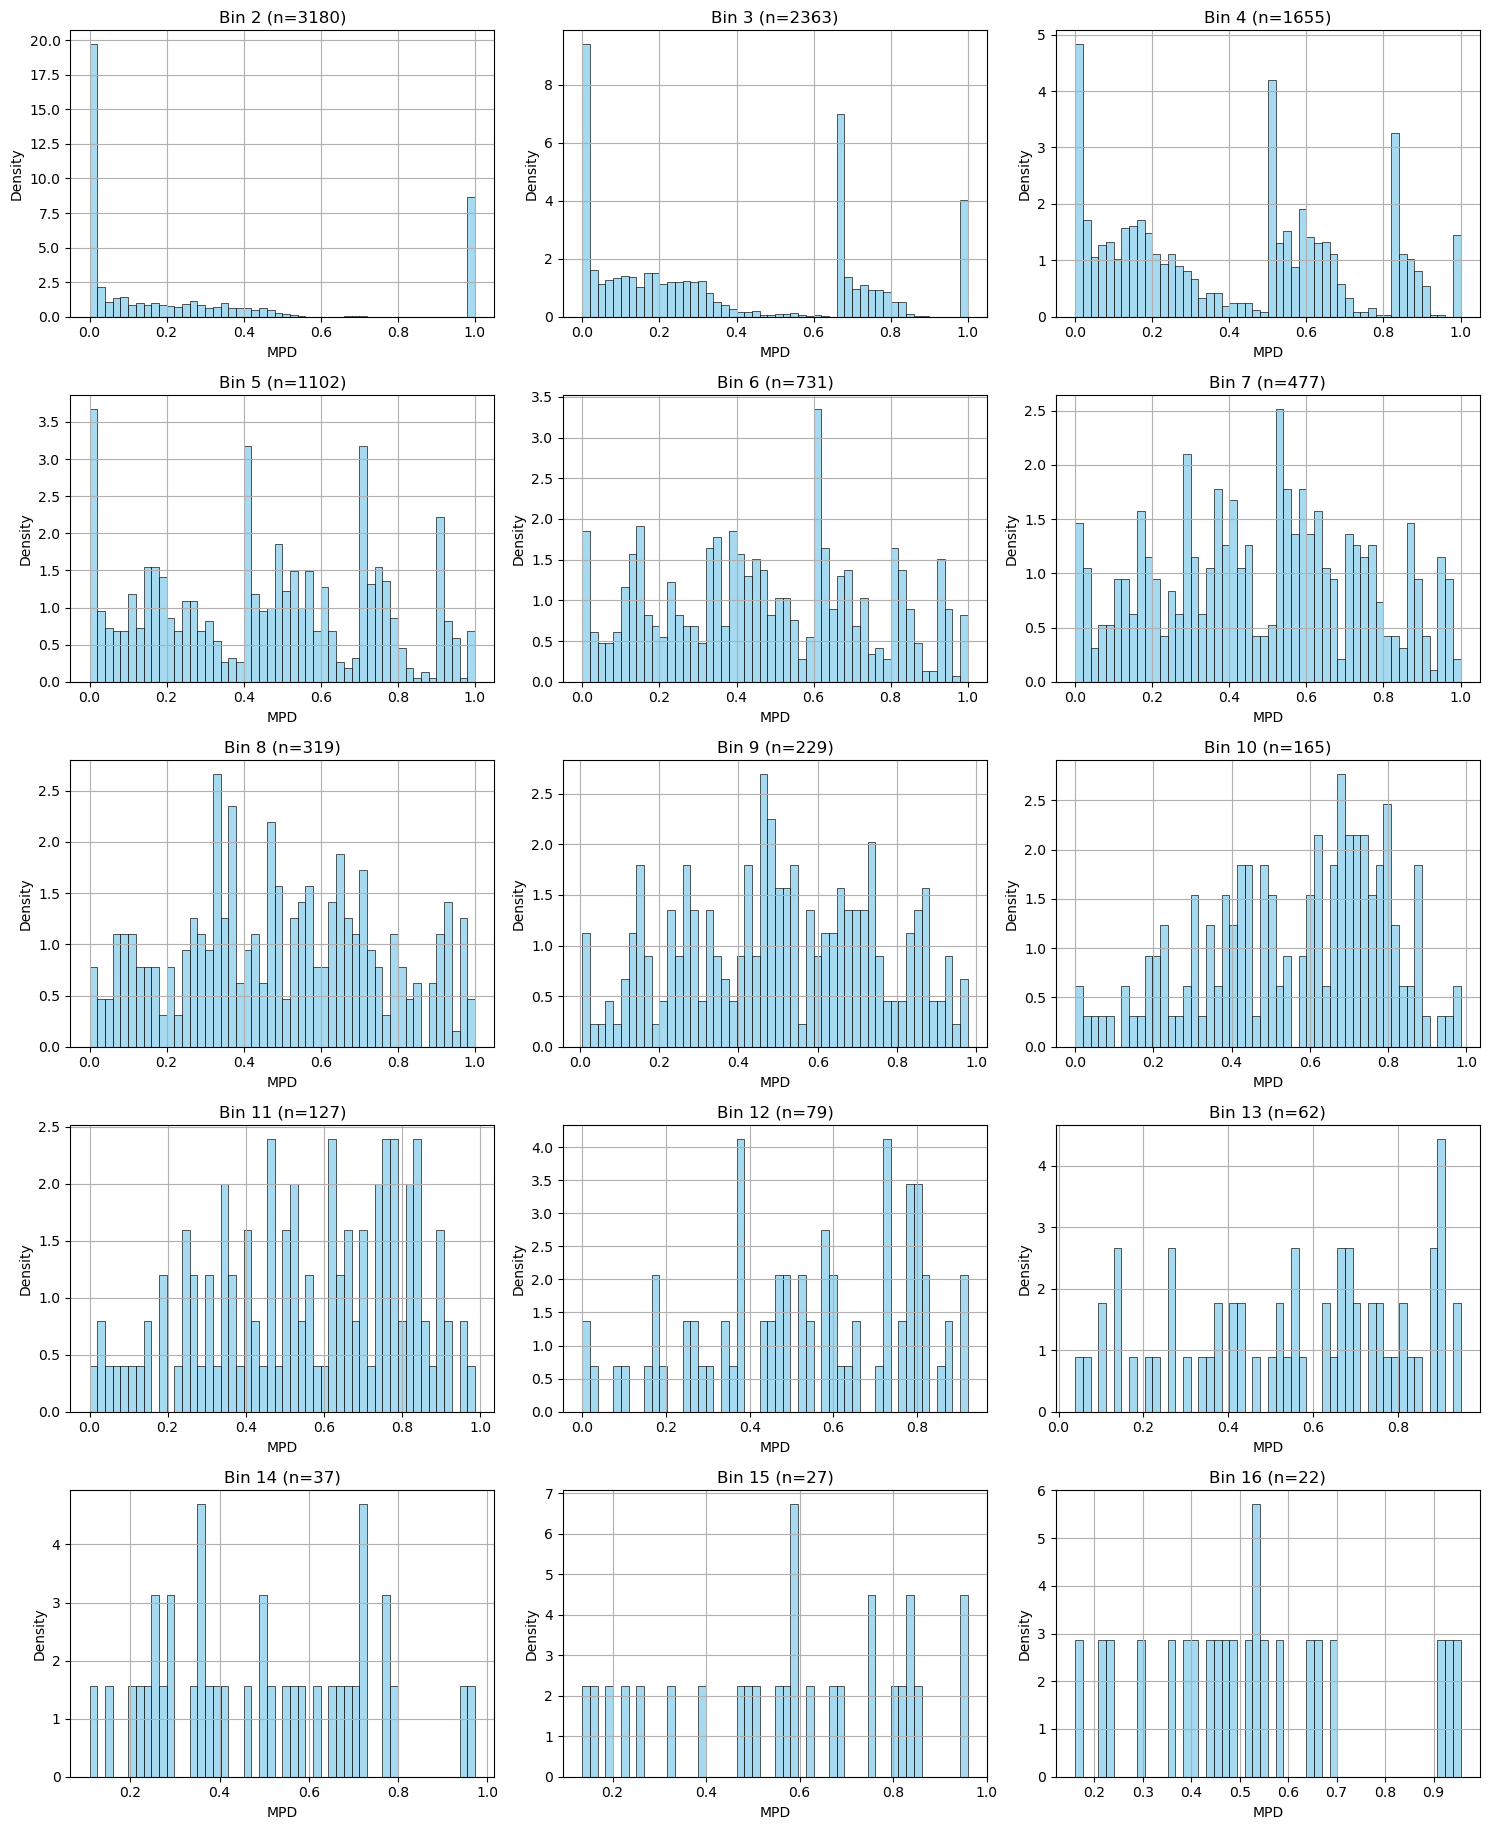

In [269]:
af.plot_distributions_from_result(result_table=result_table_meso_cardmeso, metric="MPD", max_bins_to_plot=15, logscale=False)

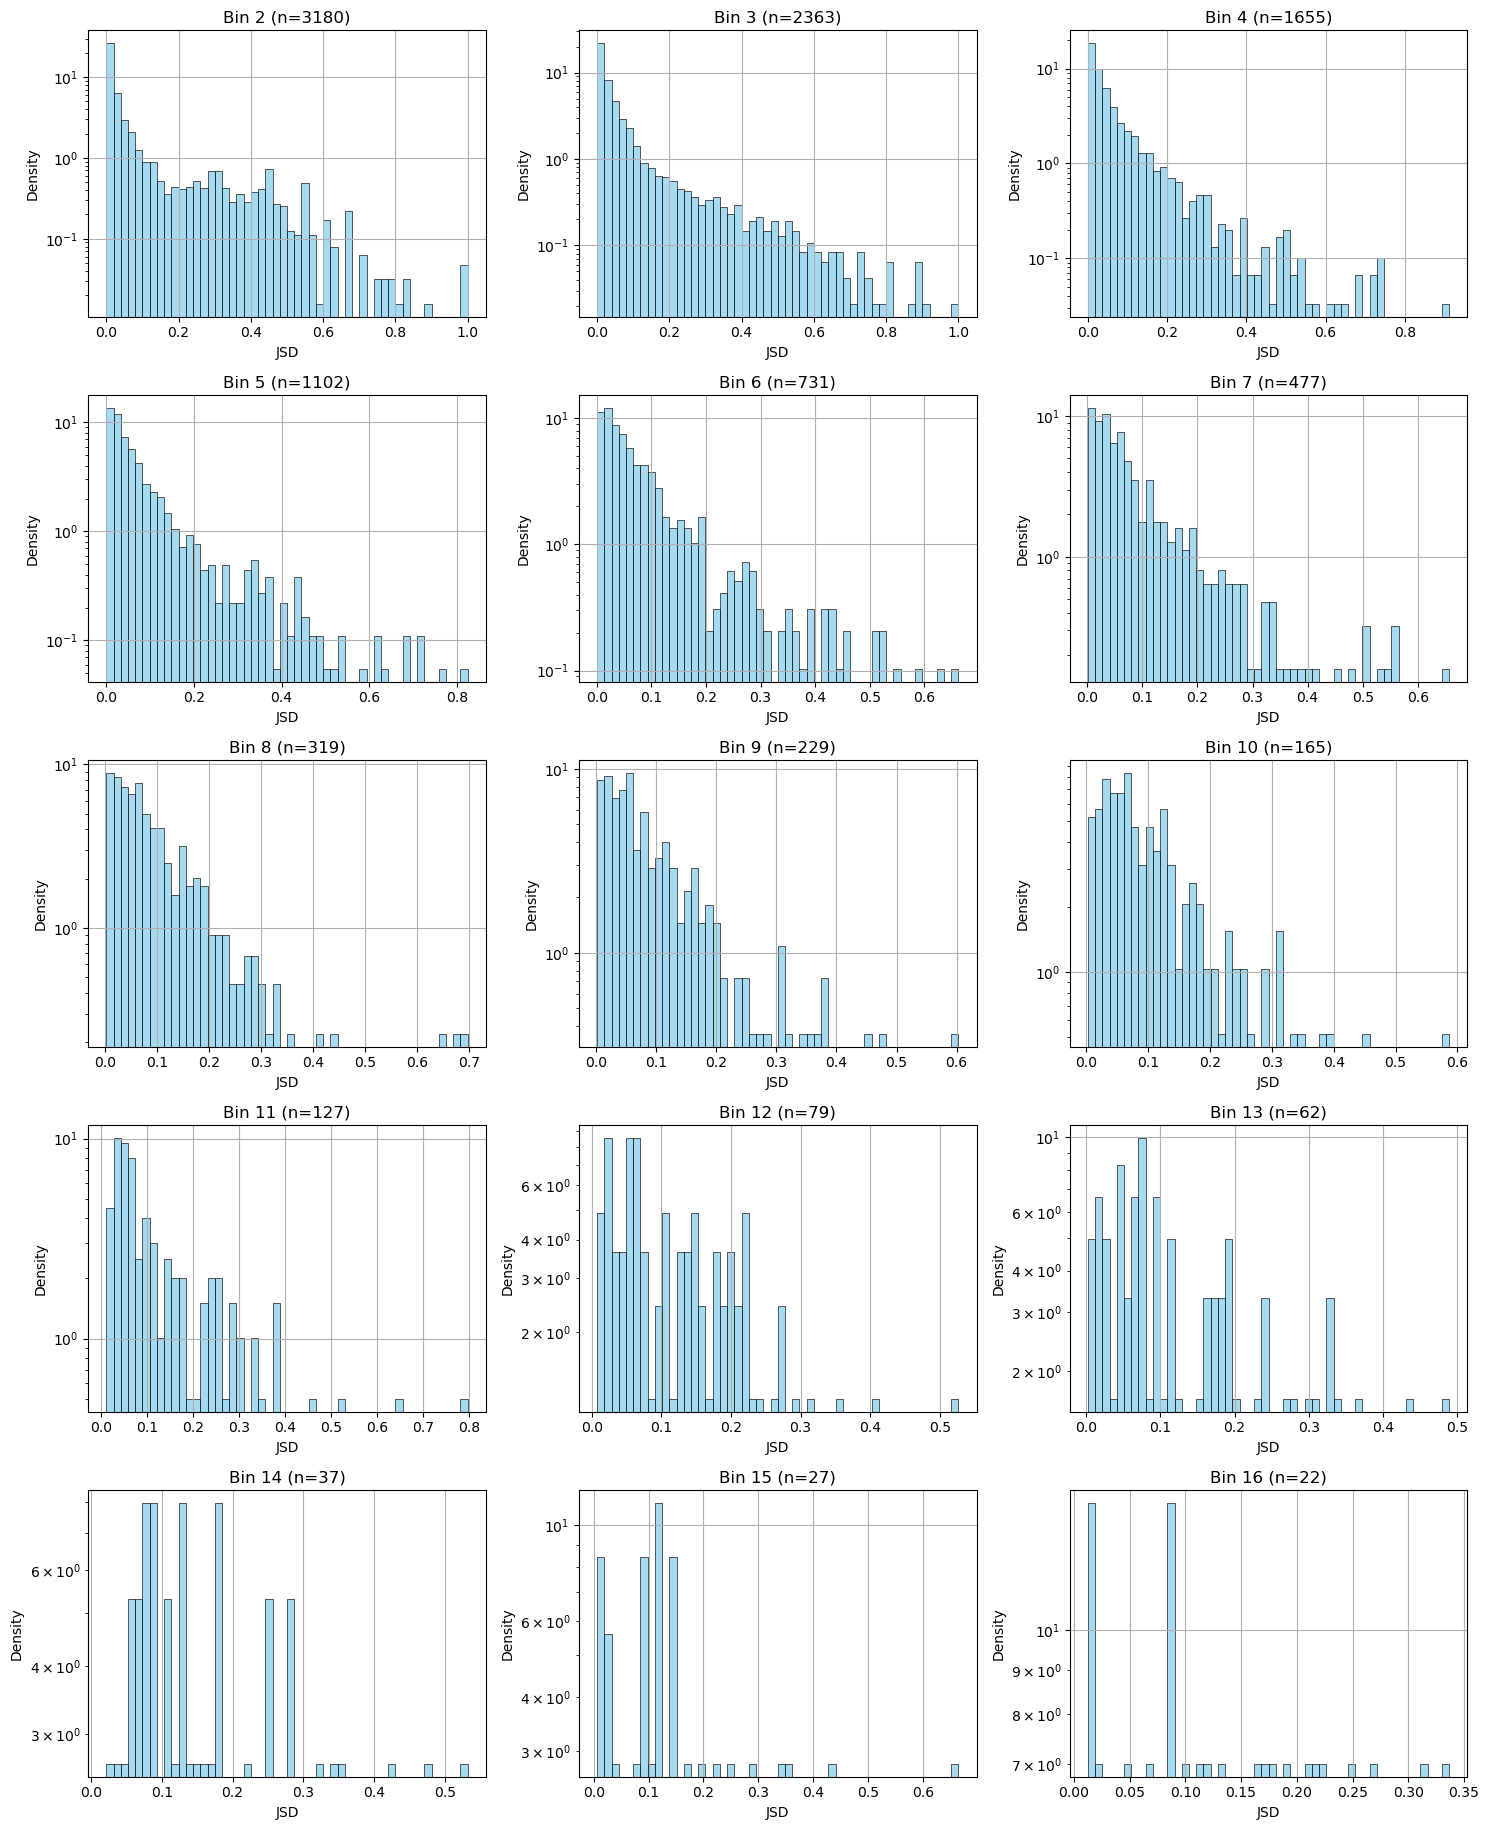

In [270]:
af.plot_distributions_from_result(result_table=result_table_meso_cardmeso, metric="JSD", max_bins_to_plot=15, logscale=True)

**Comparison: Cardmeso vs. CM**

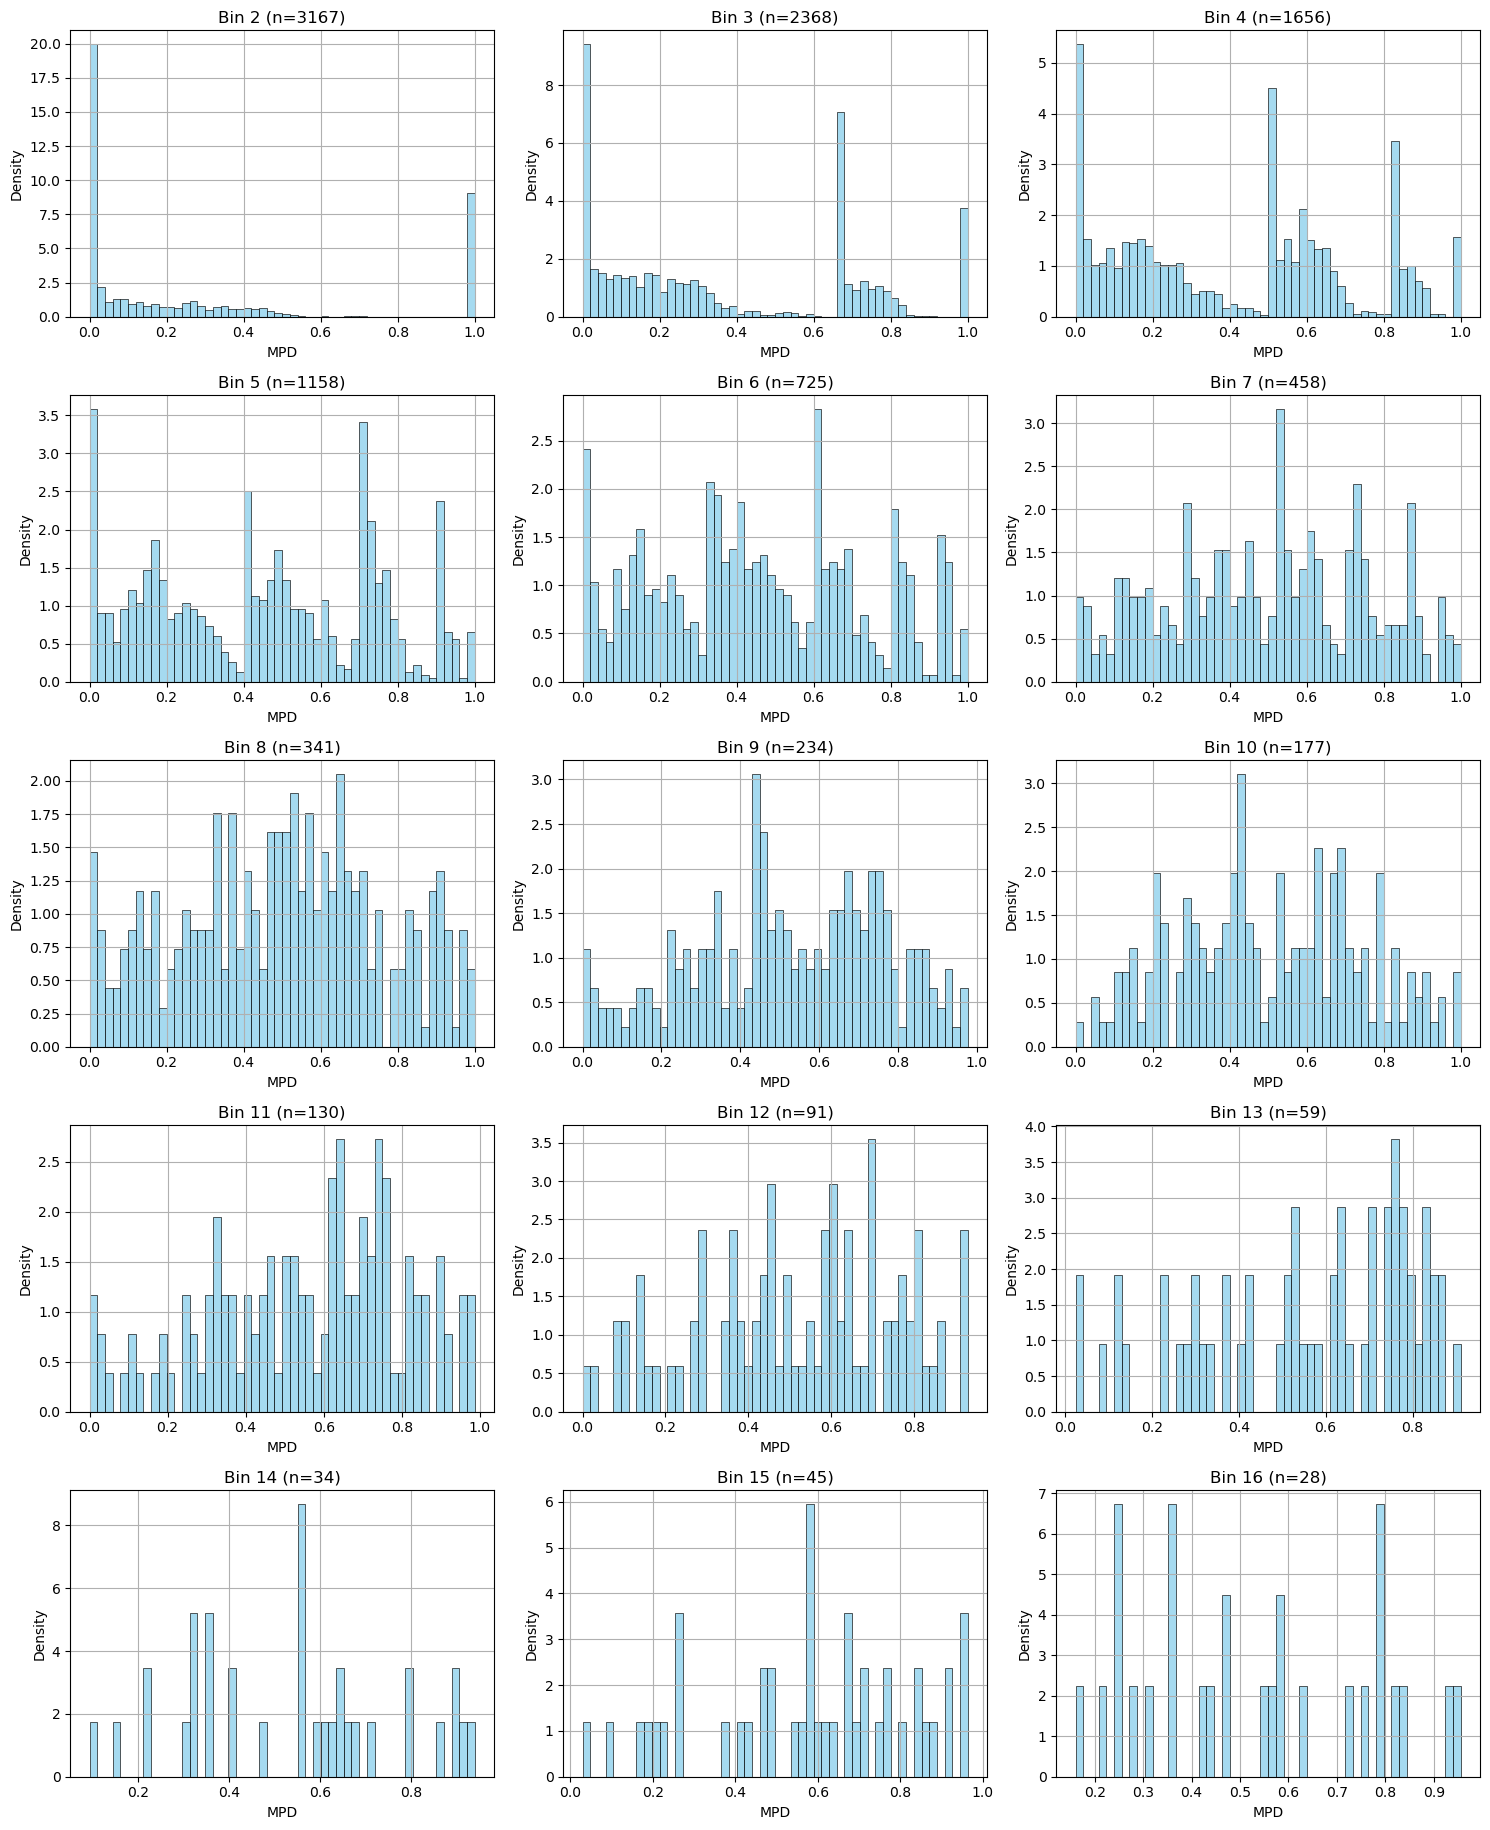

In [271]:
af.plot_distributions_from_result(result_table=result_table_cardmeso_cm, metric="MPD", max_bins_to_plot=15, logscale=False)

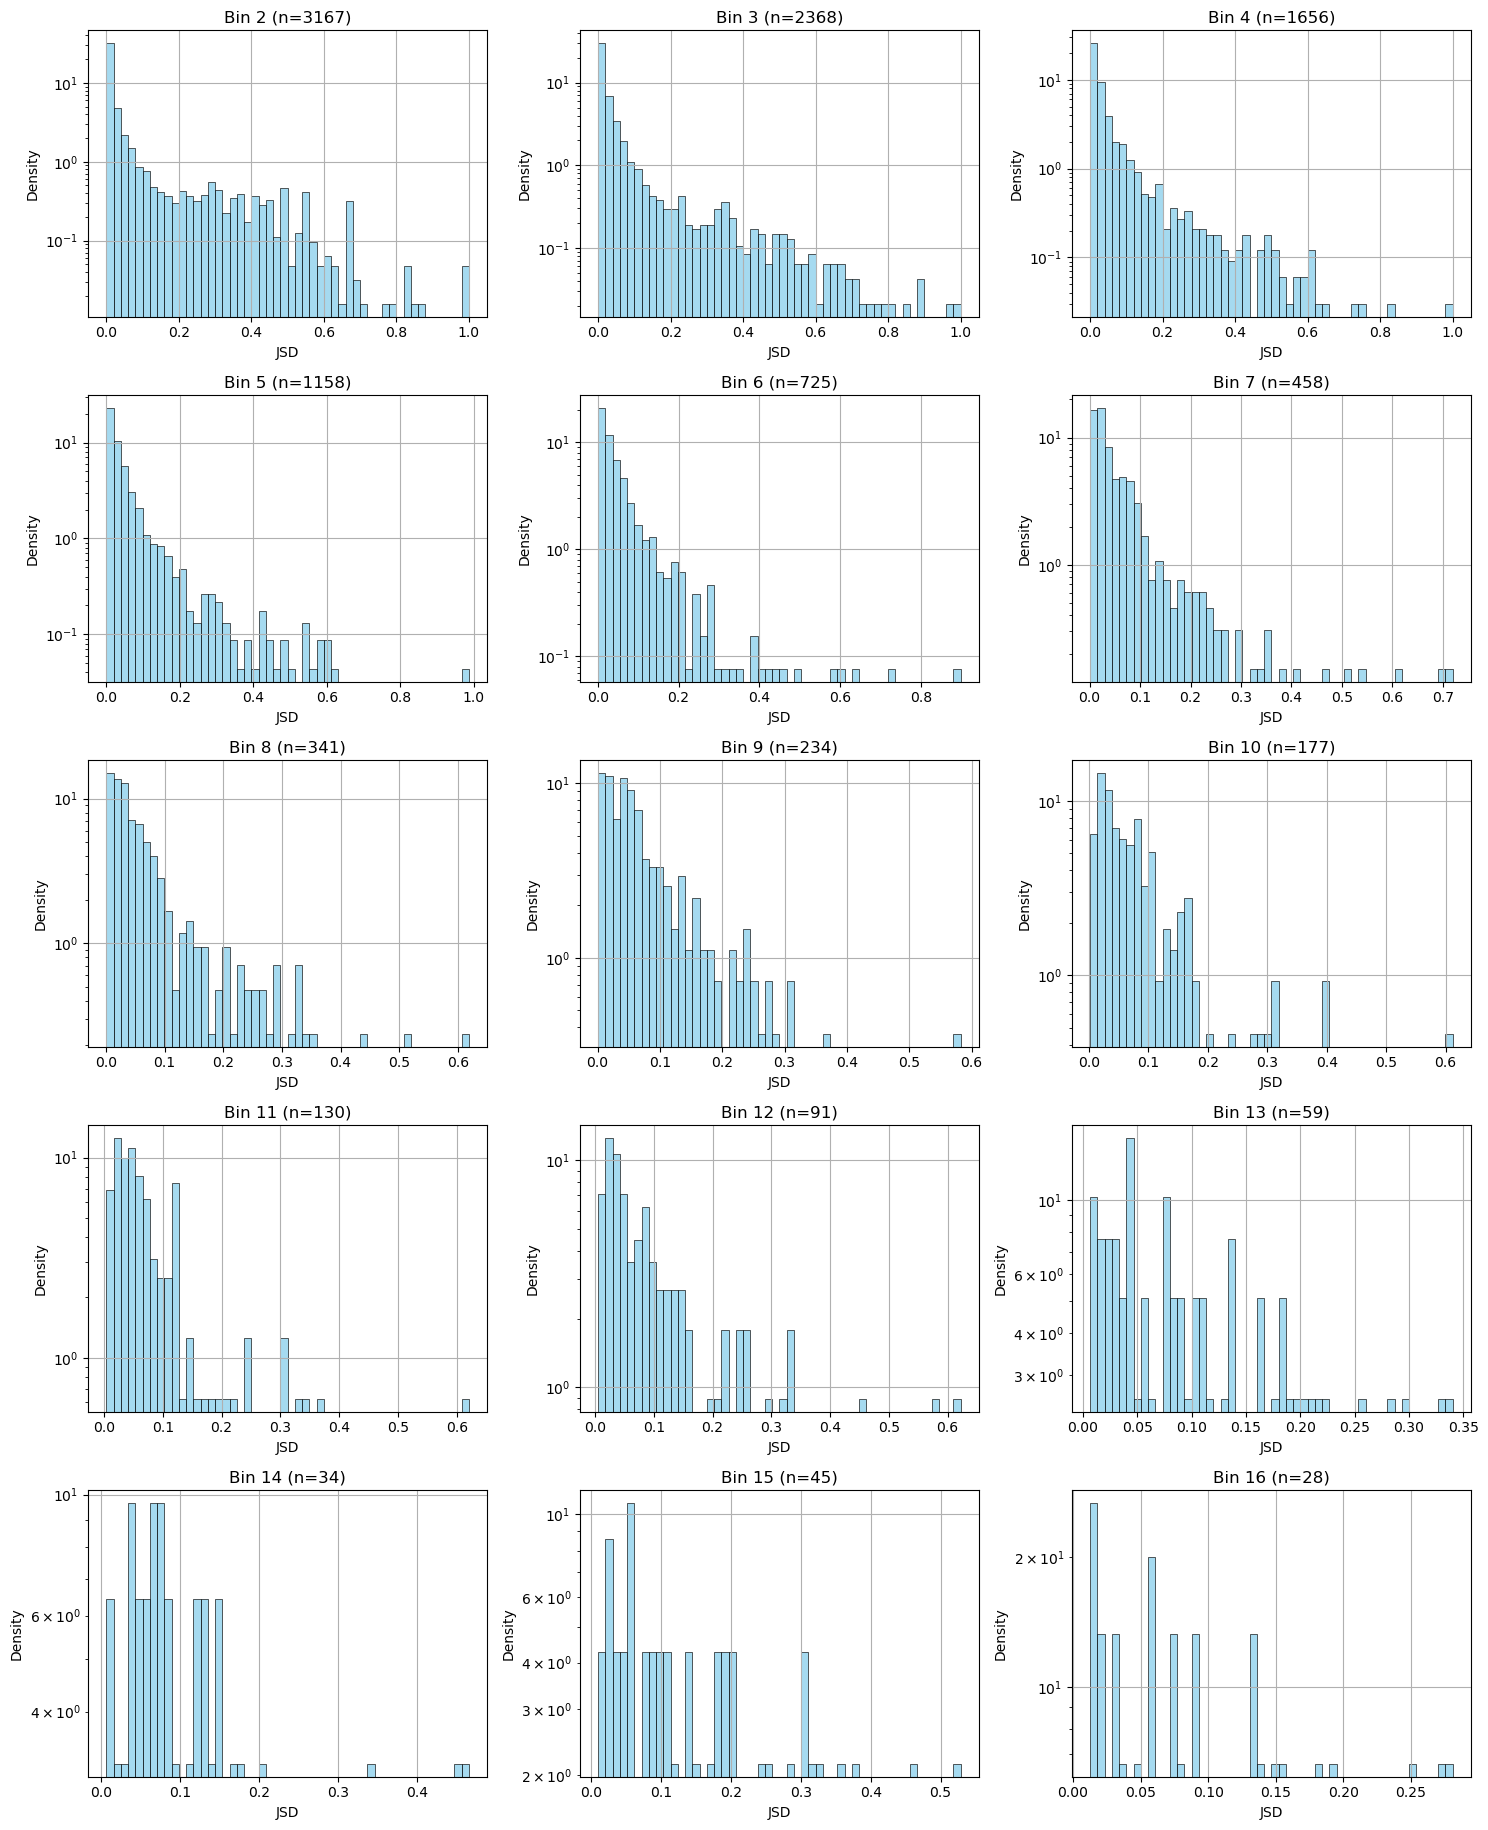

In [272]:
af.plot_distributions_from_result(result_table=result_table_cardmeso_cm, metric="JSD", max_bins_to_plot=15, logscale=True)

## Correlation of MPD and JSD with RMSD

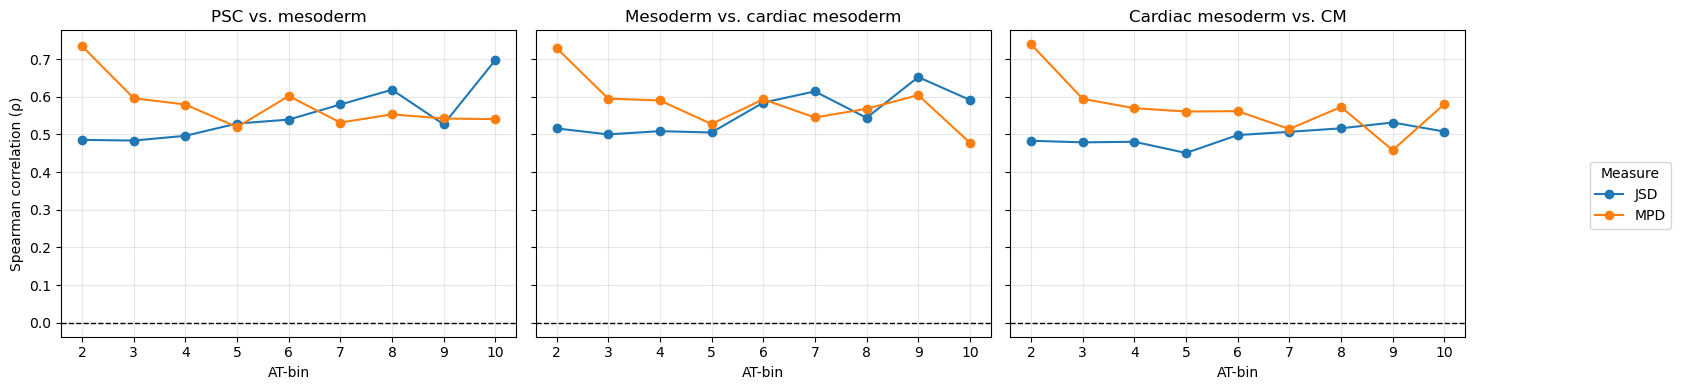

In [273]:
bin_dicts = {
"PSC vs. mesoderm": pooled_by_AT_psc_meso_obs,
"Mesoderm vs. cardiac mesoderm": pooled_by_AT_meso_cardmeso_obs,
"Cardiac mesoderm vs. CM": pooled_by_AT_cardmeso_cm_obs
}

data = {
"PSC vs. mesoderm": result_table_psc_meso,
"Mesoderm vs. cardiac mesoderm": result_table_meso_cardmeso,
"Cardiac mesoderm vs. CM": result_table_cardmeso_cm
}
metrics = ("JSD", "MPD")
items = list(bin_dicts.items())
n = len(items)
ncols = 3
nrows = 1
figsize_per_ax=(5.5, 4.0)
fig_w = figsize_per_ax[0] * ncols
fig_h = figsize_per_ax[1] * nrows
fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), sharey=True)
axes = np.array(axes).reshape(-1)
all_results = []
for i, (name, bdict) in enumerate(items):
    ax = axes[i]
    # choose result df
    df = data[name]
    bins = [2,3,4,5,6,7,8,9,10]
    for b in bins:
        subset = df[df["AT"] == b]
        # only consider those genes which RMSD is not zero
        subset = subset[subset["RMSD"] != 0]
        for m in metrics:
            rho, pval = stats.spearmanr(
                subset["RMSD"], subset[m], nan_policy="omit"
            )
            all_results.append(
                dict(panel=name, bin=b, metric=m,
                        rho=rho, pval=pval, n=len(subset))
            )
    panel_df = pd.DataFrame(
        [r for r in all_results if r["panel"] == name]
    )
    order = sorted(panel_df["bin"].dropna().unique())
    #order = [b for b in order if b != special_last] + [special_last]

    bin_to_pos = {b: j for j, b in enumerate(order)}
    panel_df["bin_pos"] = panel_df["bin"].map(bin_to_pos)

    for m in metrics:
        mdf = panel_df[panel_df["metric"] == m].sort_values("bin_pos")
        ax.plot(mdf["bin_pos"], mdf["rho"], marker="o", label=m)

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([str(b) for b in order])
    ax.set_xlabel("AT-bin")
    ax.grid(True, alpha=0.3)

    if i % ncols == 0:
        ax.set_ylabel("Spearman correlation (ρ)")

    ax.legend().remove()


for j in range(n, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Measure",
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
)

fig.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for legend
plt.show()


In [274]:
print(pd.DataFrame(all_results))

                            panel  bin metric       rho           pval     n
0                PSC vs. mesoderm    2    JSD  0.485615  1.737136e-152  2575
1                PSC vs. mesoderm    2    MPD  0.734458   0.000000e+00  2575
2                PSC vs. mesoderm    3    JSD  0.483762  9.871261e-125  2119
3                PSC vs. mesoderm    3    MPD  0.596198  3.626610e-204  2119
4                PSC vs. mesoderm    4    JSD  0.496421  1.609648e-102  1636
5                PSC vs. mesoderm    4    MPD  0.579486  2.227554e-147  1636
6                PSC vs. mesoderm    5    JSD  0.528907   4.288218e-80  1097
7                PSC vs. mesoderm    5    MPD  0.519470   7.656021e-77  1097
8                PSC vs. mesoderm    6    JSD  0.539419   1.693468e-56   732
9                PSC vs. mesoderm    6    MPD  0.602076   2.118184e-73   732
10               PSC vs. mesoderm    7    JSD  0.579536   6.551516e-47   508
11               PSC vs. mesoderm    7    MPD  0.531492   2.225662e-38   508

## Requirements for reaching RMSD of 1

*Requirements*
- Transcripts of genes can be split into two disjoint sets
- Within a set: Maximal similarity (FAS score: 1, 1-complement FAS score: 0)
- Between sets: Maximal dissimilarity (FAS score: 0, 1-complement FAS score: 1)
  
*Pattern search*
- Treat each gene as a graph where (active) isoforms are nodes
- Draw an edge between two isoforms if they are maximally similar in terms of FA
- Search for connected compontents within a gene using DFS
- Report a hit if there are two connected components

In [275]:
AT_bin_genes_psc_meso = defaultdict(int)
for bin, data in grouped_by_AT_psc_meso.items():
    AT_bin_genes_psc_meso[bin] = data["genes"]
AT_bin_genes_psc_meso = dict(AT_bin_genes_psc_meso)

In [276]:
hits_by_bin = af.find_two_cluster_genes_by_txcount_active_only(
    AT_bin_genes_psc_meso,
    fas_index=fas_index,
    fas_scores_fullpath=fas_scores_fullpath,
    gene_cache_with_active_ids=gene_cache_psc_meso
)

# print("Bins with hits:", sorted(hits_by_bin.keys()))
# for tx_count in sorted(hits_by_bin.keys())[:10]:
#     print(f"\n== {tx_count} transcripts ==")
#     for gene, (A, B) in hits_by_bin[tx_count][:10]:
#         print(gene, sorted(A), sorted(B))


In [277]:
hits_only_genes = list()
for bin, data in hits_by_bin.items():
    for gene, transcripts in data:
        hits_only_genes.append(gene)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


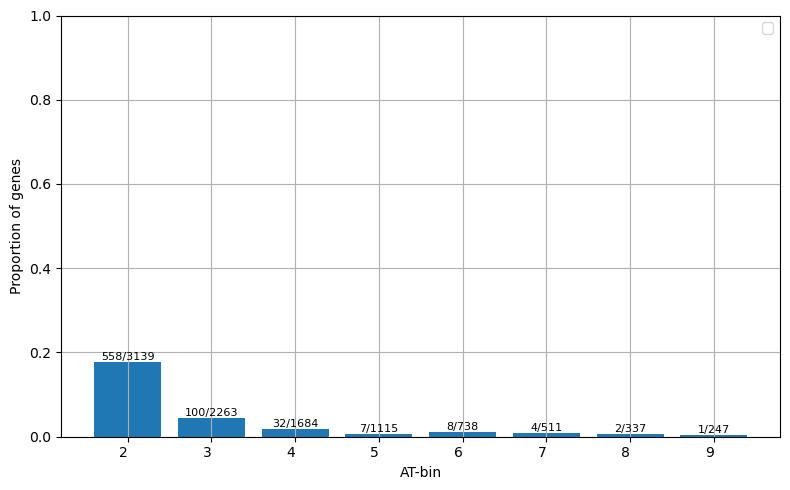

In [278]:
af.plot_hits_bar(AT_bin_genes_psc_meso, hits_by_bin)


In [279]:
result_table_psc_meso_hits = result_table_psc_meso[result_table_psc_meso["GeneID"].isin(hits_only_genes)]

In [280]:
len(hits_only_genes)

712

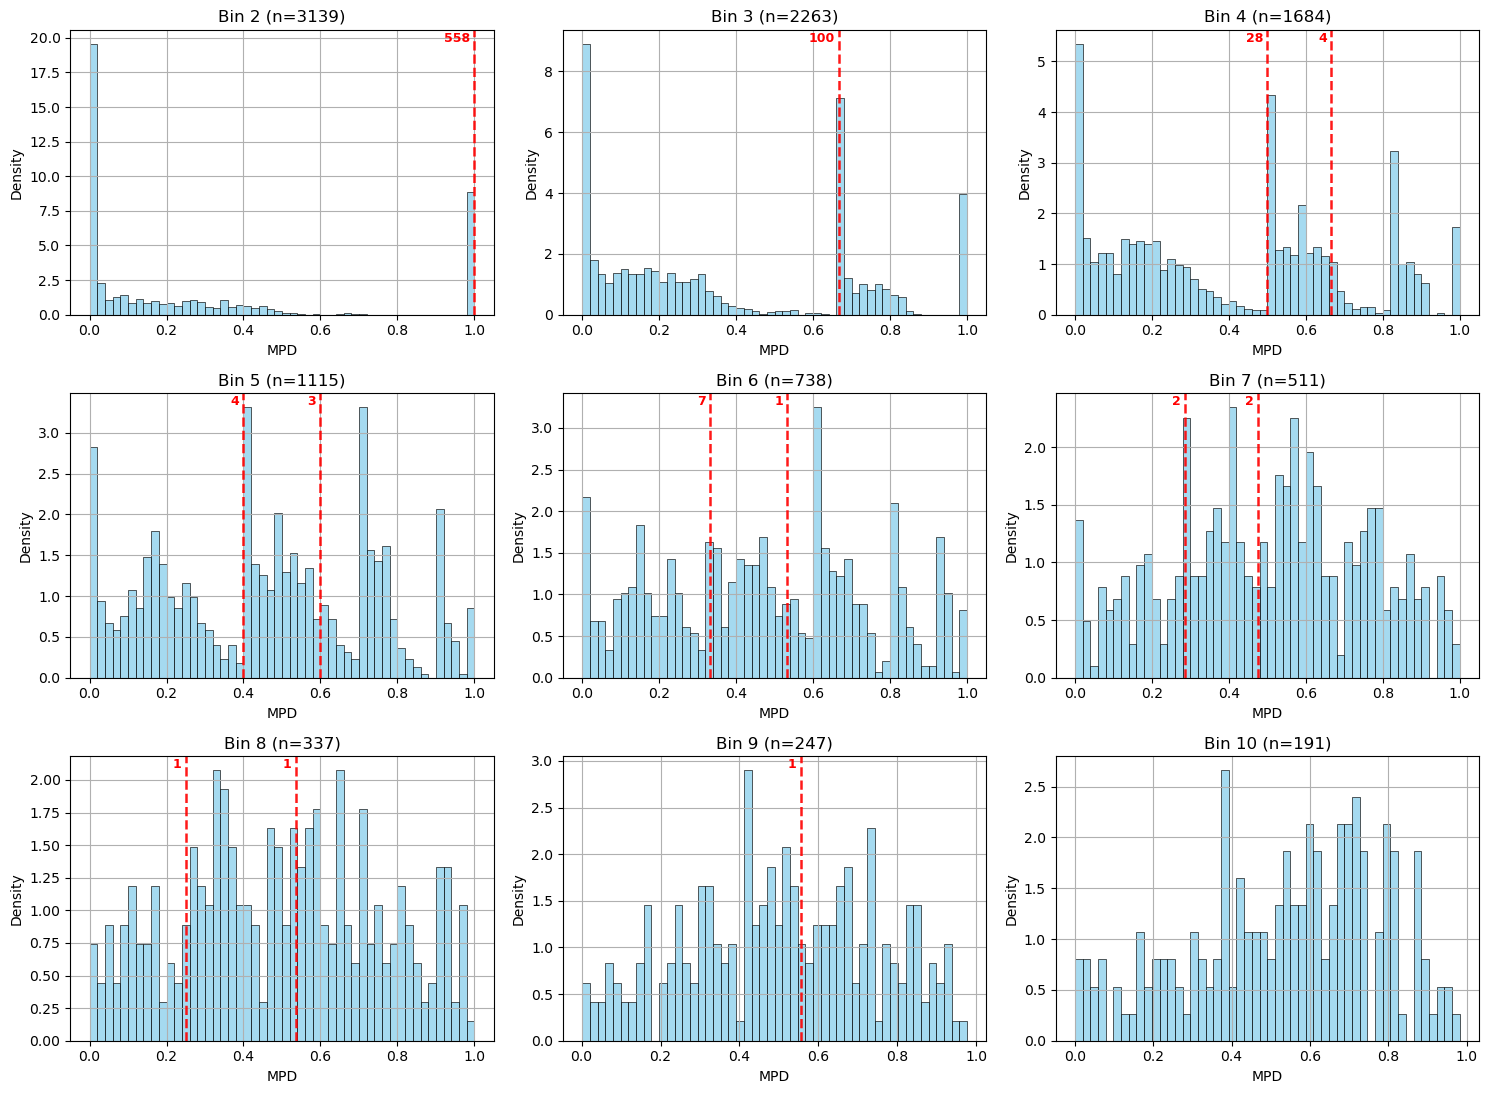

In [281]:
af.plot_distributions_from_result(result_table=result_table_psc_meso, metric="MPD", max_bins_to_plot=9, logscale=False, highlight_genes=hits_only_genes)

## NMD and PC Compositon of genes with extreme dissimilarity matrices

In [282]:
# Retrieve all genes in the first 10 AT bins that have a MPD of 1
mpd1 = result_table_psc_meso[result_table_psc_meso["MPD"] == 1].sort_values("AT", ascending=False)
mpd1_filt = mpd1[mpd1["AT"] != 11]

In [283]:
tidy_expr = spice.gene_cache_to_rel_expr_df(
    gene_cache=gene_cache_psc_meso
)
# Get genes with MPD of 1 and corresponding transcripts
mpd1_tr = tidy_expr[tidy_expr["gene"].isin(mpd1_filt["GeneID"])]

In [284]:
tidy_expr

,gene,Name,txname,rel_expr_118882_S9_PSC,rel_expr_118884_S10_PSC,rel_expr_118886_S11_PSC,rel_expr_118888_S12_mesoderm,rel_expr_118890_S13_mesoderm,rel_expr_118892_S14_mesoderm
0,ENSG00000114026,ENSP00000305584,ENST00000302003,0.082604,0.110245,0.109152,0.091047,0.118604,0.086710
1,ENSG00000114026,ENSP00000342851,ENST00000344629,0.197495,0.229931,0.190587,0.376295,0.382503,0.587336
2,ENSG00000114026,ENSP00000306561,ENST00000302036,0.149886,0.014987,0.124016,0.177845,0.140150,0.054820
3,ENSG00000114026,ENSP00000345520,ENST00000339511,0.288140,0.357948,0.280706,0.189104,0.244520,0.160798
4,ENSG00000114026,ENSP00000344899,ENST00000352937,0.101420,0.170424,0.125976,0.045013,0.050437,0.059771
...,...,...,...,...,...,...,...,...,...
46678,ENSG00000062282,ENSP00000228027,ENST00000228027,0.887890,1.000000,0.947855,0.896536,0.840342,0.957649
46679,ENSG00000141568,ENST00000473637,ENST00000473637,0.073626,0.088214,0.048739,0.225882,0.130061,0.038023
46680,ENSG00000141568,ENSP00000335677,ENST00000335255,0.914033,0.898467,0.937126,0.745654,0.825888,0.958587
46681,ENSG00000141568,ENSP00000432663,ENST00000526383,0.000000,0.000000,0.000000,0.022480,0.034441,0.000000


In [285]:
# Map genes to AT and add columns in mpd1_tr
gene_at_map = dict(zip(mpd1["GeneID"], mpd1["AT"]))
mpd1_tr["AT"] = mpd1_tr["gene"].map(gene_at_map)

/tmp/ipykernel_1646585/2091932854.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mpd1_tr["AT"] = mpd1_tr["gene"].map(gene_at_map)


In [286]:
mpd1_tr

,gene,Name,txname,rel_expr_118882_S9_PSC,rel_expr_118884_S10_PSC,rel_expr_118886_S11_PSC,rel_expr_118888_S12_mesoderm,rel_expr_118890_S13_mesoderm,rel_expr_118892_S14_mesoderm,AT
9,ENSG00000161981,ENSP00000293861,ENST00000293861,0.983667,0.985113,0.985541,0.992830,0.998355,0.996637,2
10,ENSG00000161981,ENST00000397876,ENST00000397876,0.016333,0.014887,0.014459,0.007170,0.001645,0.003363,2
72,ENSG00000152433,ENST00000595335,ENST00000595335,0.142942,0.118981,0.212420,0.159200,0.177322,0.126948,2
73,ENSG00000152433,ENSP00000282282,ENST00000282282,0.857058,0.881019,0.787580,0.840800,0.822678,0.873052,2
105,ENSG00000132677,ENSP00000441197,ENST00000537040,0.653600,0.500344,0.000000,0.484845,0.000000,0.789238,2
...,...,...,...,...,...,...,...,...,...,...
46577,ENSG00000152484,ENSP00000282344,ENST00000282344,0.998206,0.992486,0.995104,0.999025,0.997346,0.992259,2
46578,ENSG00000152484,ENSP00000478929,ENST00000620323,0.001794,0.007514,0.004896,0.000975,0.002655,0.007741,2
46618,ENSG00000183054,ENSP00000387779,ENST00000437167,0.159403,0.000000,0.000000,0.000000,0.000000,0.869744,3
46619,ENSG00000183054,ENST00000696447,ENST00000696447,0.799466,1.000000,0.928583,0.960538,0.989105,0.130256,3


In [287]:
atdict = defaultdict(list)
for g, data in mpd1_tr.groupby("gene"):
    # Count how many transcripts are NMD and pc
    p_count = 0
    nmd_count = 0
    tr = list(data["Name"])
    at = list(data["AT"])[0]
    for tx in tr:
        if "ENST" in tx:
            nmd_count += 1
        else:
            p_count += 1
    atdict[at].append((g, p_count, nmd_count))
atdict = dict(atdict)


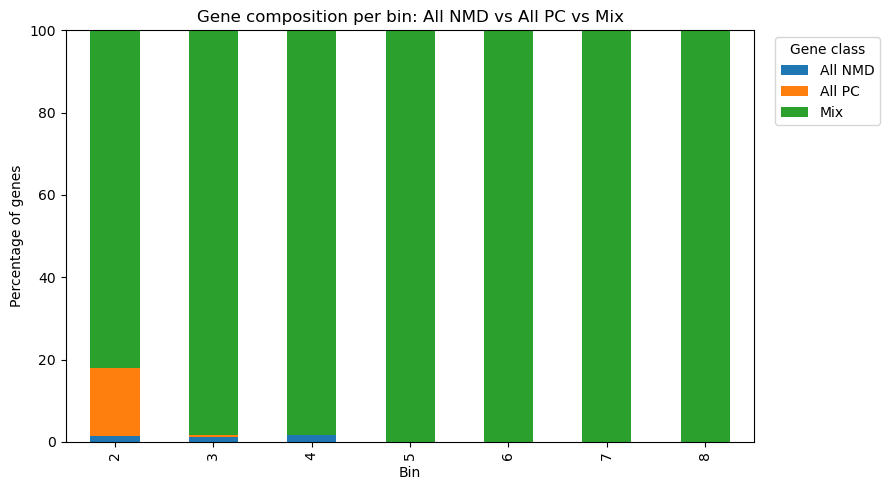

In [288]:
rows = []
for bin_id, gene_list in atdict.items():
    for gene_id, pc, nmd in gene_list:
        if pc == 0 and nmd > 0:
            category = "All NMD"
        elif pc > 0 and nmd == 0:
            category = "All PC"
        else:
            category = "Mix"

        rows.append({
            "bin": bin_id,
            "gene": gene_id,
            "pc": pc,
            "nmd": nmd,
            "category": category
        })

df = pd.DataFrame(rows)

# Count genes per category per bin
counts = (
    df.groupby(["bin", "category"])["gene"]
      .nunique()
      .unstack(fill_value=0)
      .sort_index()
)
counts = counts.reindex(columns=["All NMD", "All PC", "Mix"], fill_value=0)

# Convert to percentages within each bin
pct = counts.div(counts.sum(axis=1), axis=0) * 100

# Plot stacked bar percentages
ax = pct.plot(kind="bar", stacked=True, figsize=(9, 5))
ax.set_xlabel("Bin")
ax.set_ylabel("Percentage of genes")
ax.set_title("Gene composition per bin: All NMD vs All PC vs Mix")
ax.set_ylim(0, 100)
plt.legend(title="Gene class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [289]:
counts

category,All NMD,All PC,Mix
bin,,,
2,8,92,458
3,2,1,177
4,1,0,57
5,0,0,19
6,0,0,12
7,0,0,3
8,0,0,1


In [290]:
pct

category,All NMD,All PC,Mix
bin,,,
2,1.433692,16.487455,82.078853
3,1.111111,0.555556,98.333333
4,1.724138,0.000000,98.275862
5,0.000000,0.000000,100.000000
6,0.000000,0.000000,100.000000
7,0.000000,0.000000,100.000000
8,0.000000,0.000000,100.000000


In [291]:
for gr, df in mpd1_tr[mpd1_tr["AT"] == 6].groupby("gene"):
    nmd_count = 0
    pc_count = 0
    txs = df["Name"]
    for tx in txs:
        if "ENST" in tx:
            nmd_count += 1
        elif "ENSP" in tx:
            pc_count += 1
    print(f"Gene: {gr}; NMD count: {nmd_count}; PC count: {pc_count}")

Gene: ENSG00000070269; NMD count: 4; PC count: 2
Gene: ENSG00000088035; NMD count: 5; PC count: 1
Gene: ENSG00000104365; NMD count: 5; PC count: 1
Gene: ENSG00000111203; NMD count: 4; PC count: 2
Gene: ENSG00000111450; NMD count: 5; PC count: 1
Gene: ENSG00000118600; NMD count: 5; PC count: 1
Gene: ENSG00000135953; NMD count: 5; PC count: 1
Gene: ENSG00000137504; NMD count: 5; PC count: 1
Gene: ENSG00000166946; NMD count: 5; PC count: 1
Gene: ENSG00000168002; NMD count: 4; PC count: 2
Gene: ENSG00000169016; NMD count: 5; PC count: 1
Gene: ENSG00000173559; NMD count: 4; PC count: 2


In [292]:
for gr, df in mpd1_tr[mpd1_tr["AT"] == 7].groupby("gene"):
    nmd_count = 0
    pc_count = 0
    txs = df["Name"]
    for tx in txs:
        if "ENST" in tx:
            nmd_count += 1
        elif "ENSP" in tx:
            pc_count += 1
    print(f"Gene: {gr}; NMD count: {nmd_count}; PC count: {pc_count}")

Gene: ENSG00000152457; NMD count: 6; PC count: 1
Gene: ENSG00000165688; NMD count: 6; PC count: 1
Gene: ENSG00000177084; NMD count: 6; PC count: 1


In [293]:
for gr, df in mpd1_tr[mpd1_tr["AT"] == 8].groupby("gene"):
    nmd_count = 0
    pc_count = 0
    txs = df["Name"]
    for tx in txs:
        if "ENST" in tx:
            nmd_count += 1
        elif "ENSP" in tx:
            pc_count += 1
    print(f"Gene: {gr}; NMD count: {nmd_count}; PC count: {pc_count}")

Gene: ENSG00000166012; NMD count: 7; PC count: 1


# Calculate additional synthetic RMSD values

In [294]:
# Returns all gene-level null distributions as well as mixed nulls for each AT bin
pooled_by_AT_psc_meso, pooled_by_gene_psc_meso, summary_dict_psc_meso = spice.build_AT_reference_dist(gene_cache_psc_meso)


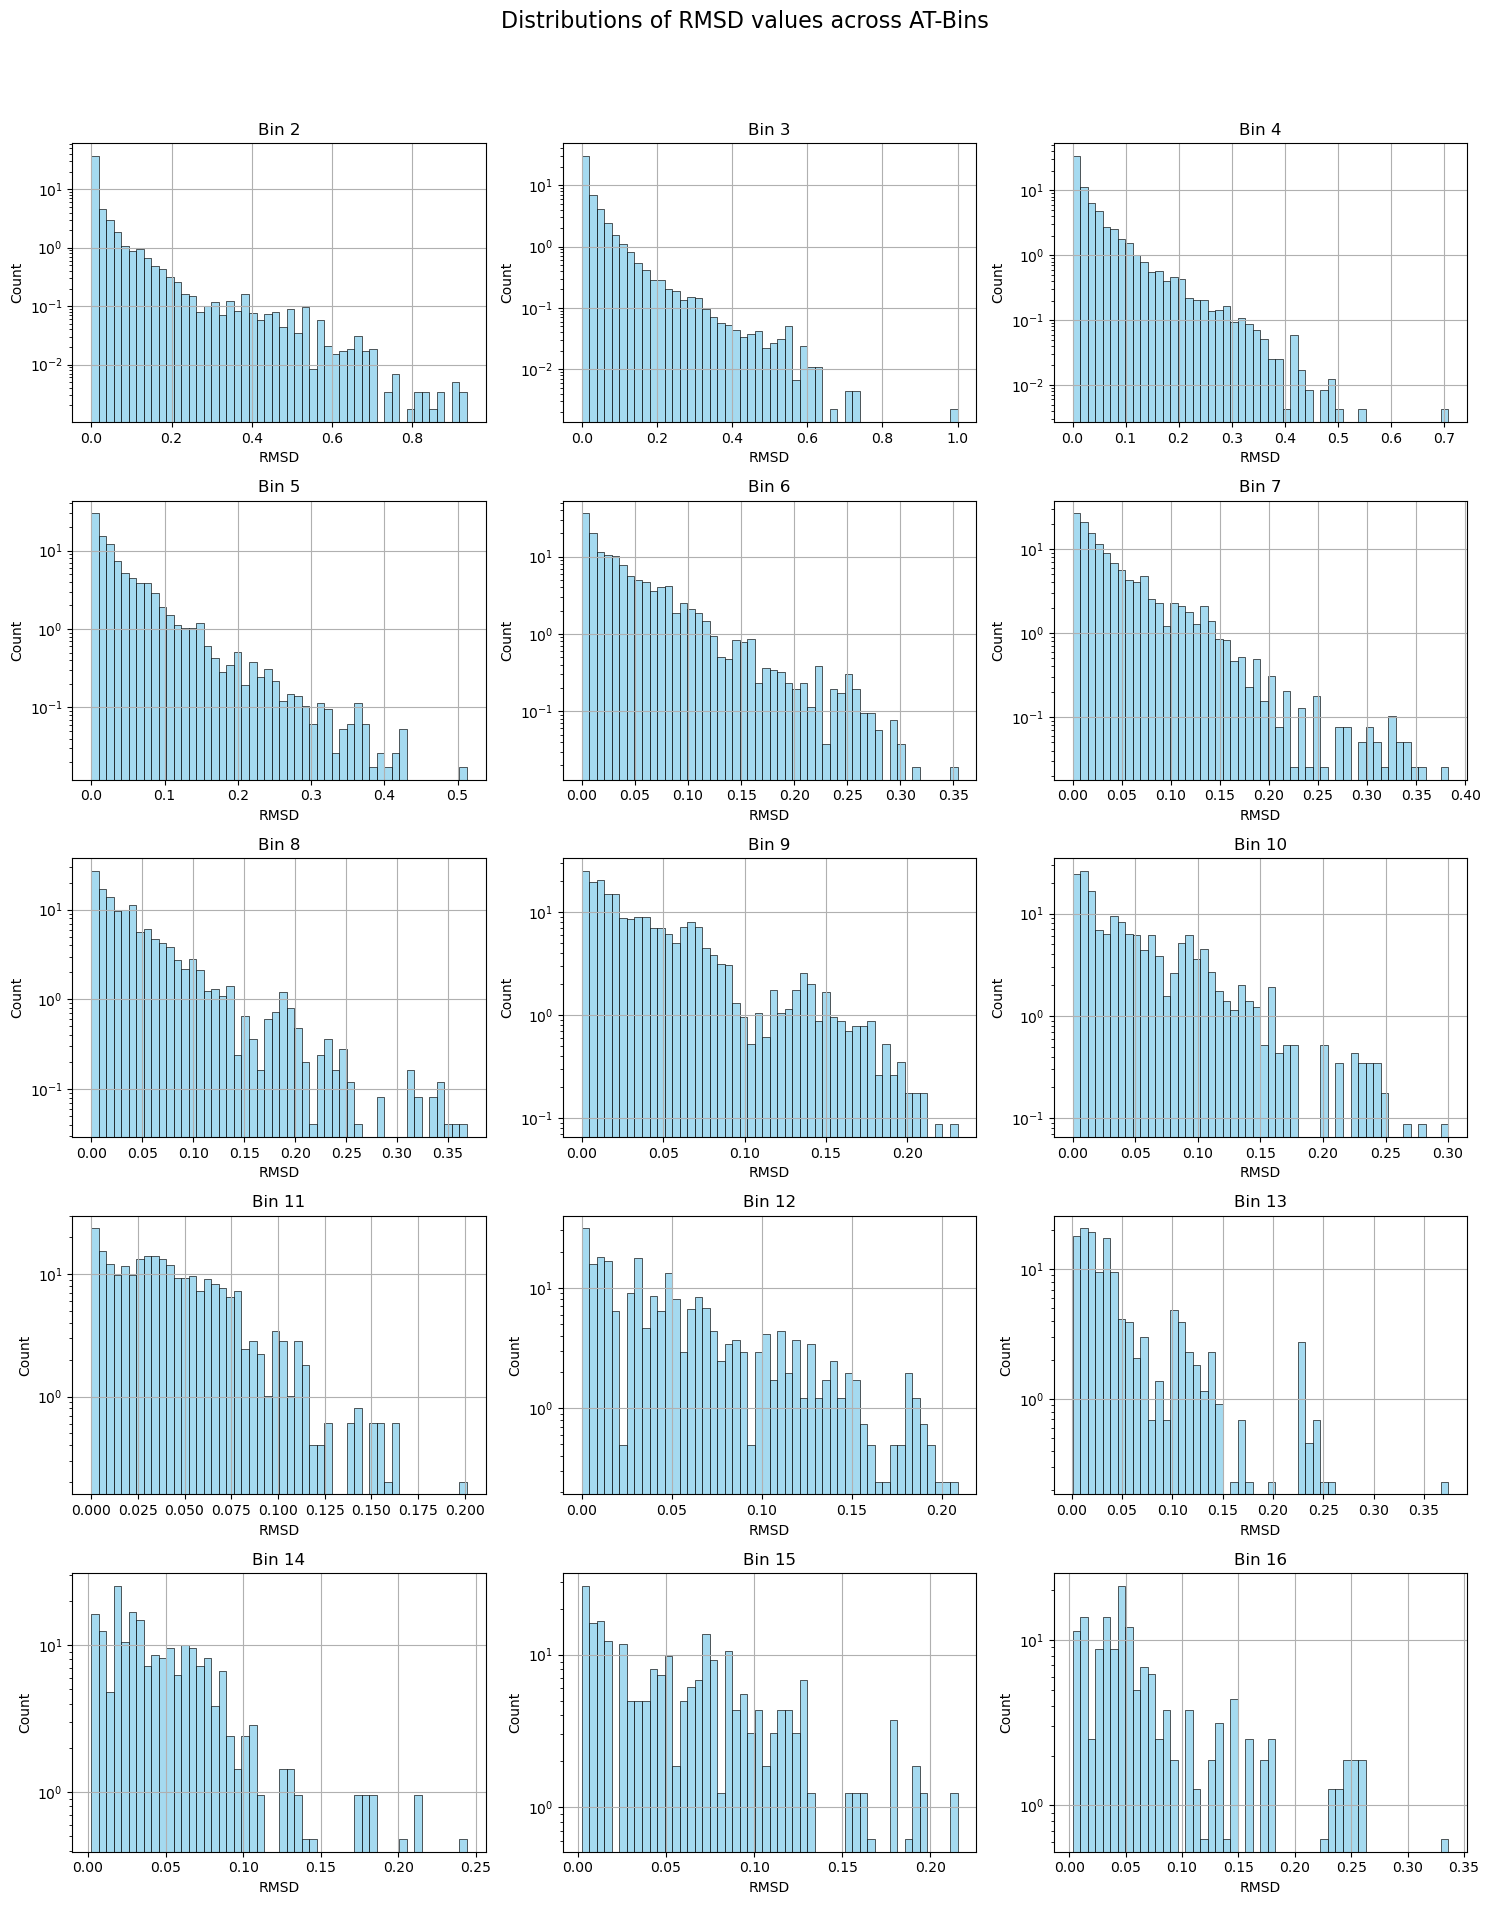

In [295]:
af.plot_distributions_per_bin(summary_dict_psc_meso, logscale=True, max_bins_to_plot=15)

In [296]:
pooled_by_AT_meso_cardmeso, pooled_by_gene_meso_cardmeso, summary_dict_meso_cardmeso = spice.build_AT_reference_dist(gene_cache_meso_cardmeso)


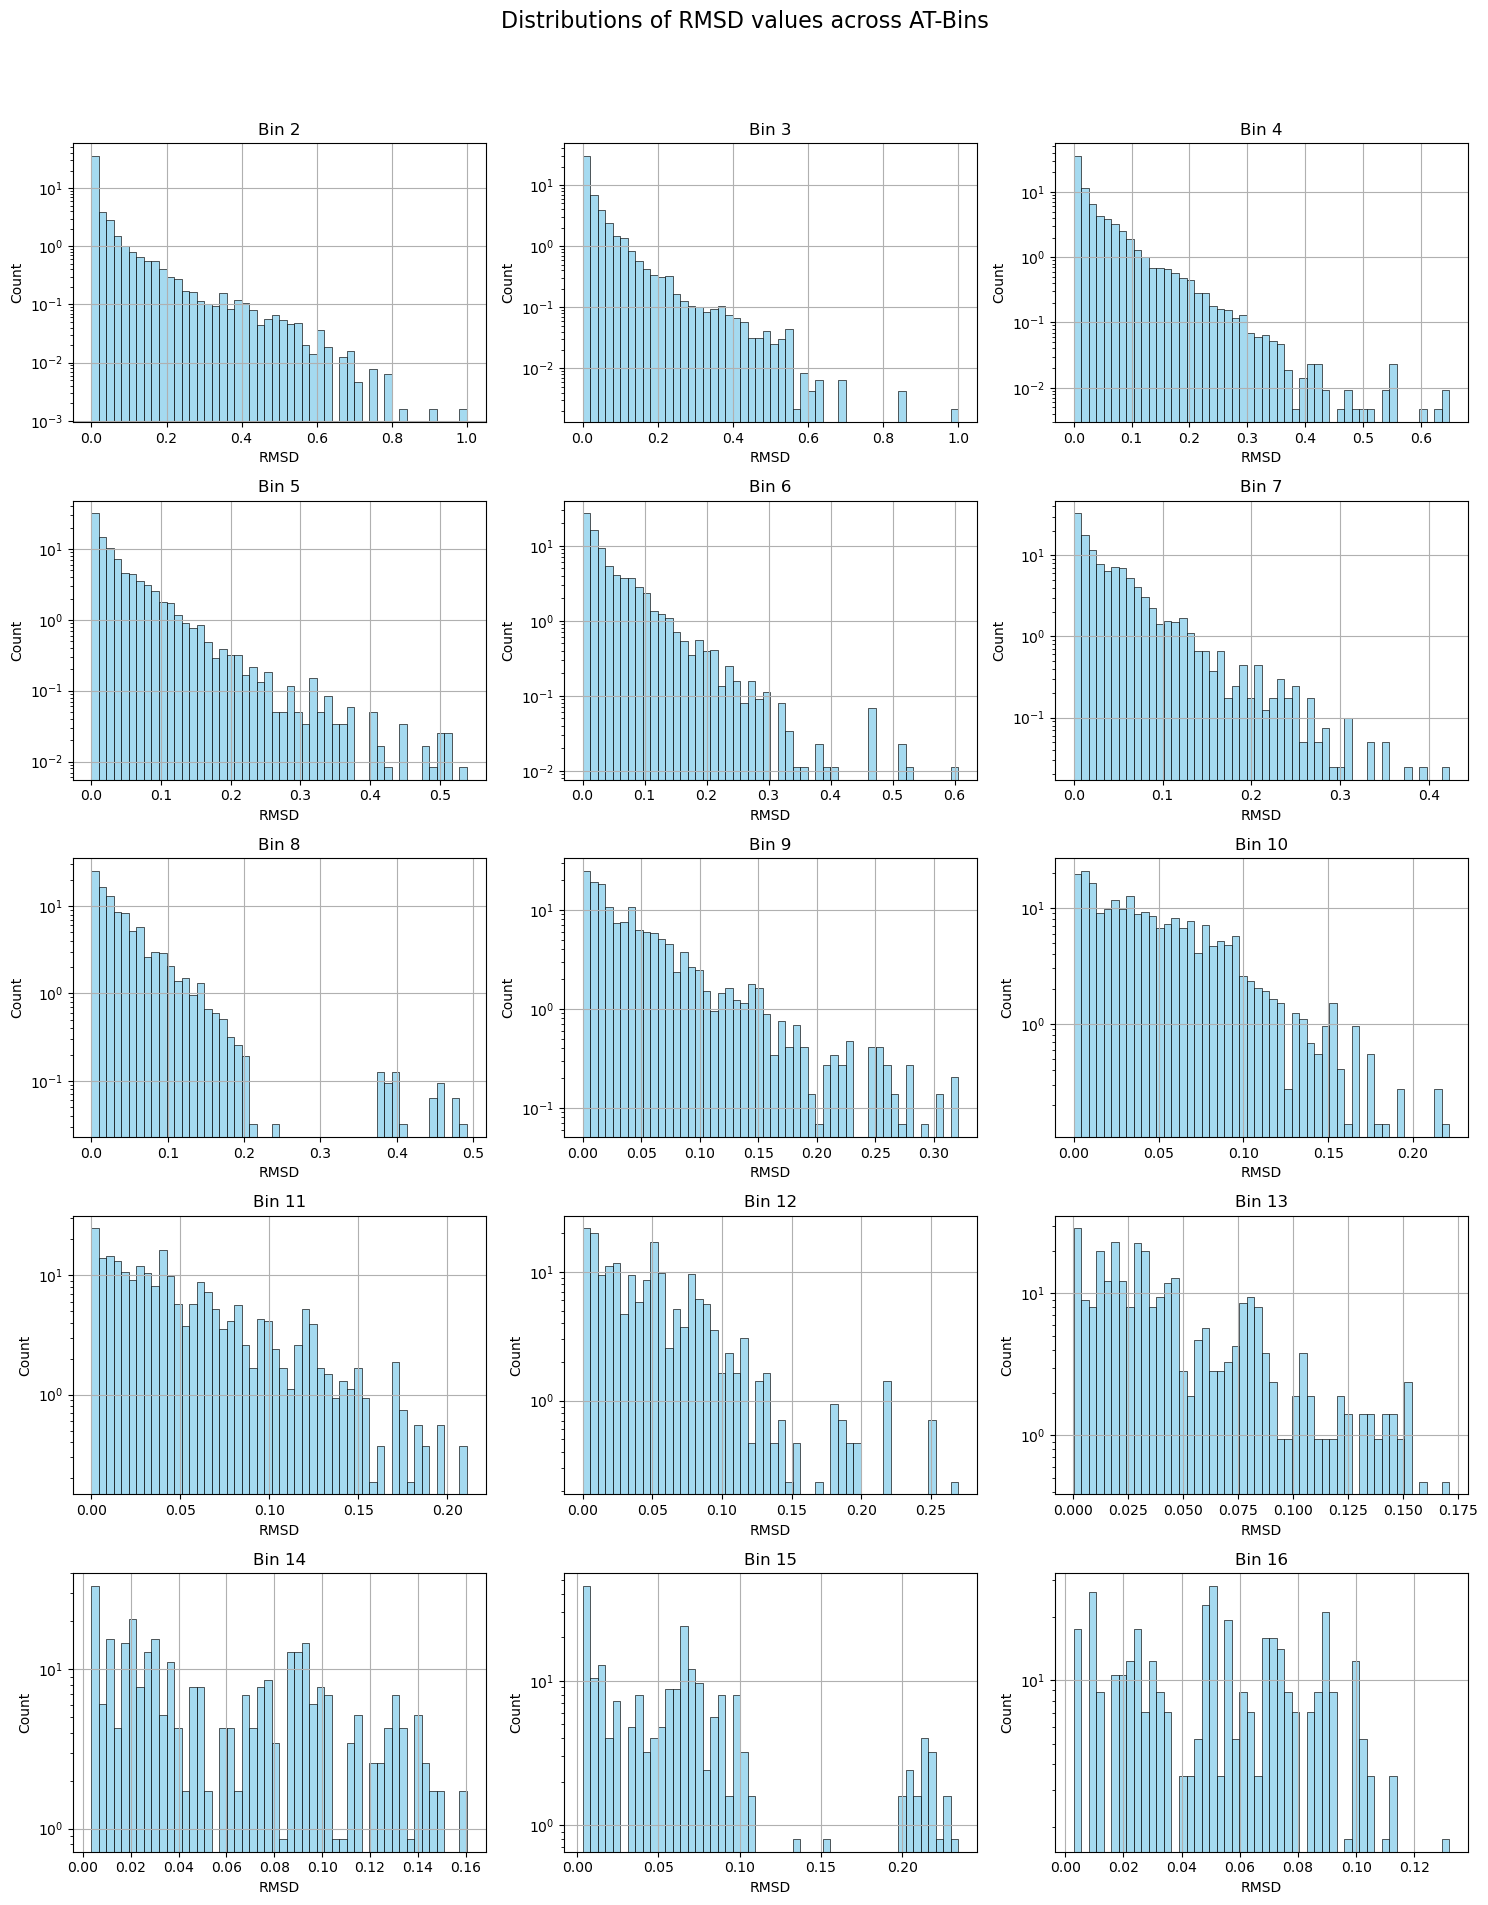

In [297]:
af.plot_distributions_per_bin(summary_dict_meso_cardmeso, logscale=True, max_bins_to_plot=15)

In [298]:
pooled_by_AT_cardmeso_cm, pooled_by_gene_cardmeso_cm, summary_dict_cardmeso_cm = spice.build_AT_reference_dist(gene_cache_cardmeso_cm)

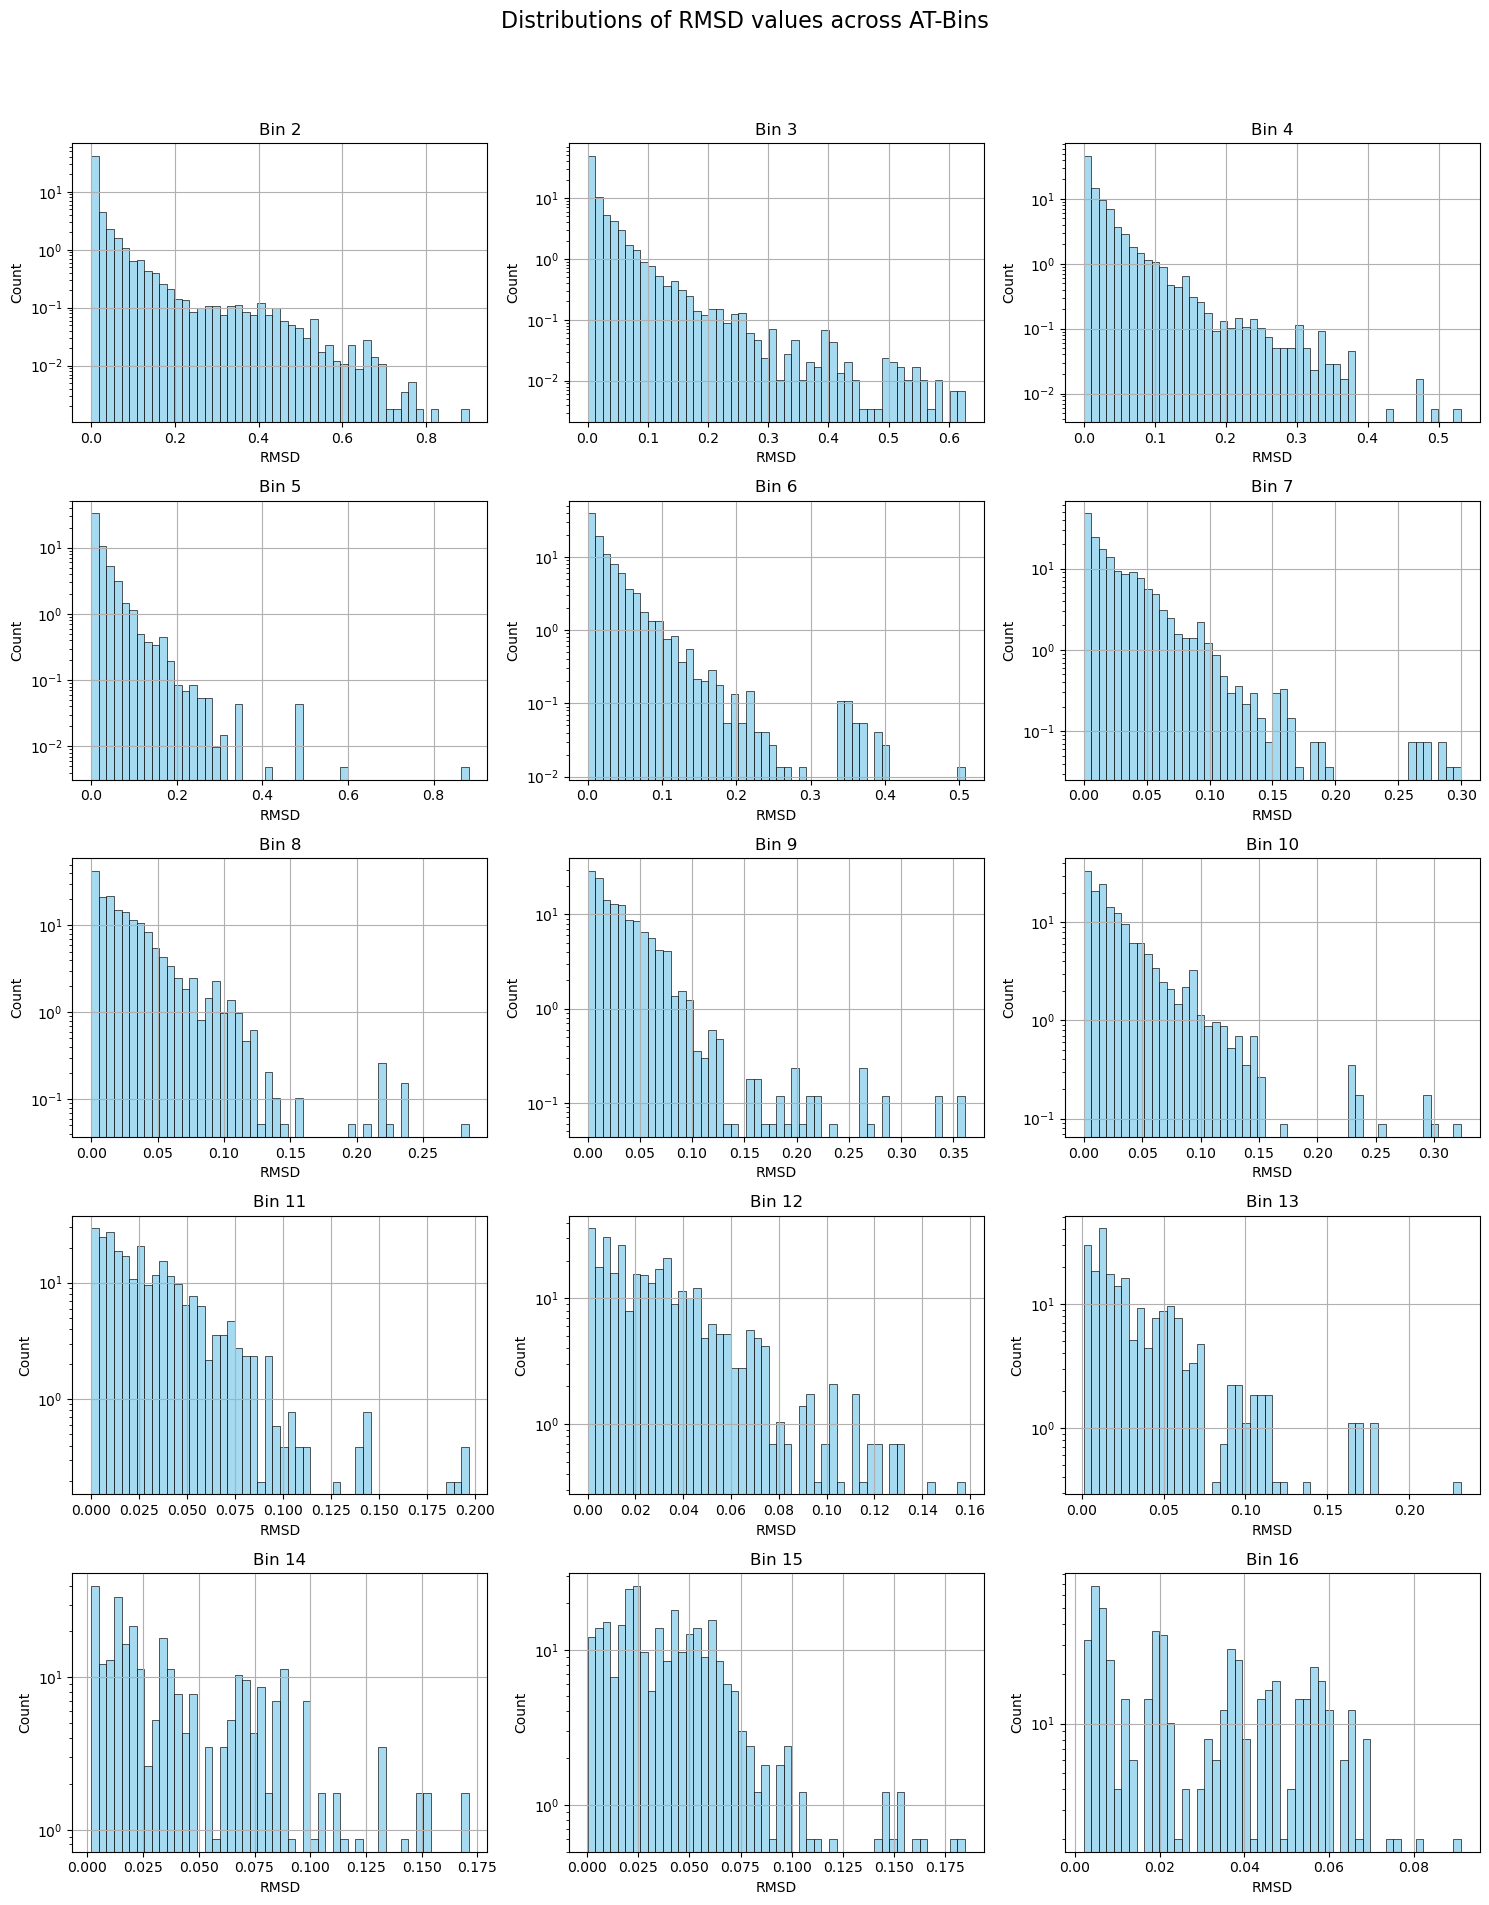

In [299]:
af.plot_distributions_per_bin(summary_dict_cardmeso_cm, logscale=True, max_bins_to_plot=15)

In [300]:
info_df_psc_meso, info_psc_meso = af.ref_dist_summary(summary_dict=summary_dict_psc_meso,
                                                      return_df=True)
info_df_meso_cardmeso, info_meso_cardmeso = af.ref_dist_summary(summary_dict=summary_dict_meso_cardmeso,
                                                                return_df=True)
info_df_cardmeso_cm, info_cardmeso_cm = af.ref_dist_summary(summary_dict=summary_dict_cardmeso_cm,
                                                            return_df=True)

In [301]:
merged = pd.merge(info_df_psc_meso, info_df_meso_cardmeso, how="outer", on="AT", suffixes=["_psc_meso", "meso_cardmeso"])
all_m = pd.merge(merged, info_df_cardmeso_cm, how="outer", on="AT", suffixes=["", "cardmeso_cm"])
all_m

,AT,num_genes_psc_meso,num_values_psc_meso,num_u_values_psc_meso,num_genesmeso_cardmeso,num_valuesmeso_cardmeso,num_u_valuesmeso_cardmeso,num_genes,num_values,num_u_values
0,2,3139.0,62780.0,25549.0,3180.0,63600.0,26232.0,3167.0,63340.0,27184.0
1,3,2263.0,45260.0,25036.0,2363.0,47260.0,26461.0,2368.0,47360.0,26588.0
2,4,1684.0,33680.0,19913.0,1655.0,33100.0,19983.0,1656.0,33120.0,19898.0
3,5,1115.0,22300.0,13566.0,1102.0,22040.0,13402.0,1158.0,23160.0,14092.0
4,6,738.0,14760.0,9047.0,731.0,14620.0,9070.0,725.0,14500.0,8887.0
5,7,511.0,10220.0,6242.0,477.0,9540.0,5978.0,458.0,9160.0,5690.0
6,8,337.0,6740.0,4128.0,319.0,6380.0,3931.0,341.0,6820.0,4211.0
7,9,247.0,4940.0,2987.0,229.0,4580.0,2848.0,234.0,4680.0,2927.0
8,10,191.0,3820.0,2337.0,165.0,3300.0,2064.0,177.0,3540.0,2169.0
9,11,123.0,2460.0,1512.0,127.0,2540.0,1563.0,130.0,2600.0,1637.0


In [302]:
all_m[['AT', 'PSC vs. mesoderm', 'Mesoderm vs. cardiac mesoderm','Cardiac mesoderm vs. CM']] = all_m[['AT', 'num_genes_psc_meso', 'num_genesmeso_cardmeso','num_genes']]
all_m_filt = all_m[['AT', 'PSC vs. mesoderm', 'Mesoderm vs. cardiac mesoderm','Cardiac mesoderm vs. CM']]
all_m_filt

,AT,PSC vs. mesoderm,Mesoderm vs. cardiac mesoderm,Cardiac mesoderm vs. CM
0,2,3139.0,3180.0,3167.0
1,3,2263.0,2363.0,2368.0
2,4,1684.0,1655.0,1656.0
3,5,1115.0,1102.0,1158.0
4,6,738.0,731.0,725.0
5,7,511.0,477.0,458.0
6,8,337.0,319.0,341.0
7,9,247.0,229.0,234.0
8,10,191.0,165.0,177.0
9,11,123.0,127.0,130.0


In [303]:
# def fmt_int(x):
#     return "" if pd.isna(x) else f"{x:.0f}"

# all_m_filt.to_latex(
#     "/home/katharina/msc/figures/AT_numg_tbl.tex",
#     formatters={"AT": fmt_int, "PSC vs. mesoderm": fmt_int, "Mesoderm vs. cardiac mesoderm": fmt_int, "Cardiac mesoderm vs. CM": fmt_int},
#     index=False
# )

## Merge Bins

In [304]:
bins_to_pool_psc_meso = spice.define_bins_to_merge(summary_dict=summary_dict_psc_meso, num_g=200)
sorted(bins_to_pool_psc_meso)

[10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 28,
 31,
 32,
 43]

In [305]:
bins_to_pool_meso_cardmeso = spice.define_bins_to_merge(summary_dict=summary_dict_meso_cardmeso, num_g=200)
sorted(bins_to_pool_meso_cardmeso)

[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 27, 29, 30, 31, 39]

In [306]:
bins_to_pool_cardmeso_cm = spice.define_bins_to_merge(summary_dict=summary_dict_cardmeso_cm, num_g=200)
sorted(bins_to_pool_cardmeso_cm)

[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 29, 30, 40]

**Comparison: PSC vs. mesoderm**

In [307]:
summary_dict_psc_meso_mod, pooled_by_AT_psc_meso_mod, result_table_psc_meso_mod = spice.merge_bins(bins_to_pool=bins_to_pool_psc_meso,
                                                                                                summary_dict=summary_dict_psc_meso,
                                                                                                pooled_by_AT=pooled_by_AT_psc_meso,
                                                                                                result_table=result_table_psc_meso)

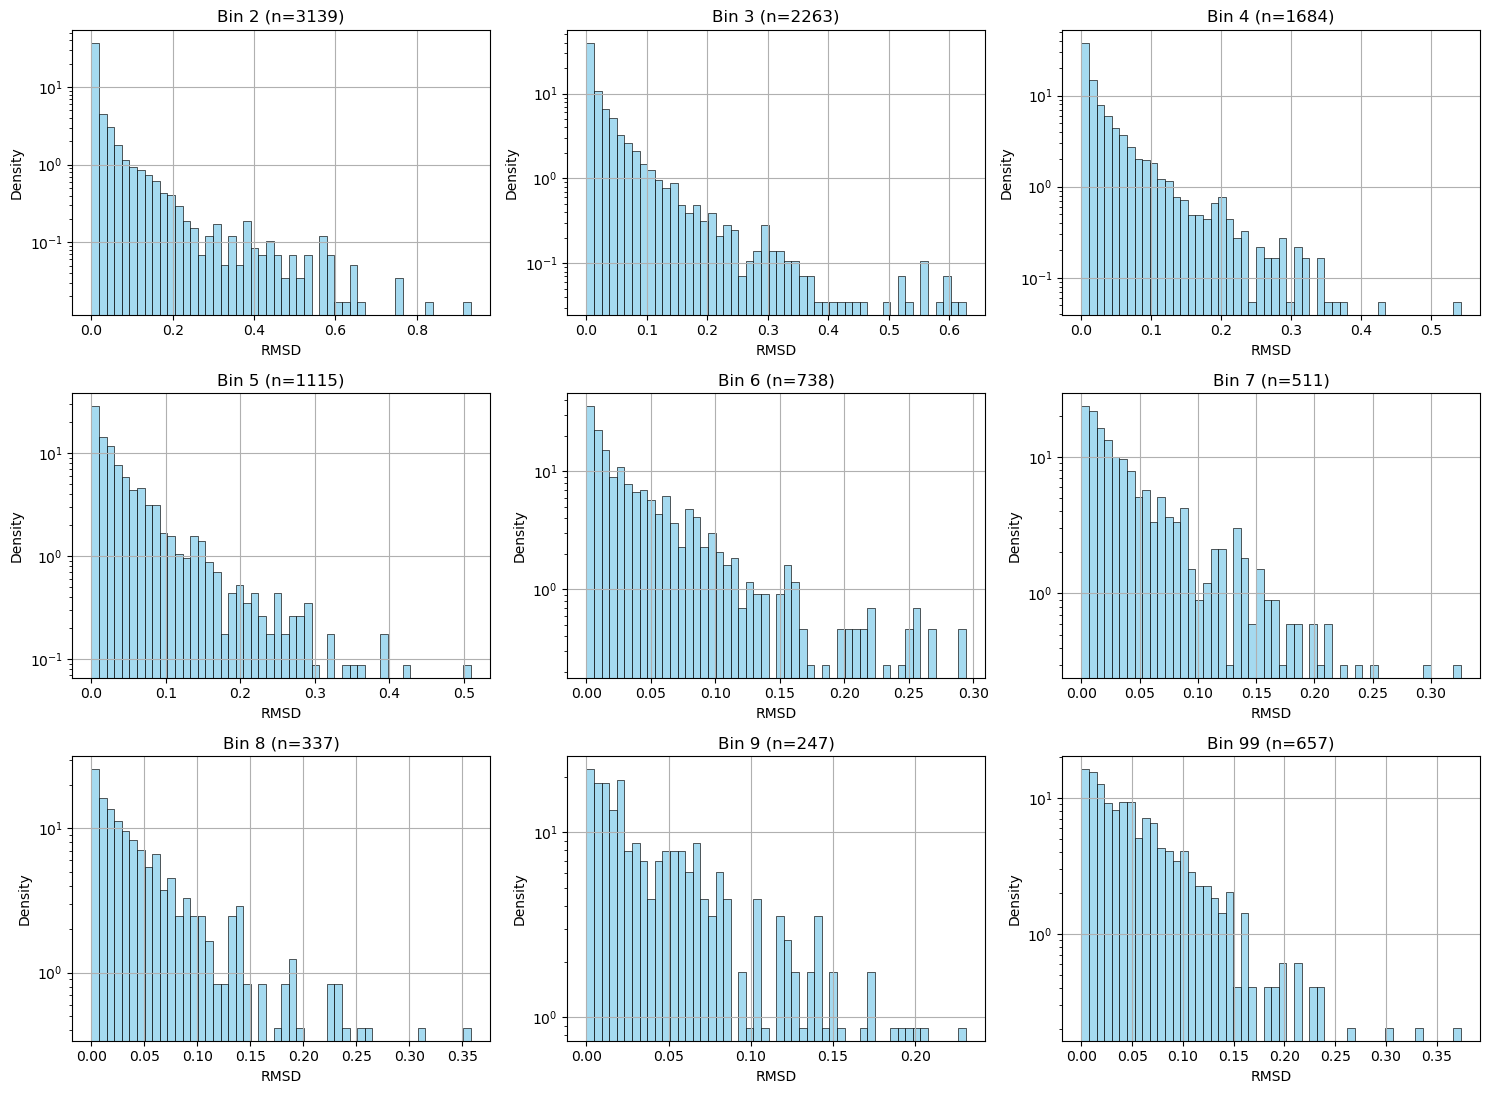

In [308]:
af.plot_distributions_from_result(result_table=result_table_psc_meso_mod, logscale=True, max_bins_to_plot=len(summary_dict_psc_meso_mod), metric="RMSD")

**Comparison: Mesoderm vs. cardmeso**

In [309]:
summary_dict_meso_cardmeso_mod, pooled_by_AT_meso_cardmeso_mod, result_table_meso_cardmeso_mod = spice.merge_bins(bins_to_pool=bins_to_pool_meso_cardmeso,
                                                                                                                  summary_dict=summary_dict_meso_cardmeso,
                                                                                                                  pooled_by_AT=pooled_by_AT_meso_cardmeso,
                                                                                                                  result_table=result_table_meso_cardmeso)

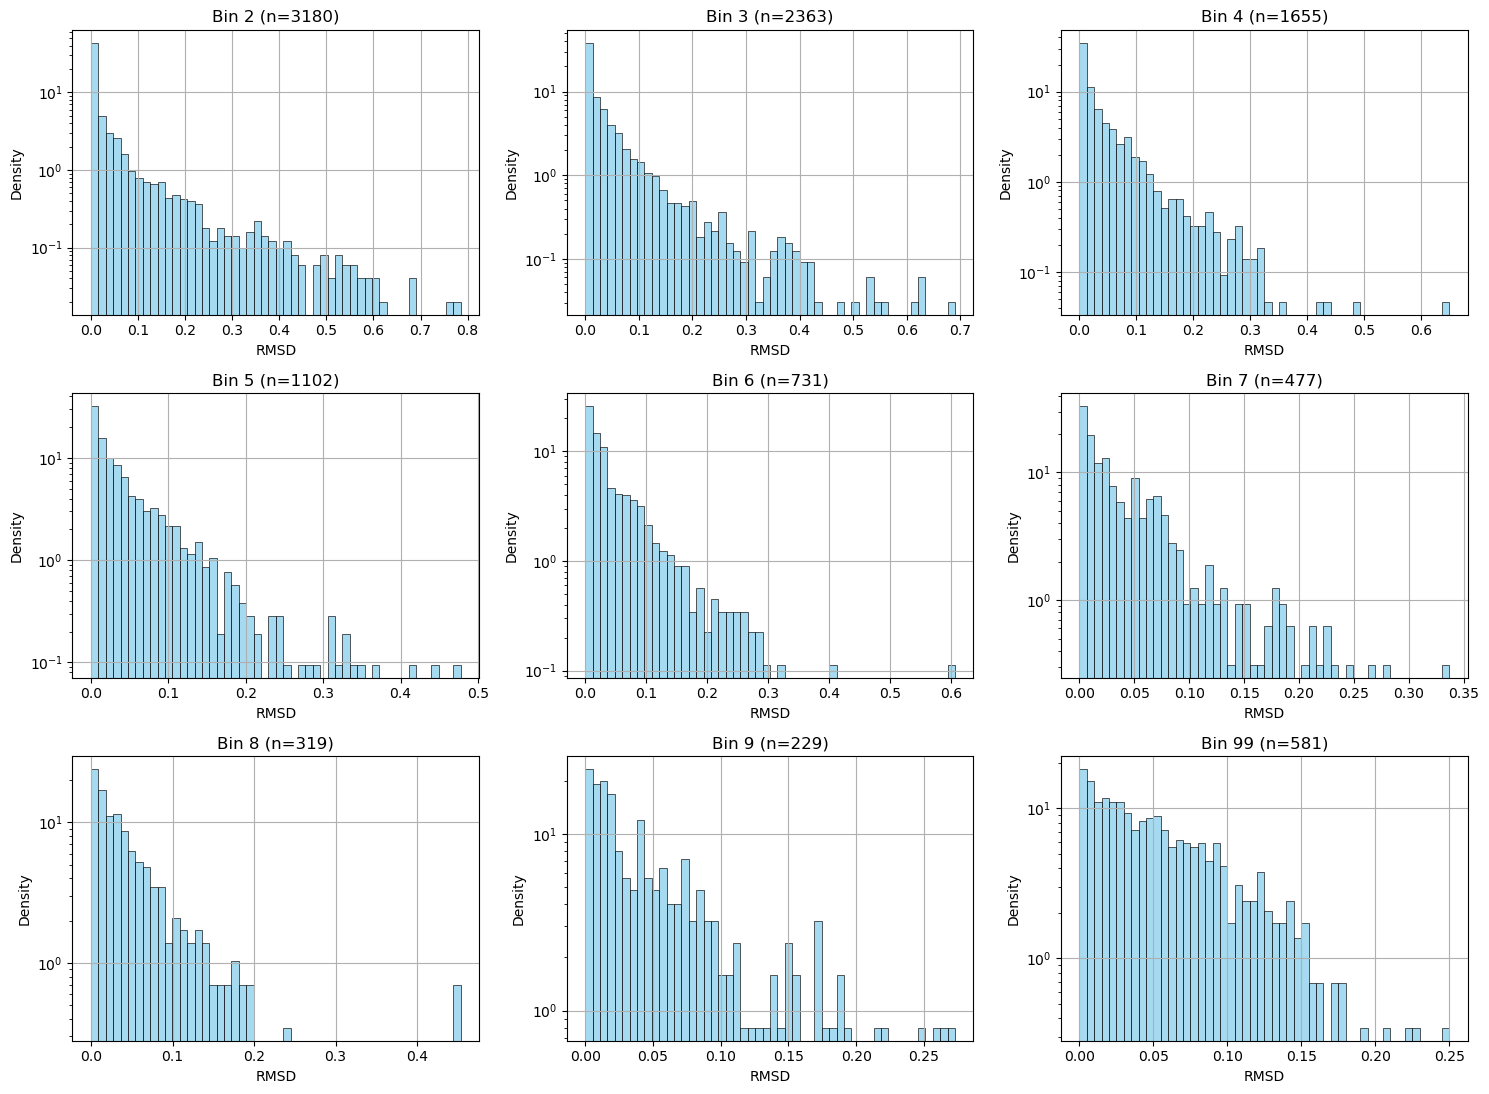

In [310]:
af.plot_distributions_from_result(result_table=result_table_meso_cardmeso_mod, logscale=True, max_bins_to_plot=len(summary_dict_meso_cardmeso_mod), metric="RMSD")

**Comparison: Cardmeso vs. CM**

In [311]:
summary_dict_cardmeso_cm_mod, pooled_by_AT_cardmeso_cm_mod, result_table_cardmeso_cm_mod = spice.merge_bins(bins_to_pool=bins_to_pool_cardmeso_cm,
                                                                                                            summary_dict=summary_dict_cardmeso_cm,
                                                                                                            pooled_by_AT=pooled_by_AT_cardmeso_cm,
                                                                                                            result_table=result_table_cardmeso_cm)

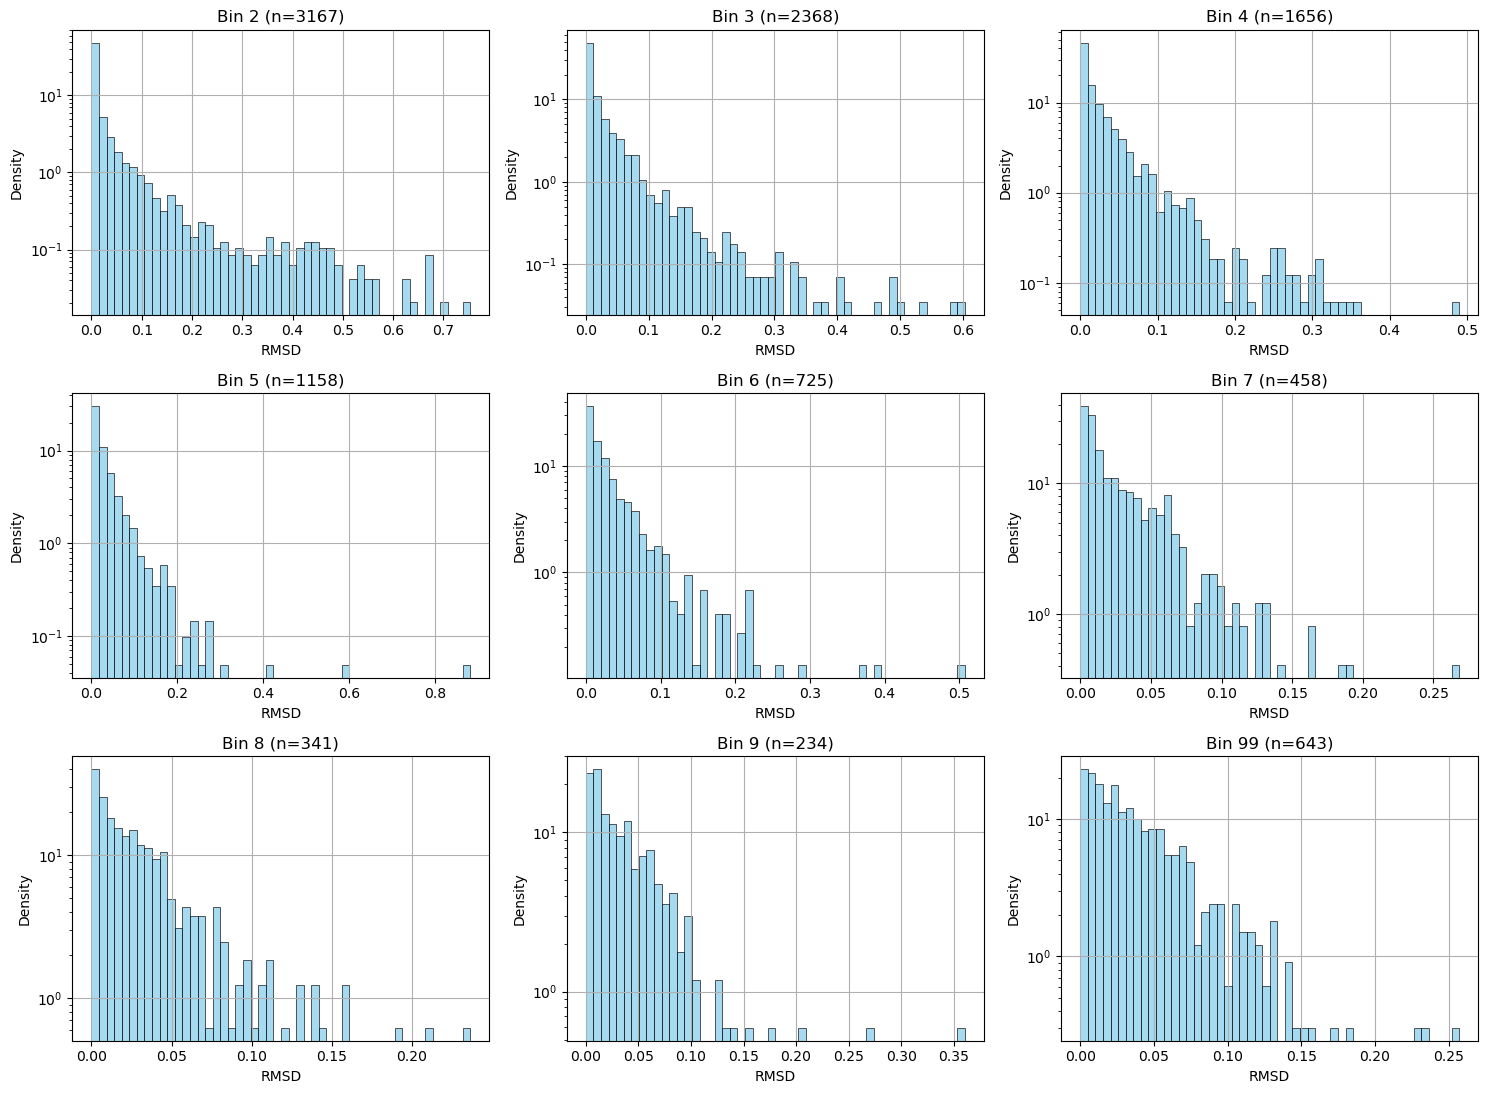

In [312]:
af.plot_distributions_from_result(result_table=result_table_cardmeso_cm_mod, logscale=True, max_bins_to_plot=len(summary_dict_cardmeso_cm_mod), metric="RMSD")

## Fit Distributions

Our empirical distributions are:

- bounded (between 0 and 1)
- asymmetric
- potentially zero inflated (heavily concentrated near zero) or truncated

Candidate families:
- Beta (Parameters $\alpha$, $\beta$, support $(0,1)$)
- Johnson SB (Support a, b, 4 parameters)
- Power-law function, scipy version allowing $(0,1)$ bound

**Comparison: PSC vs. mesoderm**

In [313]:
df_fits_psc_meso = spice.fit_distributions_scipy(pooled_by_AT_psc_meso_mod,
                                                 models=["beta","johnsonsb","powerlaw"]
)


In [314]:
winner_params_df_psc_meso = spice.winners_by_AIC(df_fits_psc_meso)
winner_params_df_psc_meso

,AT,model,AIC,params
0,2,beta,-761702.365710,"a=0.130698, b=3.56539"
1,3,beta,-309802.146875,"a=0.253497, b=6.38851"
2,4,beta,-184847.892209,"a=0.376228, b=9.58723"
3,5,beta,-104009.655938,"a=0.498172, b=10.9415"
4,6,beta,-68966.193111,"a=0.607103, b=14.9929"
5,7,beta,-45274.146502,"a=0.696093, b=15.928"
6,8,beta,-28689.198614,"a=0.735673, b=15.6015"
7,9,beta,-21041.157695,"a=0.92821, b=20.2797"
8,99,beta,-53472.329322,"a=0.895137, b=17.6732"


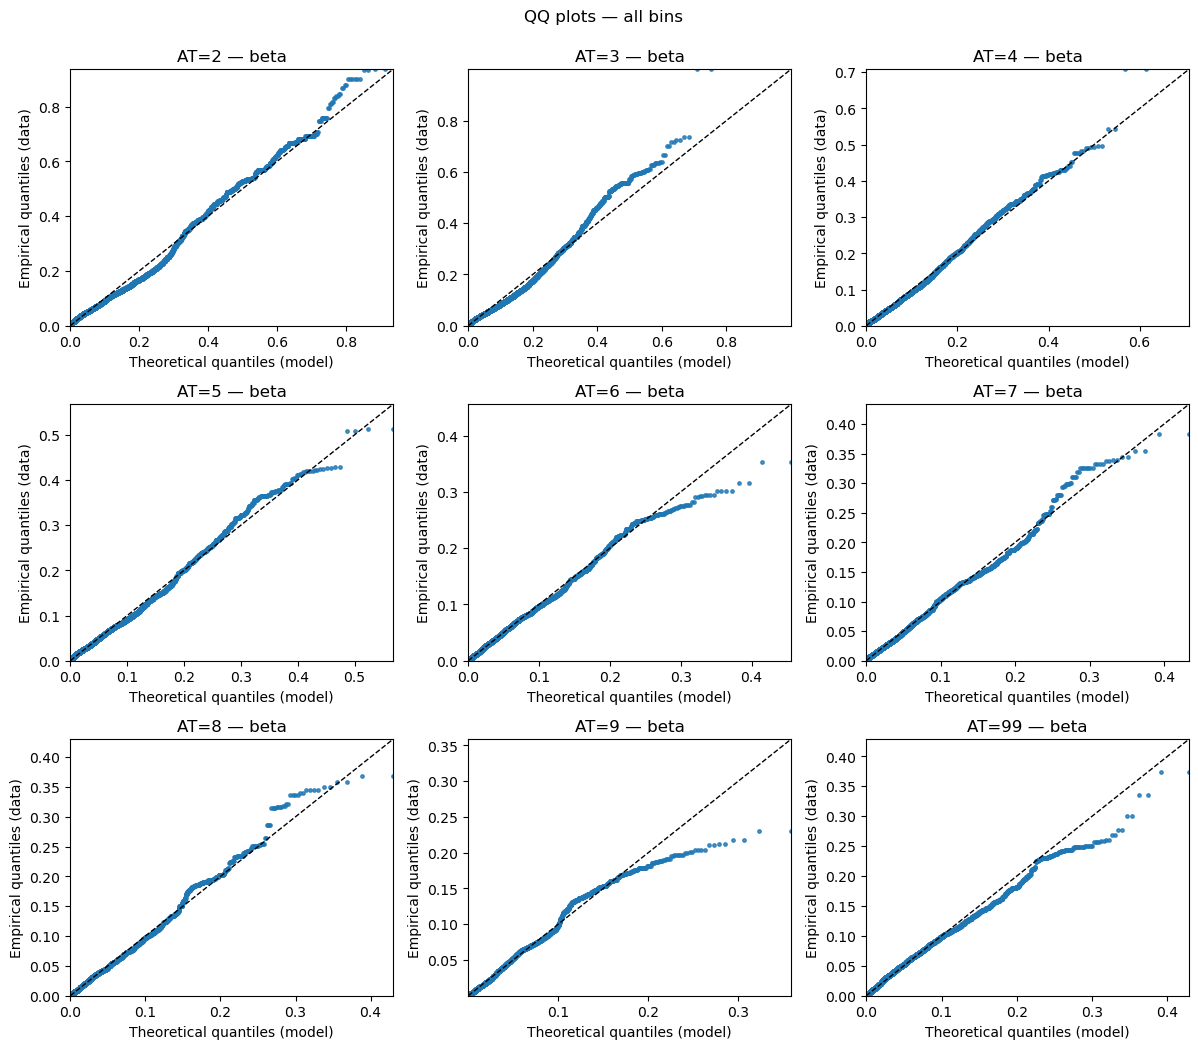

In [315]:
af.plot_all_bins_QQ(pooled_by_AT_psc_meso_mod, df_fits_psc_meso, model_choice="best", winner_by_AIC=winner_params_df_psc_meso ,ncols=3)

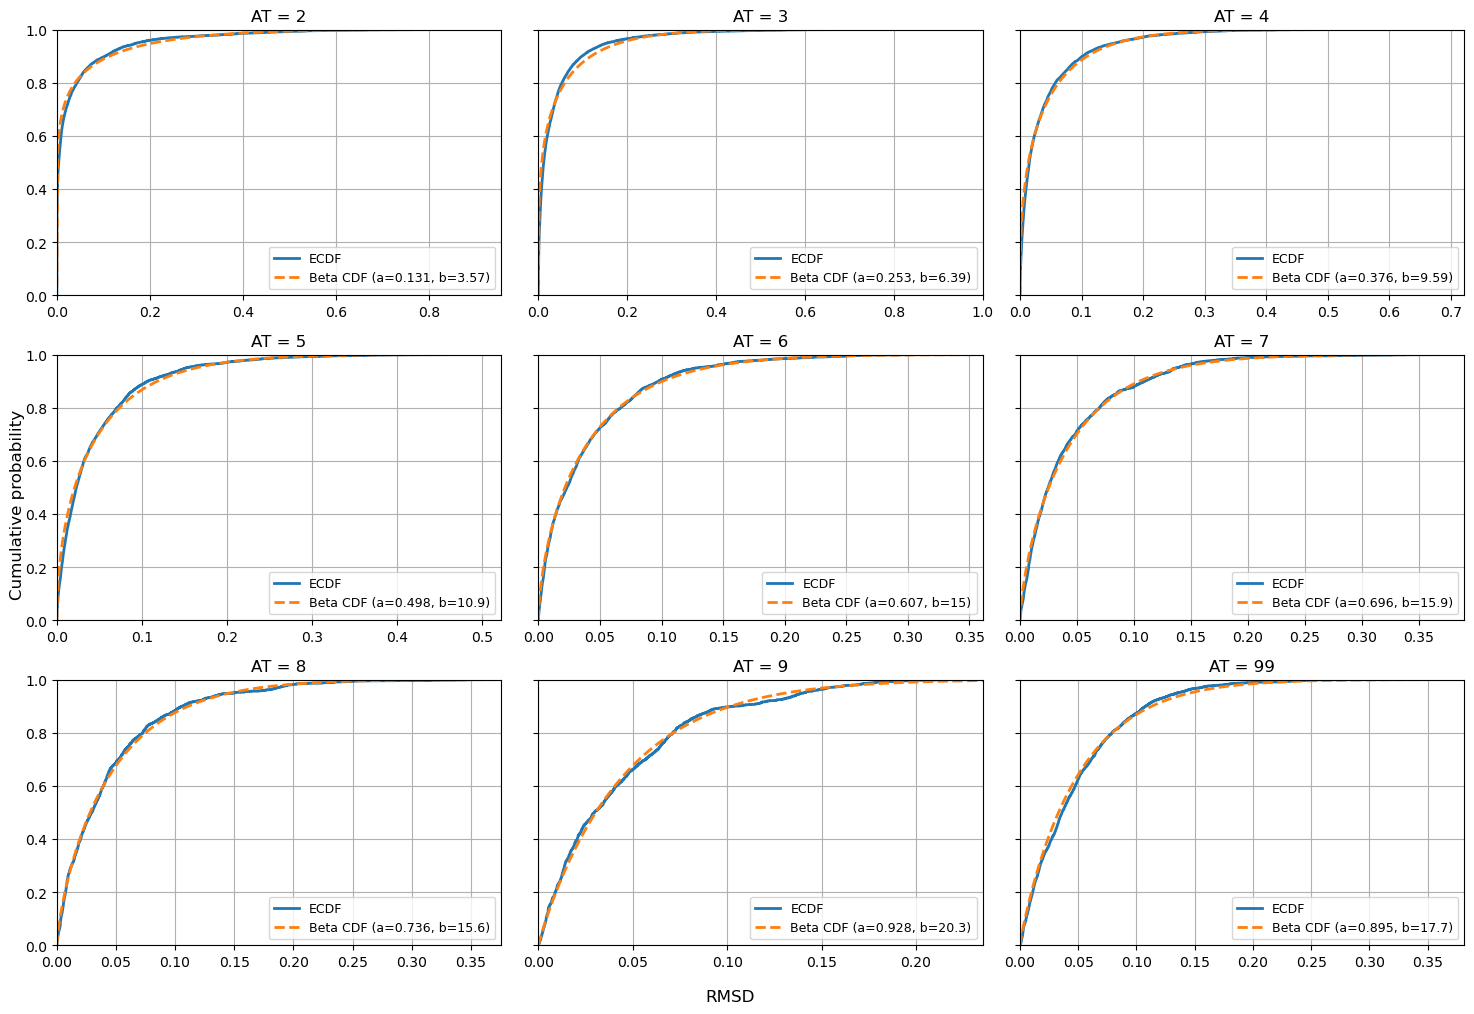

In [316]:
af.plot_ecdf_with_beta_cdf(pooled_by_AT_psc_meso_mod, winner_params_df_psc_meso, keys="all")

**Comparison: Mesoderm vs. cardmeso**

In [317]:
df_fits_meso_cardmeso = spice.fit_distributions_scipy(pooled_by_AT_meso_cardmeso_mod,
                                    models=["beta","johnsonsb","powerlaw"]
)


In [318]:
winner_params_df_meso_cardmeso = spice.winners_by_AIC(df_fits_meso_cardmeso)
winner_params_df_meso_cardmeso

,AT,model,AIC,params
0,2,beta,-783279.874928,"a=0.128639, b=3.50432"
1,3,beta,-330767.463212,"a=0.243959, b=6.05417"
2,4,beta,-175933.606899,"a=0.396367, b=9.84412"
3,5,beta,-108762.274182,"a=0.4516, b=10.5358"
4,6,beta,-65695.029996,"a=0.590177, b=13.1204"
5,7,beta,-43565.426868,"a=0.631964, b=15.0265"
6,8,beta,-28084.002574,"a=0.702664, b=15.8892"
7,9,beta,-18967.136489,"a=0.813202, b=16.5311"
8,99,beta,-47267.510898,"a=0.922272, b=18.2163"


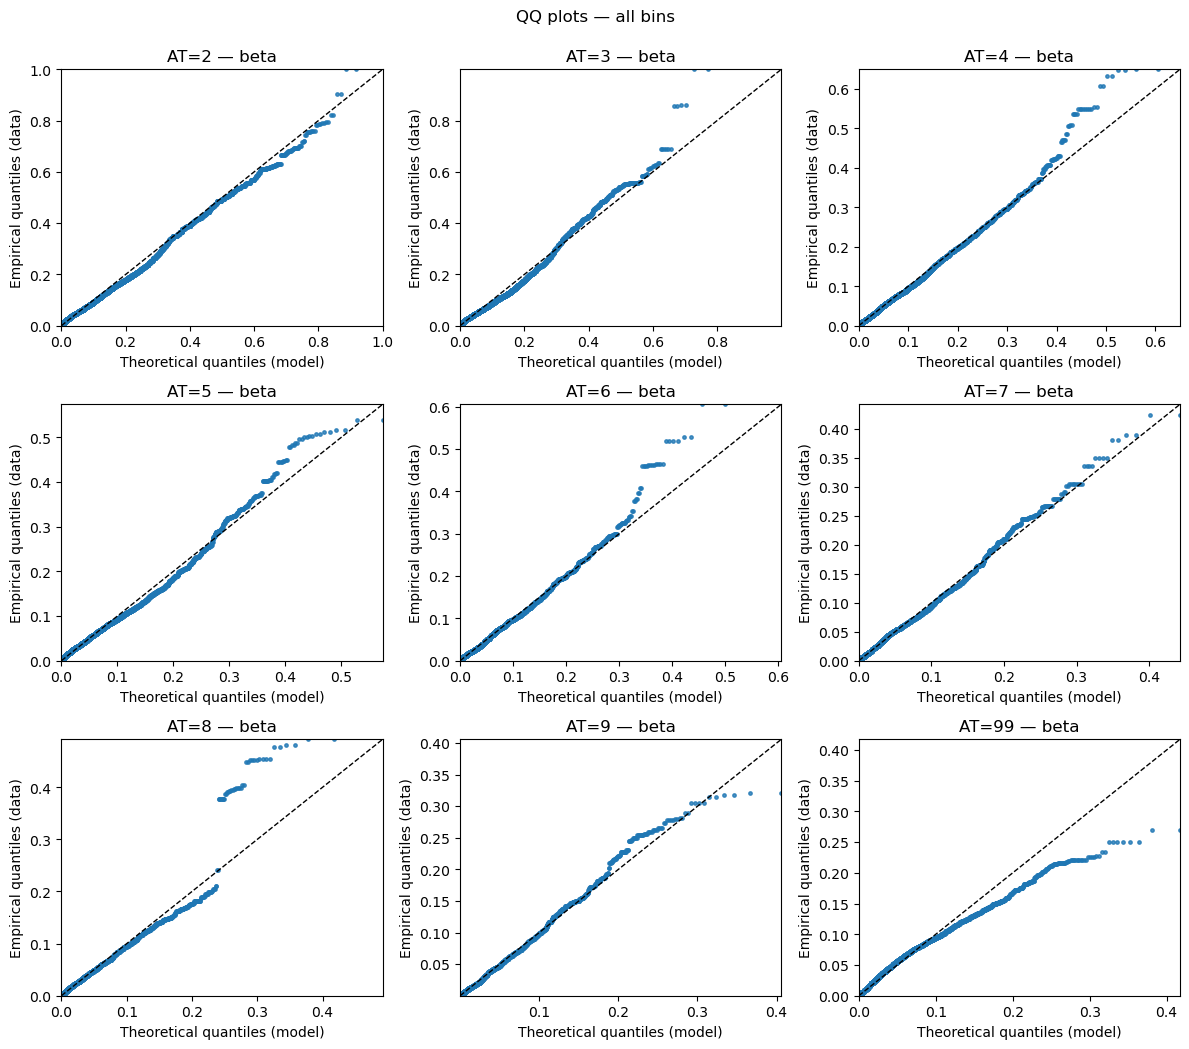

In [319]:
af.plot_all_bins_QQ(pooled_by_AT_meso_cardmeso_mod, df_fits_meso_cardmeso, model_choice="best", winner_by_AIC=winner_params_df_meso_cardmeso ,ncols=3)

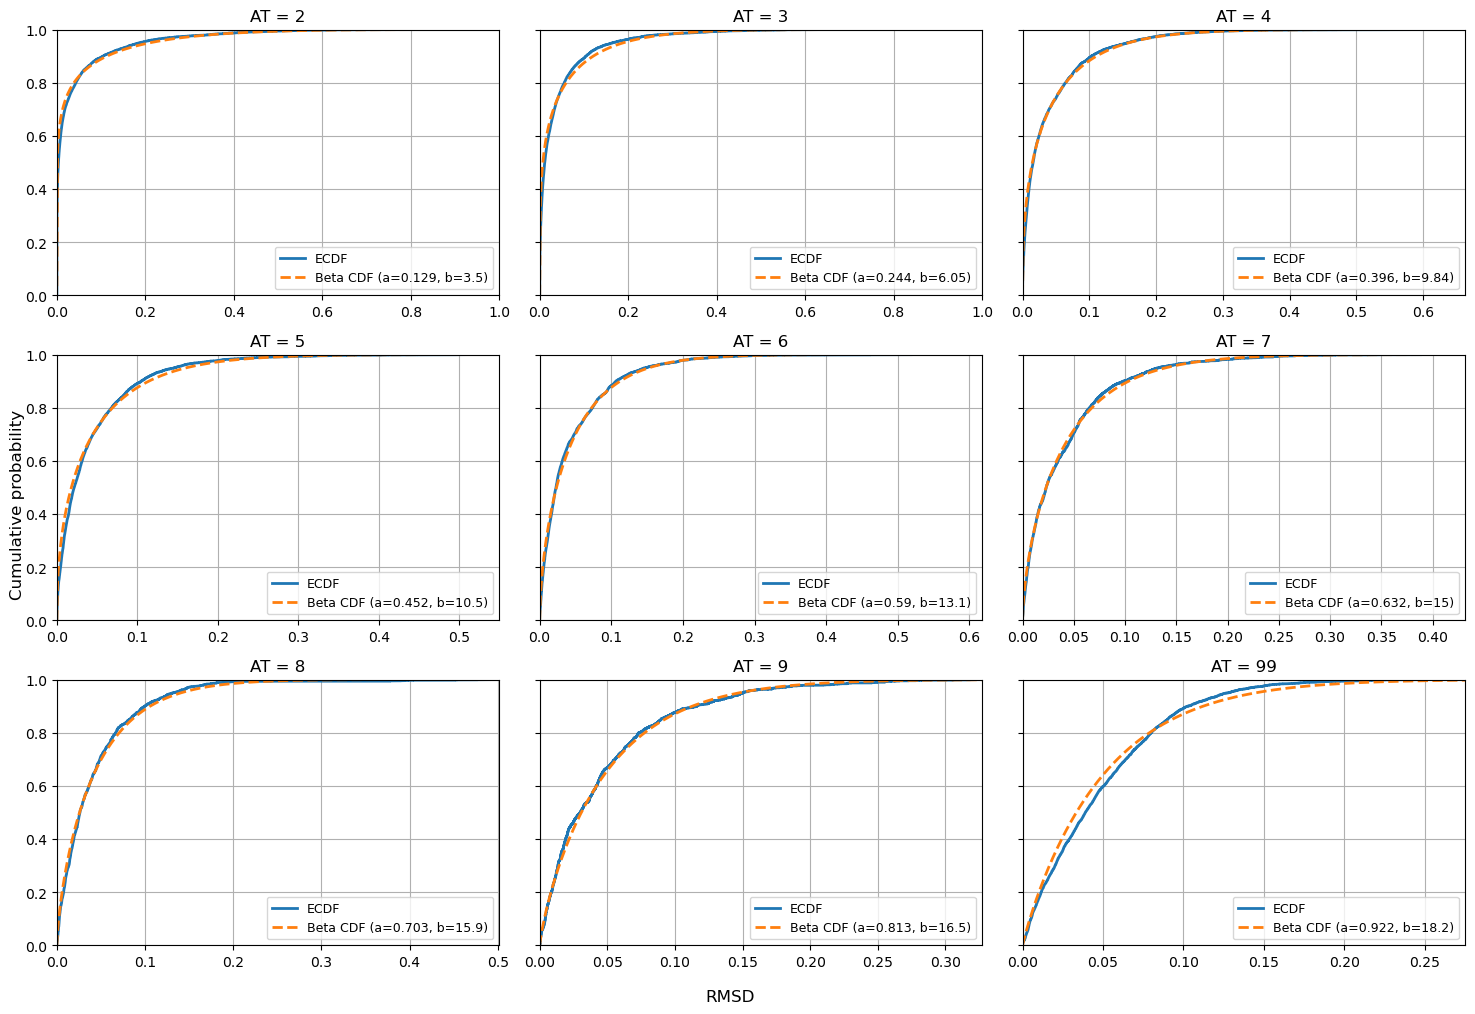

In [320]:
af.plot_ecdf_with_beta_cdf(pooled_by_AT_meso_cardmeso_mod,winner_params_df_meso_cardmeso, keys="all")

**Comparison: Cardmeso vs. CM**

In [321]:
df_fits_cardmeso_cm = spice.fit_distributions_scipy(pooled_by_AT_cardmeso_cm_mod,
                                    models=["beta","johnsonsb","powerlaw"]
)


In [322]:
winner_params_df_cardmeso_cm = spice.winners_by_AIC(df_fits_cardmeso_cm)
winner_params_df_cardmeso_cm

,AT,model,AIC,params
0,2,beta,-824535.088206,"a=0.126376, b=4.32074"
1,3,beta,-375153.600669,"a=0.244522, b=9.61422"
2,4,beta,-204223.321885,"a=0.378872, b=13.704"
3,5,beta,-132506.912272,"a=0.469132, b=16.8605"
4,6,beta,-79107.717781,"a=0.53607, b=18.5178"
5,7,beta,-48732.704538,"a=0.800657, b=29.8663"
6,8,beta,-36564.181897,"a=0.688979, b=25.3784"
7,9,beta,-23010.429413,"a=0.818251, b=24.8937"
8,99,beta,-63068.246191,"a=0.937071, b=28.6221"


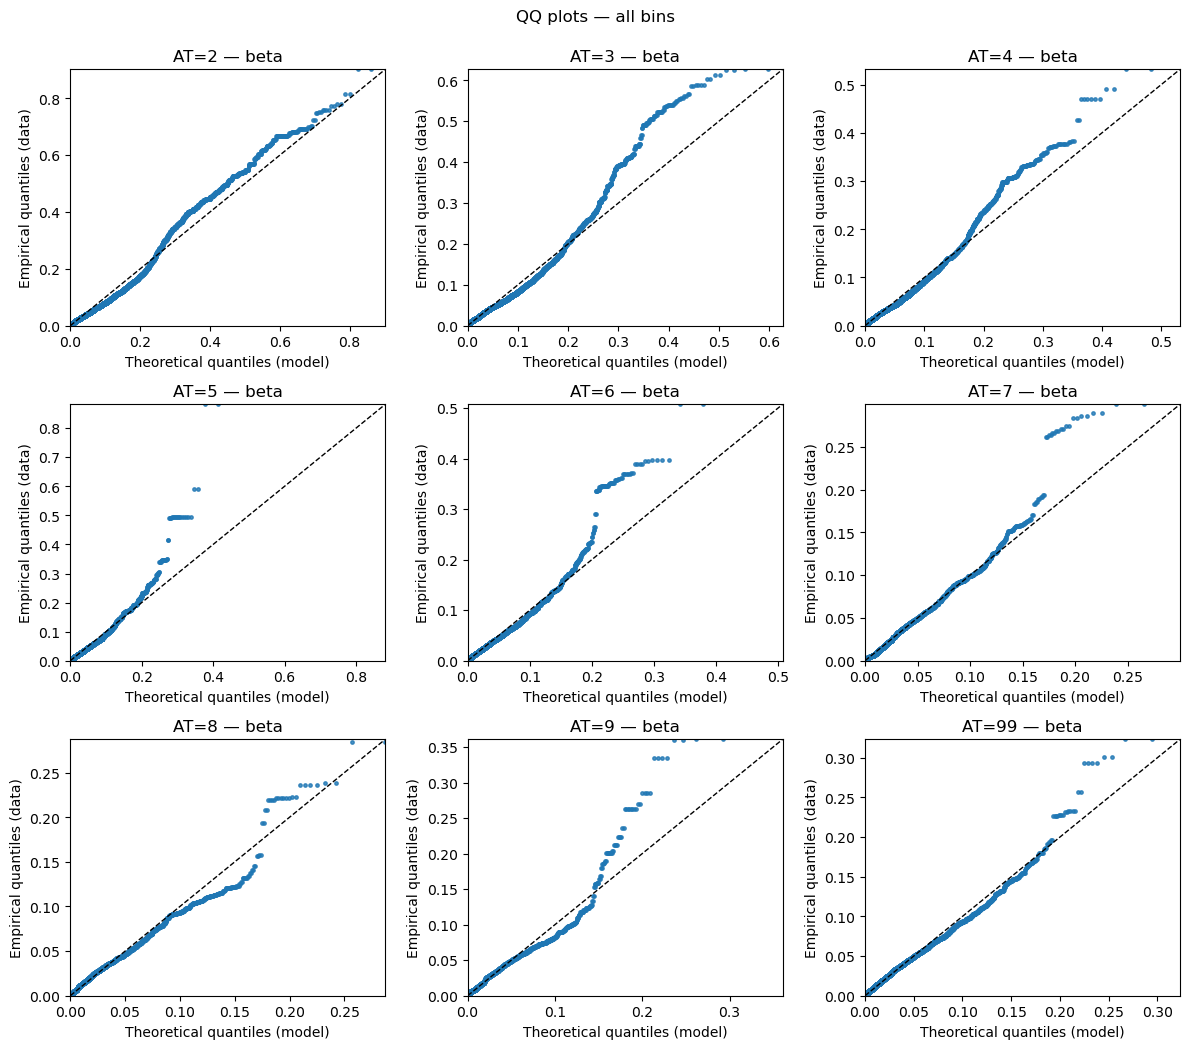

In [323]:
af.plot_all_bins_QQ(pooled_by_AT_cardmeso_cm_mod, df_fits_cardmeso_cm, model_choice="best", winner_by_AIC=winner_params_df_cardmeso_cm ,ncols=3)

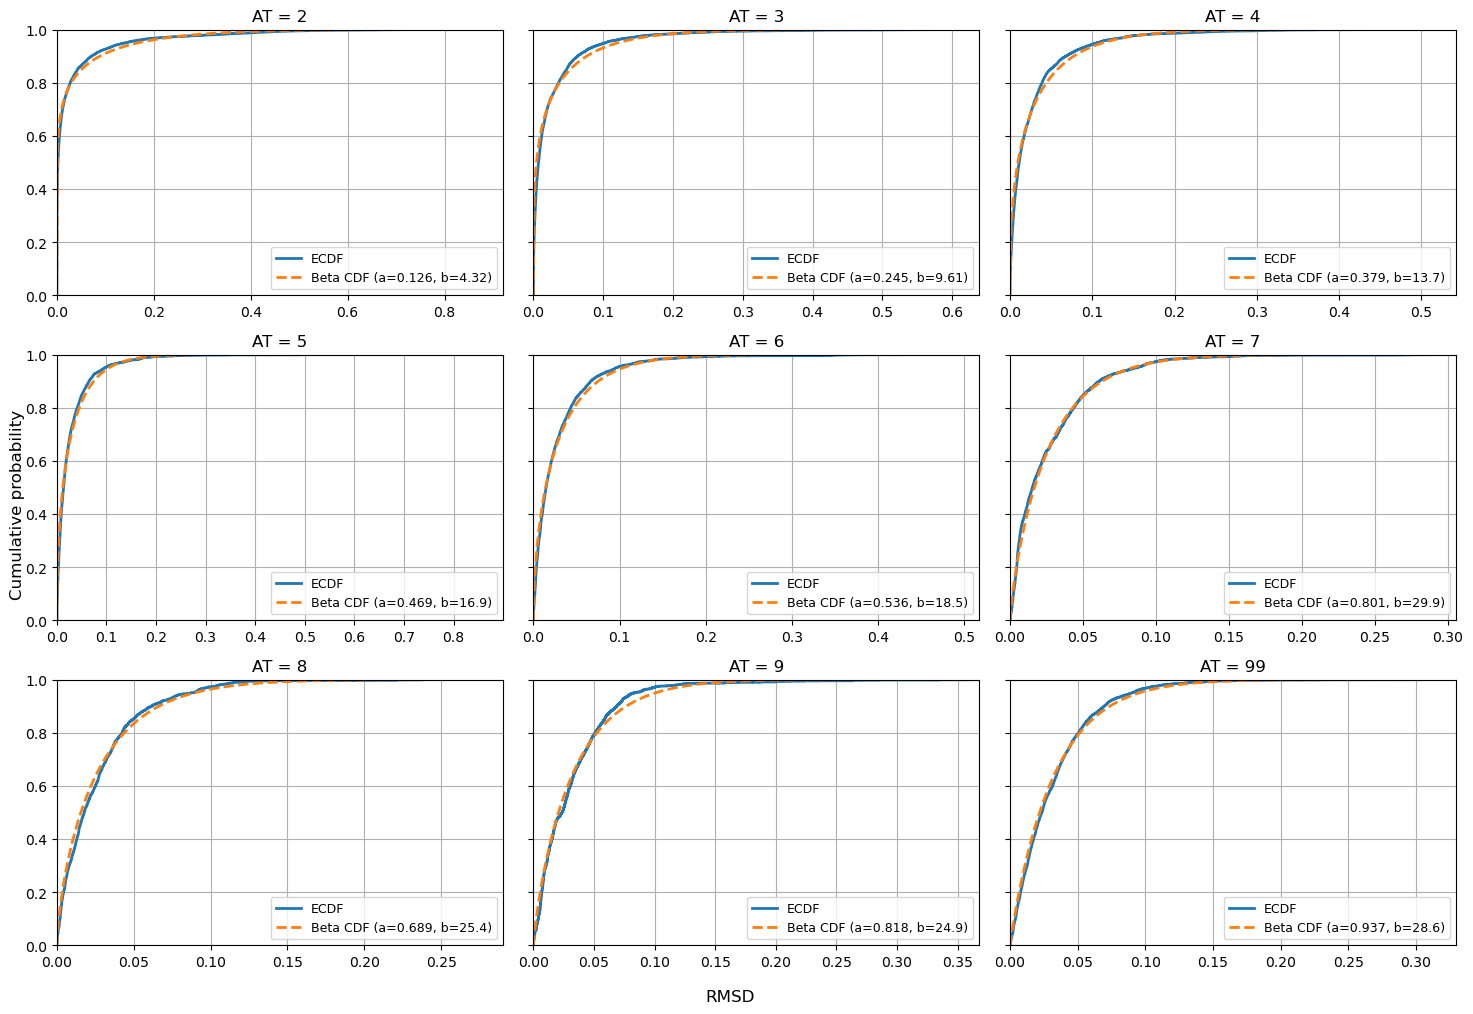

In [324]:
af.plot_ecdf_with_beta_cdf(pooled_by_AT_cardmeso_cm_mod,winner_params_df_cardmeso_cm, keys="all")

# Calculating cumulative probabilities

In [325]:
scored_psc_meso = spice.add_cum_probs(result_table=result_table_psc_meso_mod,
                                         winners_df=winner_params_df_psc_meso,
                                         value_col="RMSD",
                                         out_col="RMSD_q")

In [326]:
scored_meso_cardmeso = spice.add_cum_probs(result_table=result_table_meso_cardmeso_mod,
                                              winners_df=winner_params_df_meso_cardmeso,
                                              value_col="RMSD",
                                              out_col="RMSD_q")

In [327]:
scored_cardmeso_cm = spice.add_cum_probs(result_table=result_table_cardmeso_cm_mod,
                                            winners_df=winner_params_df_cardmeso_cm,
                                            value_col="RMSD",
                                            out_col="RMSD_q")

In [328]:
gene_sample_group_expr, mean_expr_per_group = spice.get_gene_expression_per_sample(metadata=metadata,
                                                          gene_cache=gene_cache_psc_meso,
                                                          sample_groups=sample_groups_psc_meso,
                                                          ver_map=ver_map,
                                                          scaled_outdir=scaled_counts_path,
                                                          group_col="Celltype",
                                                          versioned=True,
                                                          ver_unv_map=ver_unver_map,
                                                          agg="mean",
                                                          include_raw=False)

In [329]:
gene_sample_group_expr_meso_cardmeso, mean_expr_per_group_meso_cardmeso = spice.get_gene_expression_per_sample(metadata=metadata,
                                                          gene_cache=gene_cache_meso_cardmeso,
                                                          sample_groups=sample_groups_meso_cardmeso,
                                                          ver_map=ver_map,
                                                          scaled_outdir=scaled_counts_path,
                                                          group_col="Celltype",
                                                          versioned=True,
                                                          ver_unv_map=ver_unver_map,
                                                          agg="mean",
                                                          include_raw=False)

In [330]:
gene_sample_group_expr_cardmeso_cm, mean_expr_per_group_cardmeso_cm = spice.get_gene_expression_per_sample(metadata=metadata,
                                                          gene_cache=gene_cache_cardmeso_cm,
                                                          sample_groups=sample_groups_cardmeso_cm,
                                                          ver_map=ver_map,
                                                          scaled_outdir=scaled_counts_path,
                                                          group_col="Celltype",
                                                          versioned=True,
                                                          ver_unv_map=ver_unver_map,
                                                          agg="mean",
                                                          include_raw=False)

In [331]:
scored_psc_meso_ext = spice.add_agg_gene_expression(gene_group_agg=mean_expr_per_group,
                                              result_table=scored_psc_meso)
scored_psc_meso_ext

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_PSC,TPM_mean_mesoderm,count_scaled_mean_PSC,count_scaled_mean_mesoderm
0,ENSG00000114026,9,0.175271,0.099435,0.008850,0.192344,9.622215,21.246450,640.215665,1816.814176
1,ENSG00000161981,2,1.000000,0.002884,0.011167,0.684649,29.655969,50.333907,1249.558634,3077.573897
2,ENSG00000175595,2,0.006050,0.037215,0.000536,0.461857,1.546450,1.108864,309.678293,263.596896
3,ENSG00000118046,8,0.918802,0.036568,0.015081,0.341500,26.246746,27.792525,3197.812217,4071.170065
4,ENSG00000187164,4,0.098933,0.303686,0.052697,0.764617,1.919006,1.770082,313.599935,306.076026
...,...,...,...,...,...,...,...,...,...,...
10686,ENSG00000133997,4,0.004817,0.023358,0.000243,0.113557,21.661375,28.620875,1130.843223,1945.609926
10687,ENSG00000154059,2,0.077300,0.000516,0.001201,0.513063,18.027513,16.082989,1837.435549,2080.122695
10688,ENSG00000196781,5,0.424490,0.003506,0.005133,0.261348,52.061270,35.889498,5077.572194,4510.346619
10689,ENSG00000062282,2,0.014400,0.022950,0.000960,0.498314,3.749024,2.419366,325.953355,320.802149


In [332]:
scored_meso_cardmeso_ext = spice.add_agg_gene_expression(gene_group_agg=mean_expr_per_group_meso_cardmeso,
                                              result_table=scored_meso_cardmeso)
scored_meso_cardmeso_ext

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_cardiac mesoderm,TPM_mean_mesoderm,count_scaled_mean_cardiac mesoderm,count_scaled_mean_mesoderm
0,ENSG00000114026,9,0.166949,0.059928,0.009396,0.219498,18.343426,21.326702,1181.392604,1819.280670
1,ENSG00000161981,2,1.000000,0.001143,0.005109,0.622479,35.901675,50.333907,1440.058634,3077.573897
2,ENSG00000206561,2,0.074150,0.099165,0.018955,0.733949,2.663647,0.588939,310.662631,98.563478
3,ENSG00000175595,2,0.006050,0.024744,0.000432,0.453644,1.694374,1.108864,321.682284,263.596896
4,ENSG00000118046,8,0.918802,0.059694,0.015134,0.366464,32.214964,27.792525,3942.335491,4071.170065
...,...,...,...,...,...,...,...,...,...,...
10632,ENSG00000133997,4,0.004817,0.043217,0.000277,0.107065,17.250271,28.620875,891.928773,1945.609926
10633,ENSG00000154059,2,0.077300,0.002509,0.002461,0.567087,21.127503,16.082989,2050.651275,2080.122695
10634,ENSG00000196781,4,0.404067,0.002279,0.005107,0.335955,36.354508,35.499001,3461.792552,4500.929282
10635,ENSG00000062282,2,0.014400,0.008015,0.000720,0.484359,6.191724,2.419366,510.634829,320.802149


In [333]:
scored_cardmeso_cm_ext = spice.add_agg_gene_expression(gene_group_agg=mean_expr_per_group_cardmeso_cm,
                                              result_table=scored_cardmeso_cm)
scored_cardmeso_cm_ext

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_CM,TPM_mean_cardiac mesoderm,count_scaled_mean_CM,count_scaled_mean_cardiac mesoderm
0,ENSG00000114026,9,0.109086,0.048720,0.007738,0.254934,14.430779,18.497625,1021.374387,1186.578927
1,ENSG00000206561,5,0.715410,0.064161,0.086192,0.923361,21.083686,2.687848,2705.078043,313.479293
2,ENSG00000175595,2,0.006050,0.018757,0.000409,0.470673,3.230981,1.694374,671.465085,321.682284
3,ENSG00000118046,8,0.918802,0.070270,0.018865,0.552748,30.267830,32.214964,3538.375134,3942.335491
4,ENSG00000187164,4,0.098933,0.232109,0.041756,0.788223,5.590711,3.026223,842.530529,539.609401
...,...,...,...,...,...,...,...,...,...,...
10745,ENSG00000133997,5,0.113220,0.017244,0.003087,0.275812,21.732353,17.250271,1218.539621,891.928773
10746,ENSG00000154059,2,0.077300,0.000575,0.000910,0.520559,26.028501,21.127503,2752.496346,2050.651275
10747,ENSG00000196781,4,0.405117,0.003174,0.009170,0.492686,24.035930,36.015293,2266.878777,3456.380083
10748,ENSG00000062282,2,0.014400,0.027281,0.001494,0.554087,4.241333,6.191724,383.455653,510.634829


In [334]:
scored_psc_meso_ext = spice.add_gene_symbols(mapping=mapping_new, result_table=scored_psc_meso_ext)
scored_psc_meso_ext

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_PSC,TPM_mean_mesoderm,count_scaled_mean_PSC,count_scaled_mean_mesoderm,gene_symbol
0,ENSG00000114026,9,0.175271,0.099435,0.008850,0.192344,9.622215,21.246450,640.215665,1816.814176,OGG1
14,ENSG00000161981,2,1.000000,0.002884,0.011167,0.684649,29.655969,50.333907,1249.558634,3077.573897,SNRNP25
18,ENSG00000175595,2,0.006050,0.037215,0.000536,0.461857,1.546450,1.108864,309.678293,263.596896,ERCC4
25,ENSG00000118046,8,0.918802,0.036568,0.015081,0.341500,26.246746,27.792525,3197.812217,4071.170065,STK11
37,ENSG00000187164,4,0.098933,0.303686,0.052697,0.764617,1.919006,1.770082,313.599935,306.076026,SHTN1
...,...,...,...,...,...,...,...,...,...,...,...
84399,ENSG00000133997,4,0.004817,0.023358,0.000243,0.113557,21.661375,28.620875,1130.843223,1945.609926,MED6
84404,ENSG00000154059,2,0.077300,0.000516,0.001201,0.513063,18.027513,16.082989,1837.435549,2080.122695,IMPACT
84410,ENSG00000196781,5,0.424490,0.003506,0.005133,0.261348,52.061270,35.889498,5077.572194,4510.346619,TLE1
84417,ENSG00000062282,2,0.014400,0.022950,0.000960,0.498314,3.749024,2.419366,325.953355,320.802149,DGAT2


In [335]:
scored_meso_cardmeso_ext = spice.add_gene_symbols(mapping=mapping_new, result_table=scored_meso_cardmeso_ext)
scored_meso_cardmeso_ext

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_cardiac mesoderm,TPM_mean_mesoderm,count_scaled_mean_cardiac mesoderm,count_scaled_mean_mesoderm,gene_symbol
0,ENSG00000114026,9,0.166949,0.059928,0.009396,0.219498,18.343426,21.326702,1181.392604,1819.280670,OGG1
14,ENSG00000161981,2,1.000000,0.001143,0.005109,0.622479,35.901675,50.333907,1440.058634,3077.573897,SNRNP25
18,ENSG00000206561,2,0.074150,0.099165,0.018955,0.733949,2.663647,0.588939,310.662631,98.563478,COLQ
25,ENSG00000175595,2,0.006050,0.024744,0.000432,0.453644,1.694374,1.108864,321.682284,263.596896,ERCC4
32,ENSG00000118046,8,0.918802,0.059694,0.015134,0.366464,32.214964,27.792525,3942.335491,4071.170065,STK11
...,...,...,...,...,...,...,...,...,...,...,...
84439,ENSG00000133997,4,0.004817,0.043217,0.000277,0.107065,17.250271,28.620875,891.928773,1945.609926,MED6
84444,ENSG00000154059,2,0.077300,0.002509,0.002461,0.567087,21.127503,16.082989,2050.651275,2080.122695,IMPACT
84450,ENSG00000196781,4,0.404067,0.002279,0.005107,0.335955,36.354508,35.499001,3461.792552,4500.929282,TLE1
84457,ENSG00000062282,2,0.014400,0.008015,0.000720,0.484359,6.191724,2.419366,510.634829,320.802149,DGAT2


In [336]:
scored_cardmeso_cm_ext = spice.add_gene_symbols(mapping=mapping_new, result_table=scored_cardmeso_cm_ext)
scored_cardmeso_cm_ext

,GeneID,AT,MPD,JSD,RMSD,RMSD_q,TPM_mean_CM,TPM_mean_cardiac mesoderm,count_scaled_mean_CM,count_scaled_mean_cardiac mesoderm,gene_symbol
0,ENSG00000114026,9,0.109086,0.048720,0.007738,0.254934,14.430779,18.497625,1021.374387,1186.578927,OGG1
14,ENSG00000206561,5,0.715410,0.064161,0.086192,0.923361,21.083686,2.687848,2705.078043,313.479293,COLQ
21,ENSG00000175595,2,0.006050,0.018757,0.000409,0.470673,3.230981,1.694374,671.465085,321.682284,ERCC4
28,ENSG00000118046,8,0.918802,0.070270,0.018865,0.552748,30.267830,32.214964,3538.375134,3942.335491,STK11
40,ENSG00000187164,4,0.098933,0.232109,0.041756,0.788223,5.590711,3.026223,842.530529,539.609401,SHTN1
...,...,...,...,...,...,...,...,...,...,...,...
85278,ENSG00000133997,5,0.113220,0.017244,0.003087,0.275812,21.732353,17.250271,1218.539621,891.928773,MED6
85283,ENSG00000154059,2,0.077300,0.000575,0.000910,0.520559,26.028501,21.127503,2752.496346,2050.651275,IMPACT
85289,ENSG00000196781,4,0.405117,0.003174,0.009170,0.492686,24.035930,36.015293,2266.878777,3456.380083,TLE1
85296,ENSG00000062282,2,0.014400,0.027281,0.001494,0.554087,4.241333,6.191724,383.455653,510.634829,DGAT2


In [337]:
tidy_expr = spice.scaledcounts_to_AT_wide_df(
    scaled_outdir=scaled_counts_path,
    gene_cache=gene_cache_psc_meso,
    sample_groups=sample_groups_psc_meso,
    versioned=True,
    filtered_mapping=mapping_new,
    ver_unv_map=ver_unver_map,
    include_raw=False)

In [338]:
tidy_expr

,gene,Name,txname,count_scaled_118882_S9_PSC,count_scaled_118884_S10_PSC,count_scaled_118886_S11_PSC,count_scaled_118888_S12_mesoderm,count_scaled_118890_S13_mesoderm,count_scaled_118892_S14_mesoderm
0,ENSG00000114026,ENSP00000305584,ENST00000302003,52.547304,74.979636,65.970868,128.983871,180.448985,217.842662
1,ENSG00000114026,ENSP00000342851,ENST00000344629,125.632881,156.380200,115.189915,533.087226,581.955413,1475.579355
2,ENSG00000114026,ENSP00000306561,ENST00000302036,95.347746,10.193241,74.954885,251.948286,213.229470,137.726337
3,ENSG00000114026,ENSP00000345520,ENST00000339511,183.295339,243.446811,169.657678,267.899608,372.023025,403.976656
4,ENSG00000114026,ENSP00000344899,ENST00000352937,64.516901,115.908084,76.139375,63.768706,76.736281,150.164343
...,...,...,...,...,...,...,...,...,...
46678,ENSG00000062282,ENSP00000228027,ENST00000228027,294.395124,350.879409,280.009182,193.033222,47.393574,661.446700
46679,ENSG00000141568,ENST00000473637,ENST00000473637,261.058806,310.912428,159.627372,851.447931,437.103804,144.661811
46680,ENSG00000141568,ENSP00000335677,ENST00000335255,3240.916031,3166.660136,3069.207796,2810.691541,2775.608775,3647.047617
46681,ENSG00000141568,ENSP00000432663,ENST00000526383,0.000000,0.000000,0.000000,84.737922,115.749111,0.000000


In [339]:
tidy_rel_expr = spice.gene_cache_to_rel_expr_df(gene_cache=gene_cache_psc_meso)

In [340]:
tidy_rel_expr_meso_cardmeso = spice.gene_cache_to_rel_expr_df(
    gene_cache=gene_cache_meso_cardmeso
)

In [341]:
tidy_expr_meso_cardmeso = spice.scaledcounts_to_AT_wide_df(
    scaled_outdir=scaled_counts_path,
    gene_cache=gene_cache_meso_cardmeso,
    sample_groups=sample_groups_meso_cardmeso,
    versioned=True,
    filtered_mapping=mapping_new,
    ver_unv_map=ver_unver_map,
    include_raw=False
)

In [342]:
tidy_rel_expr_cardmeso_cm = spice.gene_cache_to_rel_expr_df(
    gene_cache=gene_cache_cardmeso_cm
)

In [343]:
tidy_expr_cardmeso_cm = spice.scaledcounts_to_AT_wide_df(
    scaled_outdir=scaled_counts_path,
    gene_cache=gene_cache_cardmeso_cm,
    sample_groups=sample_groups_cardmeso_cm,
    versioned=True,
    filtered_mapping=mapping_new,
    ver_unv_map=ver_unver_map,
    include_raw=False
)

In [ ]:
# spice.export_tables(outdir="/home/katharina/msc/spice/psc_vs_meso2",
#                   removed_tx_table=removed_transcripts_psc_meso,
#                   result_table=scored_psc_meso_ext,
#                   tidy_expr_table=tidy_expr,
#                   tidy_relexpr_table=tidy_rel_expr)

In [ ]:
# spice.export_tables(outdir="/home/katharina/msc/spice/meso_vs_cardmeso2",
#                   removed_tx_table=removed_transcripts_meso_cardmeso,
#                   result_table=scored_meso_cardmeso_ext,
#                   tidy_expr_table=tidy_expr_meso_cardmeso,
#                   tidy_relexpr_table=tidy_rel_expr_meso_cardmeso)

In [ ]:
# spice.export_tables(outdir="/home/katharina/msc/spice/cardmeso_vs_cm2",
#                   removed_tx_table=removed_transcripts_cardmeso_cm,
#                   result_table=scored_cardmeso_cm_ext,
#                   tidy_expr_table=tidy_expr_cardmeso_cm,
#                   tidy_relexpr_table=tidy_rel_expr_cardmeso_cm)

In [347]:
scored_psc_meso_filt = scored_psc_meso[scored_psc_meso["RMSD"] != 0]
print(len(scored_psc_meso_filt))
scored_meso_cardmeso_filt = scored_meso_cardmeso[scored_meso_cardmeso["RMSD"] != 0]
print(len(scored_meso_cardmeso_filt))
scored_cardmeso_cm_filt = scored_cardmeso_cm[scored_cardmeso_cm["RMSD"] != 0]
print(len(scored_cardmeso_cm_filt))

9904
9825
9911


# Maximum and median cum. probabilities across AT-bins

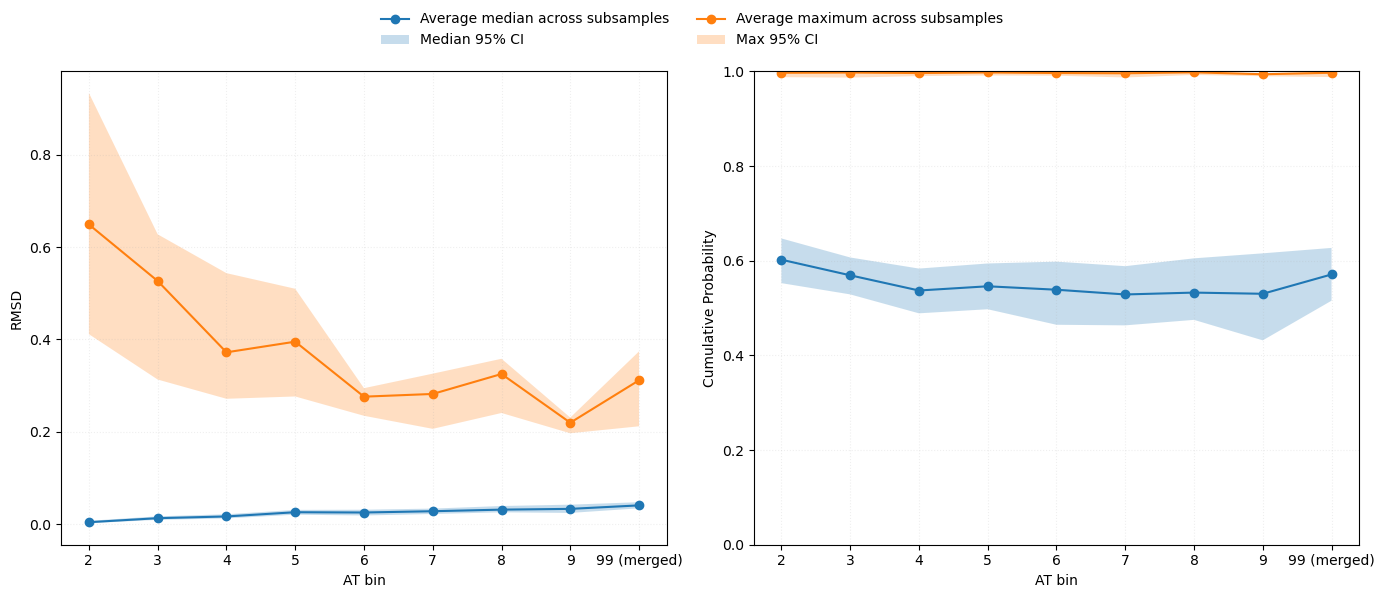

In [348]:
group_col = "AT"
cols = [
    "RMSD",
    "RMSD_q"
]
n_boot = 1000
ci = (2.5, 97.5)
rng = np.random.default_rng(42)
counts = scored_psc_meso[group_col].value_counts().sort_index()
bins = counts.index.to_list()
size_per_bin = counts.min()

# run for both metrics
rmsd_stats = af.subsample_by_bin(scored_psc_meso, group_col, cols[0], bins, size_per_bin, n_boot, rng, ci)
q_stats    = af.subsample_by_bin(scored_psc_meso, group_col, cols[1], bins, size_per_bin, n_boot, rng, ci)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

labels = [str(b) if b != 99 else "99 (merged)" for b in bins]
xpos   = np.arange(len(bins), dtype=float)

for s in (rmsd_stats, q_stats):
    s["xpos"] = xpos
    s["labels"] = labels

def plot_boot(ax, stats, ylabel, ylim=None):
    x = stats["xpos"]

    l1, = ax.plot(x, stats["med_mean"], "-o", label="Average median across subsamples")
    f1 = ax.fill_between(x, stats["med_lo"], stats["med_hi"], alpha=0.25,
                         label="Median 95% CI")

    l2, = ax.plot(x, stats["max_mean"], "-o", label="Average maximum across subsamples")
    f2 = ax.fill_between(x, stats["max_lo"], stats["max_hi"], alpha=0.25,
                         label="Max 95% CI")

    ax.set_xticks(x, stats["labels"])
    ax.set_xlabel("AT bin")
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.2, linestyle=":")

    return [l1, f1, l2, f2]

handles = plot_boot(
    axes[0],
    rmsd_stats,
    "RMSD"
)
plot_boot(
    axes[1],
    q_stats,
    "Cumulative Probability",
    ylim=(0, 1)
)
fig.legend(
    handles=handles,
    loc="upper center",
    ncol=2,
    frameon=False
)
plt.tight_layout(rect=[0, 0, 1, 0.92])


# Correlation of RMSD with average expression values

**Comparison: PSC vs. mesoderm**

In [349]:
scored_psc_meso

,GeneID,AT,MPD,JSD,RMSD,RMSD_q
0,ENSG00000114026,9,0.175271,0.099435,0.008850,0.192344
1,ENSG00000161981,2,1.000000,0.002884,0.011167,0.684649
2,ENSG00000175595,2,0.006050,0.037215,0.000536,0.461857
3,ENSG00000118046,8,0.918802,0.036568,0.015081,0.341500
4,ENSG00000187164,4,0.098933,0.303686,0.052697,0.764617
...,...,...,...,...,...,...
10686,ENSG00000133997,4,0.004817,0.023358,0.000243,0.113557
10687,ENSG00000154059,2,0.077300,0.000516,0.001201,0.513063
10688,ENSG00000196781,5,0.424490,0.003506,0.005133,0.261348
10689,ENSG00000062282,2,0.014400,0.022950,0.000960,0.498314


In [350]:
metrics = [
    "count_scaled_mean_PSC",
    "count_scaled_mean_mesoderm"
]

results_psc_meso = []
bins = [2,3,4,5,6,7,8,9, 99]
for b in bins:
    subset = scored_psc_meso_ext[scored_psc_meso_ext["AT"] == b]

    subset_filt = subset[subset["RMSD"] != 0]
    for col in metrics:
        rho, pval = stats.spearmanr(subset_filt["RMSD"], subset_filt[col], nan_policy="omit")
        results_psc_meso.append({"bin": b, "metric": col, "rho": rho, "pval": pval, "n": len(subset_filt)})

results_psc_meso_df = pd.DataFrame(results_psc_meso)
results_psc_meso_df


,bin,metric,rho,pval,n
0,2,count_scaled_mean_PSC,-0.409373,1.259627e-104,2575
1,2,count_scaled_mean_mesoderm,-0.417889,2.199610e-109,2575
2,3,count_scaled_mean_PSC,-0.393011,3.284476e-79,2119
3,3,count_scaled_mean_mesoderm,-0.407668,1.190250e-85,2119
4,4,count_scaled_mean_PSC,-0.349736,2.865800e-48,1636
5,4,count_scaled_mean_mesoderm,-0.413570,1.316026e-68,1636
6,5,count_scaled_mean_PSC,-0.375147,5.495631e-38,1097
7,5,count_scaled_mean_mesoderm,-0.437029,2.205405e-52,1097
8,6,count_scaled_mean_PSC,-0.372777,1.506740e-25,732
9,6,count_scaled_mean_mesoderm,-0.447937,2.070669e-37,732


In [351]:
#   results_df.to_latex("/home/katharina/msc/figures/corr_counts_RMSD_psc_meso.tex", index=False)

**Comparison: Mesoderm vs. cardmeso**

In [352]:
metrics = [
    "count_scaled_mean_cardiac mesoderm",
    "count_scaled_mean_mesoderm"
]
results_meso_cardmeso = []
for b in bins:
    subset = scored_meso_cardmeso_ext[scored_meso_cardmeso_ext["AT"] == b]

    subset_filt = subset[subset["RMSD"] != 0]
    for col in metrics:
        rho, pval = stats.spearmanr(subset_filt["RMSD"], subset_filt[col], nan_policy="omit")
        results_meso_cardmeso.append({"bin": b, "metric": col, "rho": rho, "pval": pval, "n": len(subset_filt)})

results_meso_cardmeso_df = pd.DataFrame(results_meso_cardmeso)
results_meso_cardmeso_df

,bin,metric,rho,pval,n
0,2,count_scaled_mean_cardiac mesoderm,-0.405604,1.672642e-103,2599
1,2,count_scaled_mean_mesoderm,-0.438898,7.667759e-123,2599
2,3,count_scaled_mean_cardiac mesoderm,-0.358433,7.301284e-68,2206
3,3,count_scaled_mean_mesoderm,-0.396737,4.627655e-84,2206
4,4,count_scaled_mean_cardiac mesoderm,-0.347131,4.986416e-47,1618
5,4,count_scaled_mean_mesoderm,-0.419853,4.214741e-70,1618
6,5,count_scaled_mean_cardiac mesoderm,-0.360552,1.810824e-34,1079
7,5,count_scaled_mean_mesoderm,-0.425273,1.257515e-48,1079
8,6,count_scaled_mean_cardiac mesoderm,-0.344868,1.124195e-21,725
9,6,count_scaled_mean_mesoderm,-0.450948,1.328255e-37,725


In [353]:
#   results_df.to_latex("/home/katharina/msc/figures/corr_counts_RMSD_meso_cardmeso.tex", index=False)

**Comparison: Cardmeso vs. CM**

In [354]:
metrics = [
    "count_scaled_mean_cardiac mesoderm",
    "count_scaled_mean_CM"
]
results_cardmeso_cm = []
for b in bins:
    subset = scored_cardmeso_cm_ext[scored_cardmeso_cm_ext["AT"] == b]

    subset_filt = subset[subset["RMSD"] != 0]
    for col in metrics:
        rho, pval = stats.spearmanr(subset_filt["RMSD"], subset_filt[col], nan_policy="omit")
        results_cardmeso_cm.append({"bin": b, "metric": col, "rho": rho, "pval": pval, "n": len(subset_filt)})

results_cardmeso_cm_df = pd.DataFrame(results_cardmeso_cm)
results_cardmeso_cm_df

,bin,metric,rho,pval,n
0,2,count_scaled_mean_cardiac mesoderm,-0.436435,2.268441e-120,2578
1,2,count_scaled_mean_CM,-0.451271,1.467432e-129,2578
2,3,count_scaled_mean_cardiac mesoderm,-0.411187,1.129700e-90,2204
3,3,count_scaled_mean_CM,-0.423804,8.691596e-97,2204
4,4,count_scaled_mean_cardiac mesoderm,-0.412808,2.804552e-67,1610
5,4,count_scaled_mean_CM,-0.410474,1.810966e-66,1610
6,5,count_scaled_mean_cardiac mesoderm,-0.353138,1.059672e-34,1136
7,5,count_scaled_mean_CM,-0.372271,1.165435e-38,1136
8,6,count_scaled_mean_cardiac mesoderm,-0.385998,8.056953e-27,715
9,6,count_scaled_mean_CM,-0.394864,4.283257e-28,715


In [355]:
#   results_df.to_latex("/home/katharina/msc/figures/corr_counts_RMSD_cardmeso_CM.tex", index=False)

# Correlation of gene-level summed normalized counts to DESeq2 counts

In [356]:
norm_counts_deseq = pd.read_csv("/home/katharina/msc/deseq2/normalized_counts.tsv", sep="\t")
norm_counts_deseq.head()

,GeneID,118882_S9,118884_S10,118886_S11,118888_S12,118890_S13,118892_S14,118750_S3,118752_S4,118754_S5,125499_S11,125501_S12,125503_S13,GeneSymbol
0,ENSG00000000003,6505.432755,7034.103969,6560.571667,6103.413967,5160.413537,6131.215896,5687.097974,5935.939705,6114.079227,6176.205059,6570.829183,6894.838252,TSPAN6
1,ENSG00000000005,16.175802,18.672197,17.061225,52.989945,44.301504,277.282875,53.725340,33.875722,36.994017,2.555425,2.636995,5.355966,TNMD
2,ENSG00000000419,3031.919811,3023.453953,3091.248168,1801.549477,2221.453510,3343.879270,1643.116514,1767.710685,1656.856114,1614.484371,1644.051246,1727.740462,DPM1
3,ENSG00000000457,315.406653,406.842247,363.551923,475.958237,598.229547,488.802627,763.273574,674.514808,820.694682,753.500482,823.282768,826.150958,SCYL3
4,ENSG00000000460,1223.166404,1213.087449,1475.363637,1359.964266,1461.725986,1909.207317,1603.759884,1559.457913,1497.319024,819.170054,996.181471,1117.498730,FIRRM


In [357]:
sample_cols_psc_meso = [c for c in tidy_expr.columns if c.startswith("count_scaled_")]
sample_cols_meso_cardmeso = [c for c in tidy_expr_meso_cardmeso.columns if c.startswith("count_scaled_")]
sample_cols_cardmeso_cm = [c for c in tidy_expr_cardmeso_cm.columns if c.startswith("count_scaled_")]

In [358]:
# sum transcript level normalized counts to obtain one value per gene and sample
gene_agg_sc_psc_meso = (
    tidy_expr.groupby("gene")[sample_cols_psc_meso]
    .sum()
    .reset_index()
)
gene_agg_sc_psc_meso = gene_agg_sc_psc_meso.rename(columns={"gene": "GeneID"})

In [359]:
# trim columns to only display sample
new_cols_psc_meso = {}
for c in sample_cols_psc_meso:
    sample = c.replace("count_scaled_", "").split("_")[0:2]
    sample = "_".join(sample)
    new_cols_psc_meso[c] = sample

gene_agg_sc_psc_meso = gene_agg_sc_psc_meso.rename(columns=new_cols_psc_meso)

In [360]:
gene_agg_sc_psc_meso

,GeneID,118882_S9,118884_S10,118886_S11,118888_S12,118890_S13,118892_S14
0,ENSG00000000003,5762.228344,6123.953320,5575.017395,7146.950310,5729.629102,6947.965495
1,ENSG00000000419,2673.018068,2623.090069,2628.252318,2105.572402,2445.220860,3782.273681
2,ENSG00000000457,282.727163,336.518744,290.479969,500.927887,602.698932,318.539681
3,ENSG00000000460,1024.837826,1019.030978,1036.205169,1413.378245,1598.390704,2503.510907
4,ENSG00000001036,5111.742645,5210.114974,5098.244309,4439.855634,4180.246973,5187.708613
...,...,...,...,...,...,...,...
10686,ENSG00000292358,1840.769754,1850.738470,1654.251657,2233.289789,1963.142256,4899.400121
10687,ENSG00000292366,1019.178109,1072.524332,1147.097376,1709.846053,2331.679642,981.394499
10688,ENSG00000293268,3374.886831,3270.982520,3610.051383,466.889869,799.946013,5858.756920
10689,ENSG00000293615,249.525920,258.651068,246.267000,280.432901,276.854136,235.671538


In [361]:
# merge with deseq counts
merged_psc_meso = pd.merge(
    gene_agg_sc_psc_meso,
    norm_counts_deseq,
    on="GeneID",
    suffixes=("_txsum", "_deseq")
)
merged_psc_meso

,GeneID,118882_S9_txsum,118884_S10_txsum,118886_S11_txsum,118888_S12_txsum,118890_S13_txsum,118892_S14_txsum,118882_S9_deseq,118884_S10_deseq,118886_S11_deseq,118888_S12_deseq,118890_S13_deseq,118892_S14_deseq,118750_S3,118752_S4,118754_S5,125499_S11,125501_S12,125503_S13,GeneSymbol
0,ENSG00000000003,5762.228344,6123.953320,5575.017395,7146.950310,5729.629102,6947.965495,6505.432755,7034.103969,6560.571667,6103.413967,5160.413537,6131.215896,5687.097974,5935.939705,6114.079227,6176.205059,6570.829183,6894.838252,TSPAN6
1,ENSG00000000419,2673.018068,2623.090069,2628.252318,2105.572402,2445.220860,3782.273681,3031.919811,3023.453953,3091.248168,1801.549477,2221.453510,3343.879270,1643.116514,1767.710685,1656.856114,1614.484371,1644.051246,1727.740462,DPM1
2,ENSG00000000457,282.727163,336.518744,290.479969,500.927887,602.698932,318.539681,315.406653,406.842247,363.551923,475.958237,598.229547,488.802627,763.273574,674.514808,820.694682,753.500482,823.282768,826.150958,SCYL3
3,ENSG00000000460,1024.837826,1019.030978,1036.205169,1413.378245,1598.390704,2503.510907,1223.166404,1213.087449,1475.363637,1359.964266,1461.725986,1909.207317,1603.759884,1559.457913,1497.319024,819.170054,996.181471,1117.498730,FIRRM
4,ENSG00000001036,5111.742645,5210.114974,5098.244309,4439.855634,4180.246973,5187.708613,5785.199179,5952.752706,5992.673843,3767.647555,3746.265008,4536.566105,4060.607783,4102.405504,3812.999178,2262.398703,2364.839828,2397.225986,FUCA2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10686,ENSG00000292358,1840.769754,1850.738470,1654.251657,2233.289789,1963.142256,4899.400121,2071.002463,2077.384848,1908.292390,1953.975949,1783.588285,4358.891208,2462.529643,2430.842280,2558.237875,2155.367501,2277.381876,1984.410609,GTPBP6
10687,ENSG00000292366,1019.178109,1072.524332,1147.097376,1709.846053,2331.679642,981.394499,1151.144555,1210.917223,1335.806191,1496.045184,2109.070437,856.043615,1293.136893,1464.363181,1407.372343,2420.378871,2186.891223,2198.928661,VAMP7
10688,ENSG00000293268,3374.886831,3270.982520,3610.051383,466.889869,799.946013,5858.756920,3950.609753,3870.687154,4372.744148,366.012523,671.621438,5483.524335,5254.824091,3851.562985,3186.995339,3532.068479,3007.735025,3321.265381,.
10689,ENSG00000293615,249.525920,258.651068,246.267000,280.432901,276.854136,235.671538,278.297233,295.506566,284.423263,242.367974,249.804734,210.567297,305.898372,293.292959,289.994135,297.580632,312.994992,289.659638,.


In [362]:
# calculate pearson correlation coefficient
samples_psc_meso = [c for c in gene_agg_sc_psc_meso.columns if c != "GeneID"]

for s in samples_psc_meso:
    corr = merged_psc_meso[f"{s}_txsum"].corr(merged_psc_meso[f"{s}_deseq"])
    print(s, corr)

118882_S9 0.9995340384924775
118884_S10 0.999585455484211
118886_S11 0.9995393704490091
118888_S12 0.9997490580411456
118890_S13 0.9996099421414252
118892_S14 0.993265815610113


In [363]:
gene_agg_sc_meso_cardmeso = (
    tidy_expr_meso_cardmeso.groupby("gene")[sample_cols_meso_cardmeso]
    .sum()
    .reset_index()
)
gene_agg_sc_meso_cardmeso = gene_agg_sc_meso_cardmeso.rename(columns={"gene": "GeneID"})

In [364]:
new_cols_meso_cardmeso = {}
for c in sample_cols_meso_cardmeso:
    sample = c.replace("count_scaled_", "").split("_")[0:2]
    sample = "_".join(sample)
    new_cols_meso_cardmeso[c] = sample

gene_agg_sc_meso_cardmeso = gene_agg_sc_meso_cardmeso.rename(columns=new_cols_meso_cardmeso)

In [365]:
merged_meso_cardmeso = pd.merge(
    gene_agg_sc_meso_cardmeso,
    norm_counts_deseq,
    on="GeneID",
    suffixes=("_txsum", "_deseq")
)
merged_meso_cardmeso

,GeneID,118750_S3_txsum,118752_S4_txsum,118754_S5_txsum,118888_S12_txsum,118890_S13_txsum,118892_S14_txsum,118882_S9,118884_S10,118886_S11,118888_S12_deseq,118890_S13_deseq,118892_S14_deseq,118750_S3_deseq,118752_S4_deseq,118754_S5_deseq,125499_S11,125501_S12,125503_S13,GeneSymbol
0,ENSG00000000419,1373.527804,1539.871289,1468.537876,2105.572402,2445.220860,3782.273681,3031.919811,3023.453953,3091.248168,1801.549477,2221.453510,3343.879270,1643.116514,1767.710685,1656.856114,1614.484371,1644.051246,1727.740462,DPM1
1,ENSG00000000457,654.772548,642.984417,742.535282,500.927887,602.698932,318.539681,315.406653,406.842247,363.551923,475.958237,598.229547,488.802627,763.273574,674.514808,820.694682,753.500482,823.282768,826.150958,SCYL3
2,ENSG00000000460,1445.117489,1416.472509,1387.780480,1404.214959,1593.740571,2494.763179,1223.166404,1213.087449,1475.363637,1359.964266,1461.725986,1909.207317,1603.759884,1559.457913,1497.319024,819.170054,996.181471,1117.498730,FIRRM
3,ENSG00000001036,3353.712209,3542.634374,3363.277059,4439.855634,4180.246973,5187.708613,5785.199179,5952.752706,5992.673843,3767.647555,3746.265008,4536.566105,4060.607783,4102.405504,3812.999178,2262.398703,2364.839828,2397.225986,FUCA2
4,ENSG00000001084,1826.082635,2018.849674,2054.438338,2085.300324,1919.476789,2235.274736,3380.068391,3153.517831,3207.872861,1778.621714,1708.355351,2007.216368,2262.864314,2330.900606,2324.668520,2282.054716,2072.809685,2143.239240,GCLC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10632,ENSG00000292358,2159.360251,2157.197191,2329.004772,2233.289789,1963.142256,4899.400121,2071.002463,2077.384848,1908.292390,1953.975949,1783.588285,4358.891208,2462.529643,2430.842280,2558.237875,2155.367501,2277.381876,1984.410609,GTPBP6
10633,ENSG00000292366,1073.116641,1258.213298,1264.482541,1709.846053,2331.679642,981.394499,1151.144555,1210.917223,1335.806191,1496.045184,2109.070437,856.043615,1293.136893,1464.363181,1407.372343,2420.378871,2186.891223,2198.928661,VAMP7
10634,ENSG00000293268,4251.341439,3281.858541,2803.860806,466.889869,799.946013,5858.756920,3950.609753,3870.687154,4372.744148,366.012523,671.621438,5483.524335,5254.824091,3851.562985,3186.995339,3532.068479,3007.735025,3321.265381,.
10635,ENSG00000293615,258.503169,259.949501,257.611018,280.432901,276.854136,235.671538,278.297233,295.506566,284.423263,242.367974,249.804734,210.567297,305.898372,293.292959,289.994135,297.580632,312.994992,289.659638,.


In [366]:
samples_meso_cardmeso = [c for c in gene_agg_sc_meso_cardmeso.columns if c != "GeneID"]

for s in samples_meso_cardmeso:
    corr = merged_meso_cardmeso[f"{s}_txsum"].corr(merged_meso_cardmeso[f"{s}_deseq"])
    print(s, corr)

118750_S3 0.9995073892368105
118752_S4 0.999196727506209
118754_S5 0.9996413542034455
118888_S12 0.9997482347608527
118890_S13 0.9996120578764379
118892_S14 0.9933880725669962


In [367]:
gene_agg_sc_cardmeso_cm = (
    tidy_expr_cardmeso_cm.groupby("gene")[sample_cols_cardmeso_cm]
    .sum()
    .reset_index()
)

gene_agg_sc_cardmeso_cm = gene_agg_sc_cardmeso_cm.rename(columns={"gene": "GeneID"})

In [368]:
new_cols_cardmeso_cm = {}
for c in sample_cols_cardmeso_cm:
    sample = c.replace("count_scaled_", "").split("_")[0:2]
    sample = "_".join(sample)
    new_cols_cardmeso_cm[c] = sample

gene_agg_sc_cardmeso_cm = gene_agg_sc_cardmeso_cm.rename(columns=new_cols_cardmeso_cm)

In [369]:
merged_cardmeso_cm = pd.merge(
    gene_agg_sc_cardmeso_cm,
    norm_counts_deseq,
    on="GeneID",
    suffixes=("_txsum", "_deseq")
)
merged_cardmeso_cm

,GeneID,118750_S3_txsum,118752_S4_txsum,118754_S5_txsum,125499_S11_txsum,125501_S12_txsum,125503_S13_txsum,118882_S9,118884_S10,118886_S11,118888_S12,118890_S13,118892_S14,118750_S3_deseq,118752_S4_deseq,118754_S5_deseq,125499_S11_deseq,125501_S12_deseq,125503_S13_deseq,GeneSymbol
0,ENSG00000000419,1373.527804,1539.871289,1468.537876,1849.398192,1764.171473,1786.263413,3031.919811,3023.453953,3091.248168,1801.549477,2221.453510,3343.879270,1643.116514,1767.710685,1656.856114,1614.484371,1644.051246,1727.740462,DPM1
1,ENSG00000000457,654.772548,642.984417,731.737396,910.445461,901.781061,924.477899,315.406653,406.842247,363.551923,475.958237,598.229547,488.802627,763.273574,674.514808,820.694682,753.500482,823.282768,826.150958,SCYL3
2,ENSG00000000460,1445.117489,1416.472509,1387.780480,965.753451,1075.134426,1127.962907,1223.166404,1213.087449,1475.363637,1359.964266,1461.725986,1909.207317,1603.759884,1559.457913,1497.319024,819.170054,996.181471,1117.498730,FIRRM
3,ENSG00000001036,3353.712209,3542.634374,3363.277059,2568.860093,2534.062046,2459.555101,5785.199179,5952.752706,5992.673843,3767.647555,3746.265008,4536.566105,4060.607783,4102.405504,3812.999178,2262.398703,2364.839828,2397.225986,FUCA2
4,ENSG00000001084,1826.082635,2018.849674,2054.438338,2613.248788,2224.440337,2165.001362,3380.068391,3153.517831,3207.872861,1778.621714,1708.355351,2007.216368,2262.864314,2330.900606,2324.668520,2282.054716,2072.809685,2143.239240,GCLC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10745,ENSG00000292358,2159.360251,2157.197191,2329.004772,2363.401146,2341.985337,1985.251618,2071.002463,2077.384848,1908.292390,1953.975949,1783.588285,4358.891208,2462.529643,2430.842280,2558.237875,2155.367501,2277.381876,1984.410609,GTPBP6
10746,ENSG00000292366,1073.116641,1258.213298,1264.482541,2711.618081,2313.589019,2256.414276,1151.144555,1210.917223,1335.806191,1496.045184,2109.070437,856.043615,1293.136893,1464.363181,1407.372343,2420.378871,2186.891223,2198.928661,VAMP7
10747,ENSG00000293268,4251.341439,3281.858541,2803.860806,4075.831931,3317.857791,3460.340743,3950.609753,3870.687154,4372.744148,366.012523,671.621438,5483.524335,5254.824091,3851.562985,3186.995339,3532.068479,3007.735025,3321.265381,.
10748,ENSG00000293615,258.503169,259.949501,257.611018,330.363423,332.370650,293.706308,278.297233,295.506566,284.423263,242.367974,249.804734,210.567297,305.898372,293.292959,289.994135,297.580632,312.994992,289.659638,.


In [370]:
samples_cardmeso_cm = [c for c in gene_agg_sc_cardmeso_cm.columns if c != "GeneID"]

for s in samples_cardmeso_cm:
    corr = merged_cardmeso_cm[f"{s}_txsum"].corr(merged_cardmeso_cm[f"{s}_deseq"])
    print(s, corr)

118750_S3 0.9995100393189982
118752_S4 0.999199100146498
118754_S5 0.9996405315025226
125499_S11 0.9985536434534019
125501_S12 0.9991034188387735
125503_S13 0.9993350775443522
